# DESeq2 with new reference genome
but with pre-filtering! 
# Phase 2 vs. Phase 2

focusing on pairwise comparisons of oysters that experienced both phase 1 and phase 2

## 0. load libraries

In [2]:
library(tidyverse)
library(DESeq2)
library(EnhancedVolcano) # for volcano plots
library(vegan) # for permanova
library(pheatmap)
library(RColorBrewer)
library(limma) # for removing batch effects

## 1. read counts matrix and meta data

### counts matrix
the counts matrix was generated in [processing_seqs.ipynb](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/processing/nov25_refSeq/processing_seqs.ipynb) with the new reference genome ([NCBI GCF_053477285.1](https://www.ncbi.nlm.nih.gov/datasets/genome/GCF_053477285.1/)), indexed and aligned with `hisat2`, and counts matrix generated with `featureCounts` (all with the same flags/settings that were used with the old genome)

In [3]:
# counts matrix
counts <- read.csv('/work/pi_sarah_gignouxwolfsohn_uml_edu/julia_mcdonough_student_uml_edu/ce24_rnaseq/newRef_featureCounts/featureCounts_matrix.csv')

# set gene_ID as row name
rownames(counts) <- counts$Gene_ID

# remove gene id and length
counts.df <- counts %>%
select(-Gene_ID, -Length)

head(counts.df)

,B1_B1_O01,B1_Nu_O03,B1_W5_O50,B2_B5_O51,B2_C4_O40,B2_Nu_O12,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,⋯,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_Nu_G41,W6_Nu_G45,W6_W3_G36,W6_W4_G48
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
LOC144621260,2626,2649,2072,2158,2074,3974,1207,1181,3017,1438,⋯,1252,2294,2215,1653,1720,1566,2734,2374,2683,2391
LOC144621269,55,580,1632,2484,1011,20011,2110,886,9991,1446,⋯,6,620,44,101,9226,16,2,4034,383,9803
LOC111120925,70,4,23,469,11,18,15,7,0,1,⋯,3,452,82,28,5,1,0,11,11,9
Trnae-cuc,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Trnae-cuc-2,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Trnae-cuc-3,0,0,0,0,0,1,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [4]:
# number of genes with 0 counts for all samples
sum(rowSums(counts.df) == 0) # 4884 genes

# pre-filter those rows
counts.filtered <- counts.df[!rowSums(counts.df) == 0,]

# double check this worked
dim(counts.df) # 33903 total genes
dim(counts.filtered) # 29019 genes with at least 1 read

[1] 4884

[1] 33903   120

[1] 29019   120

### meta data
the meta data csv was already generated in [deseq_p1.v.p1](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase1_v_phase1/deseq_p1.v.p1.ipynb), so just reading in here

In [5]:
meta <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/sample_metaData.csv') %>%
filter(!grepl("Nu", Sample)) # filter out phase 1 samples - only want phase 2

# setting samples as rownames and deleting col from df
rownames(meta) <- meta$Sample
meta <- meta[, !colnames(meta) %in% "Sample"]

head(meta)
dim(meta)

,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>
B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1
B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5
B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5
B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4
B3_B4_O41,both,warm,hypoxic,3,both,warm,hypoxic,4
B3_C3_O30,both,warm,hypoxic,3,control,ambient,normoxic,3


[1] 96  8

creating new column for 'complete' treatment - so I can easily compare phase 1 to phase 2

In [6]:
meta$complete_trtmt <- paste(meta$Phase1_treatment, meta$Phase2_treatment)

# check
head(meta,2)
tail(meta,2)

,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>
B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both both
B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both warm


,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>
W6_W3_G36,warm,warm,normoxic,6,warm,warm,normoxic,3,warm warm
W6_W4_G48,warm,warm,normoxic,6,warm,warm,normoxic,4,warm warm


In [7]:
# setting the same order for counts matrix and meta data
counts.filtered <- counts.filtered[,rownames(meta)]
all(rownames(meta) == colnames(counts.filtered))

[1] TRUE

## 2a. DESeq2
analyzing differential gene expression with [`DESeq2`](https://bioconductor.org/packages/release/bioc/vignettes/DESeq2/inst/doc/DESeq2.html)

#### contrasts
setting up contrasts (telling DESeq what is the control treatment)

In [8]:
# tempature treatments
meta$Phase1_temp <- factor(meta$Phase1_temp,
                                   levels = c('ambient', 'warm'))

meta$Phase2_temp <- factor(meta$Phase2_temp,
                                   levels = c('ambient', 'warm'))

In [9]:
# DO treatments
meta$Phase1_DO <- factor(meta$Phase1_DO,
                                   levels = c('normoxic', 'hypoxic'))

meta$Phase2_DO <- factor(meta$Phase2_DO,
                                   levels = c('normoxic', 'hypoxic'))

### complete treatments
starting simple with looking at phase 1 treatments (not splitting into temperature/DO, just looking at combination of treatments)

In [10]:
# creating DESeq2 object
dds <- DESeqDataSetFromMatrix(countData = counts.filtered,
                              colData = meta,
                              design = ~ complete_trtmt)
dds

# running DESeq
dds <- DESeq(dds)

# list coefficients
resultsNames(dds)

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]



class: DESeqDataSet 
dim: 29019 96 
metadata(1): version
assays(1): counts
rownames(29019): LOC144621260 LOC144621269 ... LOC144621306
  LOC144621888
rowData names(0):
colnames(96): B1_B1_O01 B1_W5_O50 ... W6_W3_G36 W6_W4_G48
colData names(9): Phase1_treatment Phase1_temp ... Phase2_TankRep
  complete_trtmt

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

final dispersion estimates

fitting model and testing



[1] "Intercept"                                  
 [2] "complete_trtmt_both.control_vs_both.both"   
 [3] "complete_trtmt_both.hypoxic_vs_both.both"   
 [4] "complete_trtmt_both.warm_vs_both.both"      
 [5] "complete_trtmt_control.both_vs_both.both"   
 [6] "complete_trtmt_control.control_vs_both.both"
 [7] "complete_trtmt_control.hypoxic_vs_both.both"
 [8] "complete_trtmt_control.warm_vs_both.both"   
 [9] "complete_trtmt_hypoxic.both_vs_both.both"   
[10] "complete_trtmt_hypoxic.control_vs_both.both"
[11] "complete_trtmt_hypoxic.hypoxic_vs_both.both"
[12] "complete_trtmt_hypoxic.warm_vs_both.both"   
[13] "complete_trtmt_warm.both_vs_both.both"      
[14] "complete_trtmt_warm.control_vs_both.both"   
[15] "complete_trtmt_warm.hypoxic_vs_both.both"   
[16] "complete_trtmt_warm.warm_vs_both.both"

looks like there were 29019 genes pre-filter

for the filter, I want to make sure to filter out rows with just one strong signal from one sample (for example, I sometimes see a DEG but at closer look, it is driven by high expression of one sample) 

to do this, i'm going to only keep genes that have a consistent signal (at least 5 reads) in at least 5 samples in at least one treatment treatment combo 

### pre-filter genes 

In [11]:
# filter genes with inconsistent/low reads 
dds$group <- factor(dds$complete_trtmt)

keep <- apply(counts(dds), # raw counts matrix
              1, # apply across rows - for each row/gene, apply this function: 
              function(x) {
  any(tapply(x, dds$group, # split counts for this gene by treatment combo
             function(g) sum(g >= 5) >= 3)) # does this treatment combo have at least 3 samples with counts of 5 or more?
             # any = is at least one group true?
})
dds_filtered <- dds[keep, ]


In [12]:
dds_filtered

class: DESeqDataSet 
dim: 26060 96 
metadata(1): version
assays(4): counts mu H cooks
rownames(26060): LOC144621260 LOC144621269 ... LOC144621306
  LOC144621888
rowData names(78): baseMean baseVar ... deviance maxCooks
colnames(96): B1_B1_O01 B1_W5_O50 ... W6_W3_G36 W6_W4_G48
colData names(11): Phase1_treatment Phase1_temp ... sizeFactor group

21,663 genes after filtering

In [13]:
26060 / 29019
# so maintaining about 90% of genes

[1] 0.8980323

Checking how strict this filtering was by looking at the control oysters and see how many genes have reasonable counts (not outliers/no counts) 

#### run DESeq again

In [14]:
# run DESeq on the filtered dds object
dds_filtered <- DESeq(dds_filtered)

# run vst on new dds object
vst_mat <- assay(vst(dds_filtered, blind = FALSE))

using pre-existing size factors

estimating dispersions

found already estimated dispersions, replacing these

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

final dispersion estimates

fitting model and testing



In [15]:
dim(vst_mat)
head(vst_mat)

[1] 26060    96

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
LOC144621260,11.506739,11.290426,11.274519,11.128664,10.825870,10.807494,11.229752,10.895370,11.007769,11.031302,⋯,11.733793,10.445095,10.946084,11.422612,11.278501,11.089837,11.234382,11.073554,11.706315,11.542363
LOC144621269,8.493607,11.007891,11.445643,10.336375,11.486465,10.494344,12.769196,10.901695,8.233225,8.059534,⋯,13.887492,7.979161,8.067537,10.000519,8.416978,8.785045,13.435455,8.209287,9.643918,13.412882
LOC111120925,8.579916,8.266198,9.701748,8.103600,8.205353,8.079663,7.804871,7.902852,7.804871,7.901232,⋯,9.557409,7.804871,7.990732,9.721694,8.635261,8.328068,8.036248,7.906286,8.137336,8.103365
LOC144621283,9.862385,10.313096,10.337655,10.153495,10.252870,10.549224,10.513537,9.713574,10.077554,10.183225,⋯,9.960665,10.461483,10.193975,10.339949,10.309120,10.220672,9.935887,10.840620,9.951071,9.983954
LOC144621276,13.437845,13.481503,13.655653,13.487925,13.768186,13.890567,13.703314,13.202264,13.746433,13.420767,⋯,14.016282,13.293335,13.840370,13.533890,13.078933,13.265197,13.925498,13.359720,13.406014,13.356125
LOC111115920,8.990057,9.064179,8.956104,8.786534,8.700691,8.644403,8.545452,9.574368,8.749270,9.428388,⋯,8.666097,8.765803,9.260882,8.896594,9.604774,9.607869,9.066350,9.239288,8.726199,8.846351


### explore results and fit

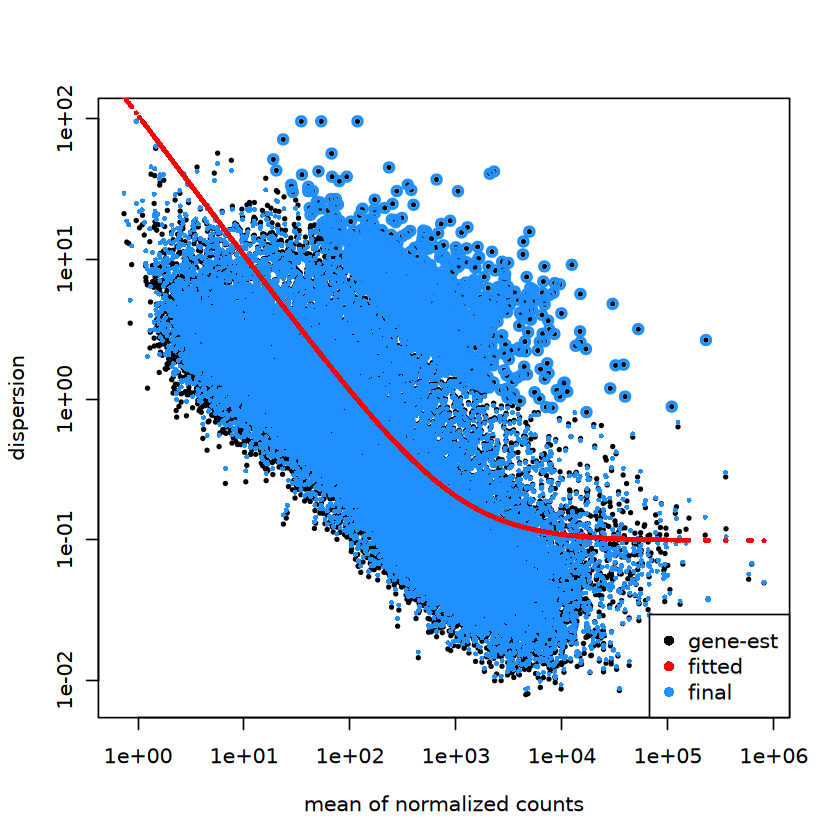

In [16]:
plotDispEsts(dds_filtered)

### nMDS
normalize and transform DESeq object using csv (variance stabilized expression matrix)

In [17]:
# normalization & transformation
vsd <- vst(dds_filtered)

# calculate sample distances
sample_dists <- assay(vsd) %>%
t() %>%
dist() %>%
as.matrix()

head(sample_dists)

# calculate MDS value from distance matrix
mdsData <- data.frame(cmdscale(sample_dists))
mds <- cbind(mdsData, as.data.frame(colData(vsd))) # combine with sample data
head(mds)

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
B1_B1_O01,0.00000,81.17469,84.48860,79.08079,83.95106,82.34655,91.47219,83.49670,83.45295,74.71603,⋯,99.31810,80.23296,70.37641,74.44621,71.35128,74.81232,95.29262,77.84672,76.12725,100.05484
B1_W5_O50,81.17469,0.00000,78.26415,68.56732,64.77855,70.46682,71.67051,82.23779,79.05891,78.36182,⋯,82.11093,86.24772,79.85927,79.98522,82.40868,79.59138,83.94963,81.38642,76.19416,80.50329
B2_B5_O51,84.48860,78.26415,0.00000,86.15990,80.53545,85.46521,82.04571,92.73349,95.80407,92.31772,⋯,87.72215,98.29659,89.80196,77.86505,88.77273,90.94060,88.38233,91.18474,87.02460,83.53047
B2_C4_O40,79.08079,68.56732,86.15990,0.00000,72.32386,70.51130,79.86594,80.24003,82.88784,73.22532,⋯,88.09038,81.39254,77.52661,77.49506,78.39671,76.59543,91.35576,75.68057,60.96719,88.57371
B3_B4_O41,83.95106,64.77855,80.53545,72.32386,0.00000,75.43176,77.50838,87.30230,75.78435,82.20989,⋯,80.15785,89.93878,80.93280,83.62561,87.47606,84.28828,79.88400,84.55540,79.55804,80.52718
B3_C3_O30,82.34655,70.46682,85.46521,70.51130,75.43176,0.00000,82.48342,86.02701,86.42159,81.41093,⋯,91.50152,87.99027,74.19626,83.74453,84.78347,81.06781,94.37442,78.25852,78.76372,92.71638


,X1,X2,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt,sizeFactor,group
,<dbl>,<dbl>,<chr>,<fct>,<fct>,<int>,<chr>,<fct>,<fct>,<int>,<fct>,<dbl>,<fct>
B1_B1_O01,11.491594,12.639810,both,warm,hypoxic,1,both,warm,hypoxic,1,both both,1.0589461,both both
B1_W5_O50,-2.333362,-16.608593,both,warm,hypoxic,1,warm,warm,normoxic,5,both warm,0.9973812,both warm
B2_B5_O51,-17.071450,-7.883250,both,warm,hypoxic,2,both,warm,hypoxic,5,both both,1.0525815,both both
B2_C4_O40,6.223148,-7.419990,both,warm,hypoxic,2,control,ambient,normoxic,4,both control,1.1432401,both control
B3_B4_O41,-7.832214,-16.339906,both,warm,hypoxic,3,both,warm,hypoxic,4,both both,0.8649451,both both
B3_C3_O30,6.504263,-5.832943,both,warm,hypoxic,3,control,ambient,normoxic,3,both control,0.8602578,both control


Warning message in MASS::cov.trob(data[, vars], wt = weight * nrow(data)):
“Probable convergence failure”


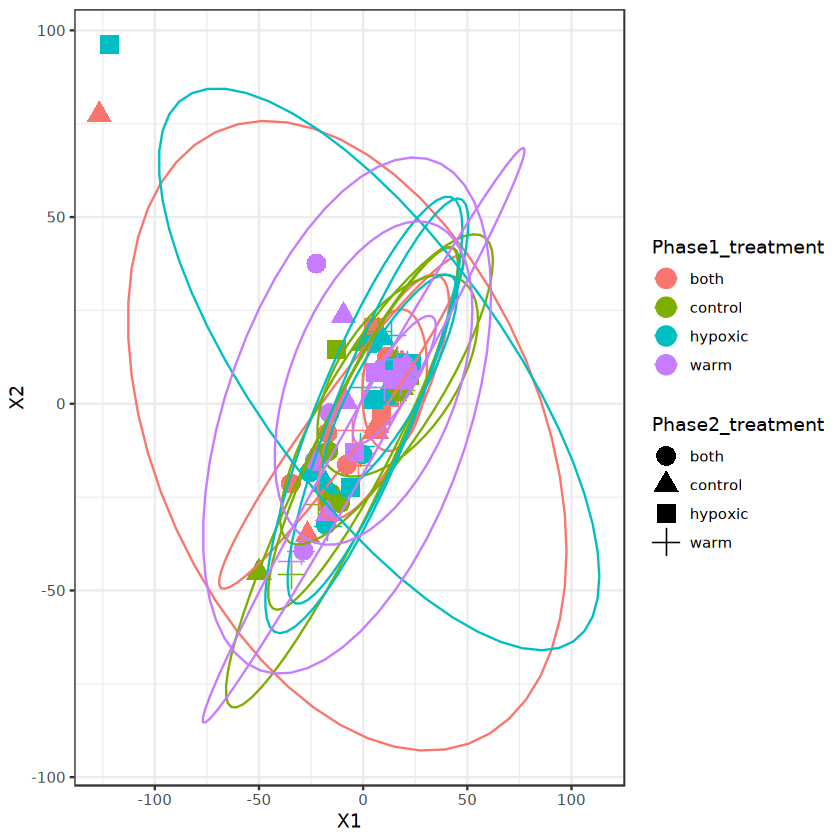

In [18]:
nmds.plot <- ggplot(mds, aes(X1, X2, col = Phase1_treatment, shape = Phase2_treatment)) +
geom_point(size = 5) +
stat_ellipse() + 
theme_bw()

nmds.plot

In [19]:
sample_dists <- dist(t(assay(vsd)))  # transpose so samples are rows
head(sample_dists)

meta <- as.data.frame(colData(vsd))
head(meta)

[1] 81.17469 84.48860 79.08079 83.95106 82.34655 91.47219

,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt,sizeFactor,group
,<chr>,<fct>,<fct>,<int>,<chr>,<fct>,<fct>,<int>,<fct>,<dbl>,<fct>
B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both both,1.0589461,both both
B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both warm,0.9973812,both warm
B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5,both both,1.0525815,both both
B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4,both control,1.1432401,both control
B3_B4_O41,both,warm,hypoxic,3,both,warm,hypoxic,4,both both,0.8649451,both both
B3_C3_O30,both,warm,hypoxic,3,control,ambient,normoxic,3,both control,0.8602578,both control


In [20]:
adonis2(sample_dists ~ Phase1_temp * Phase1_DO * Phase2_temp * Phase2_DO, data = meta, permutations = 999)

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Phase1_temp,1,3236.924,0.008307427,0.7930077,0.791
Phase1_DO,1,3376.258,0.008665020,0.8271427,0.718
Phase2_temp,1,8814.911,0.022623088,2.1595475,0.002
Phase2_DO,1,5828.697,0.014959099,1.4279609,0.059
Phase1_temp:Phase1_DO,1,2739.712,0.007031354,0.6711967,0.967
Phase1_temp:Phase2_temp,1,2713.907,0.006965124,0.6648746,0.965
Phase1_DO:Phase2_temp,1,3698.967,0.009493240,0.9062026,0.624
Phase1_temp:Phase2_DO,1,3207.229,0.008231214,0.7857326,0.823
Phase1_DO:Phase2_DO,1,3594.704,0.009225652,0.8806593,0.631


- Phase2_temp has a significant effect on GE (P = 0.004) and explains ~2.2% of the variation in GE
- Phase2_DO also has a significant effect on GE (P = 0.040) and explains ~1.5% of the variance
- The interaction of Phase2_temp and Phase2_DO is significant (P = 0.050) and explains ~1.5% of the variation in GE
    - this means the effect of phase 2 temp depends on the value of phase 2 DO (or vice versa)
- The majoirty of the variation in GE is not explained by the treatments (R2 = 0.84)

### heatmap of sample-to-sample distances using the variance stabilizing transformed values
following [RNA-seq workflow](https://master.bioconductor.org/packages/release/workflows/vignettes/rnaseqGene/inst/doc/rnaseqGene.html) from Mike Love

In [21]:
# normalization & transformation
vsd <- vst(dds_filtered)

# calculate sample distances
sample_dists <- dist(t(assay(dds_filtered)))
head(sample_dists)

[1]  559109.0  658789.3  525933.1  551766.8  502959.1 1120977.4

In [22]:
head(vsd)

class: DESeqTransform 
dim: 6 96 
metadata(1): version
assays(1): ''
rownames(6): LOC144621260 LOC144621269 ... LOC144621276 LOC111115920
rowData names(78): baseMean baseVar ... maxCooks dispFit
colnames(96): B1_B1_O01 B1_W5_O50 ... W6_W3_G36 W6_W4_G48
colData names(11): Phase1_treatment Phase1_temp ... sizeFactor group

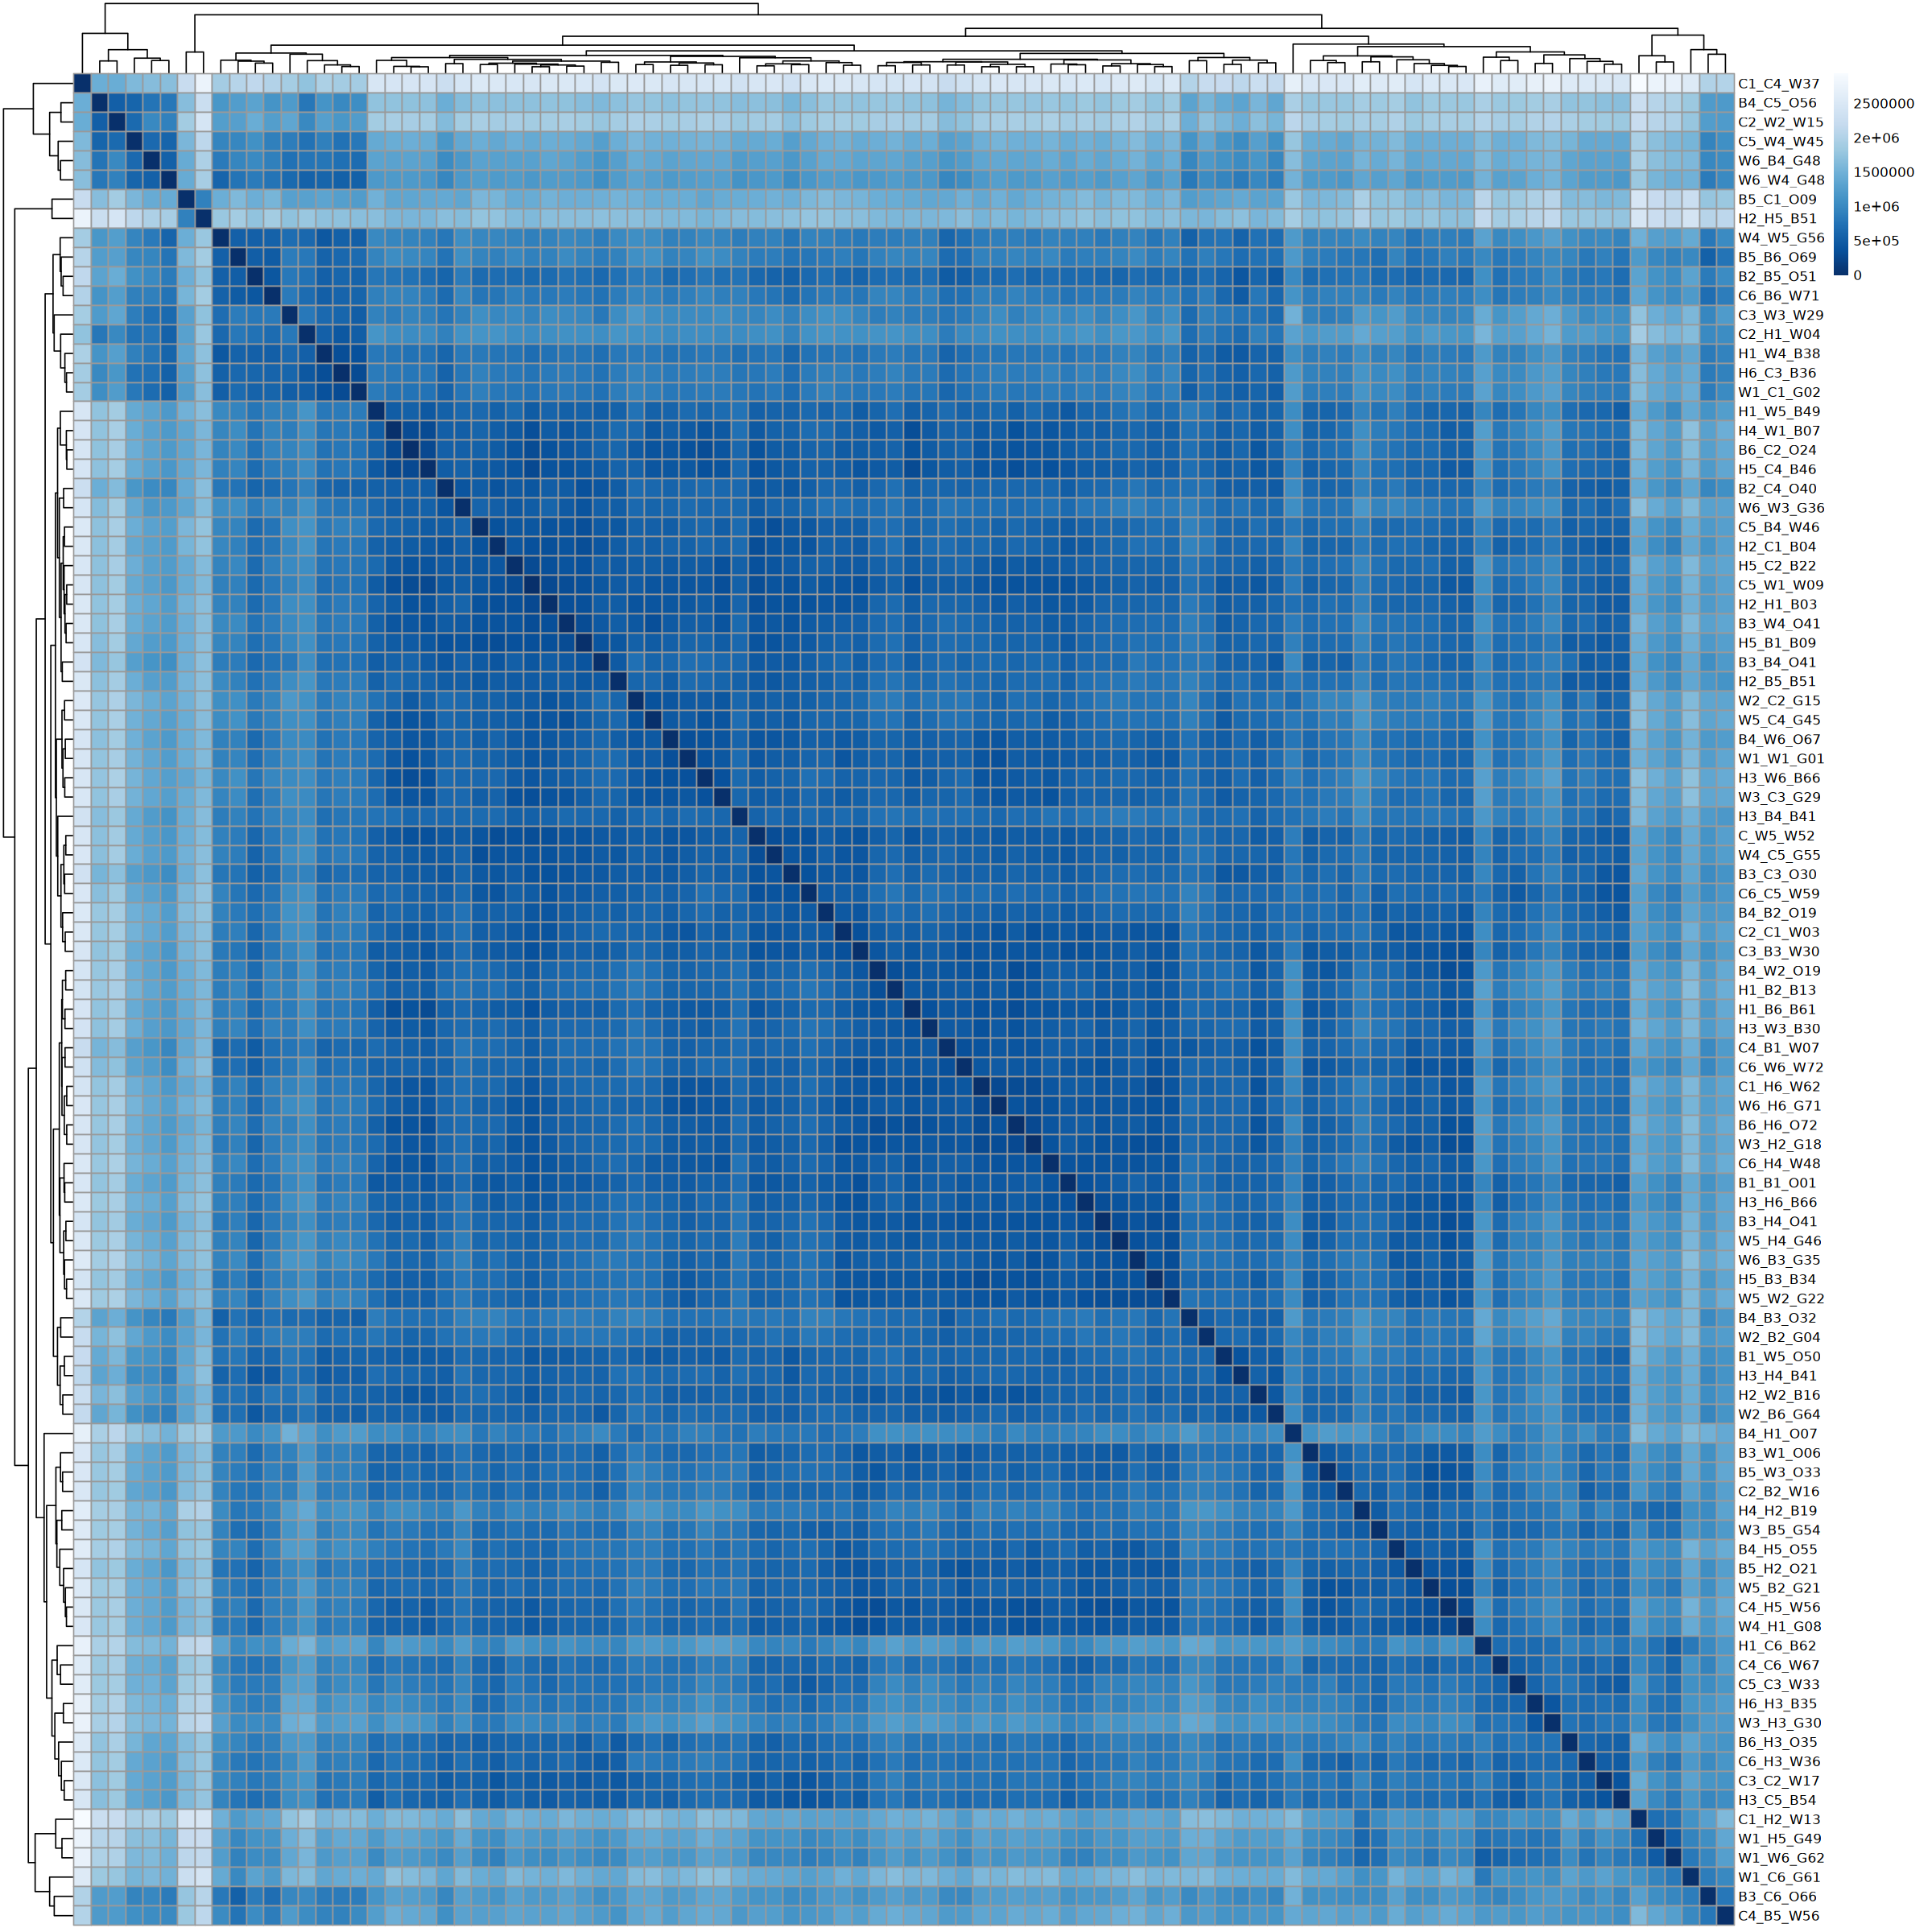

In [23]:
options(repr.plot.width=20, repr.plot.height=20)

sampleDistMatrix <- as.matrix(sample_dists)
rownames(sampleDistMatrix) <- paste(colnames(vsd))
colnames(sampleDistMatrix) <- NULL
colors <- colorRampPalette( rev(brewer.pal(9, "Blues")) )(255)
pheatmap(sampleDistMatrix,
         clustering_distance_rows = sample_dists,
         clustering_distance_cols = sample_dists,
         col = colors)

it's weird that there's two samples that are very dissimilar to every other sample, but appear closer together - (HH and BC) - if you look at the nMDS plots too, they look like outliers from their replicates so should consider removing those samples from analysis 

there's those two samples again in the bottom of the plot - B5_C1_O09 and H2_H5_B51 - that cluster away from everything else 

what do things look like if I remove those?

In [26]:
# remove two samples
dds_rm<- dds_filtered[, !colnames(dds_filtered) %in% c("B5_C1_O09", "H2_H5_B51")]

In [27]:
# normalization & transformation
vsd_filtered <- vst(dds_rm)

# calculate sample distances
sample_dists_filtered <- dist(t(assay(vsd_filtered)))
head(sample_dists_filtered)

[1] 80.56880 83.86479 78.49837 83.33886 81.75433 90.81074

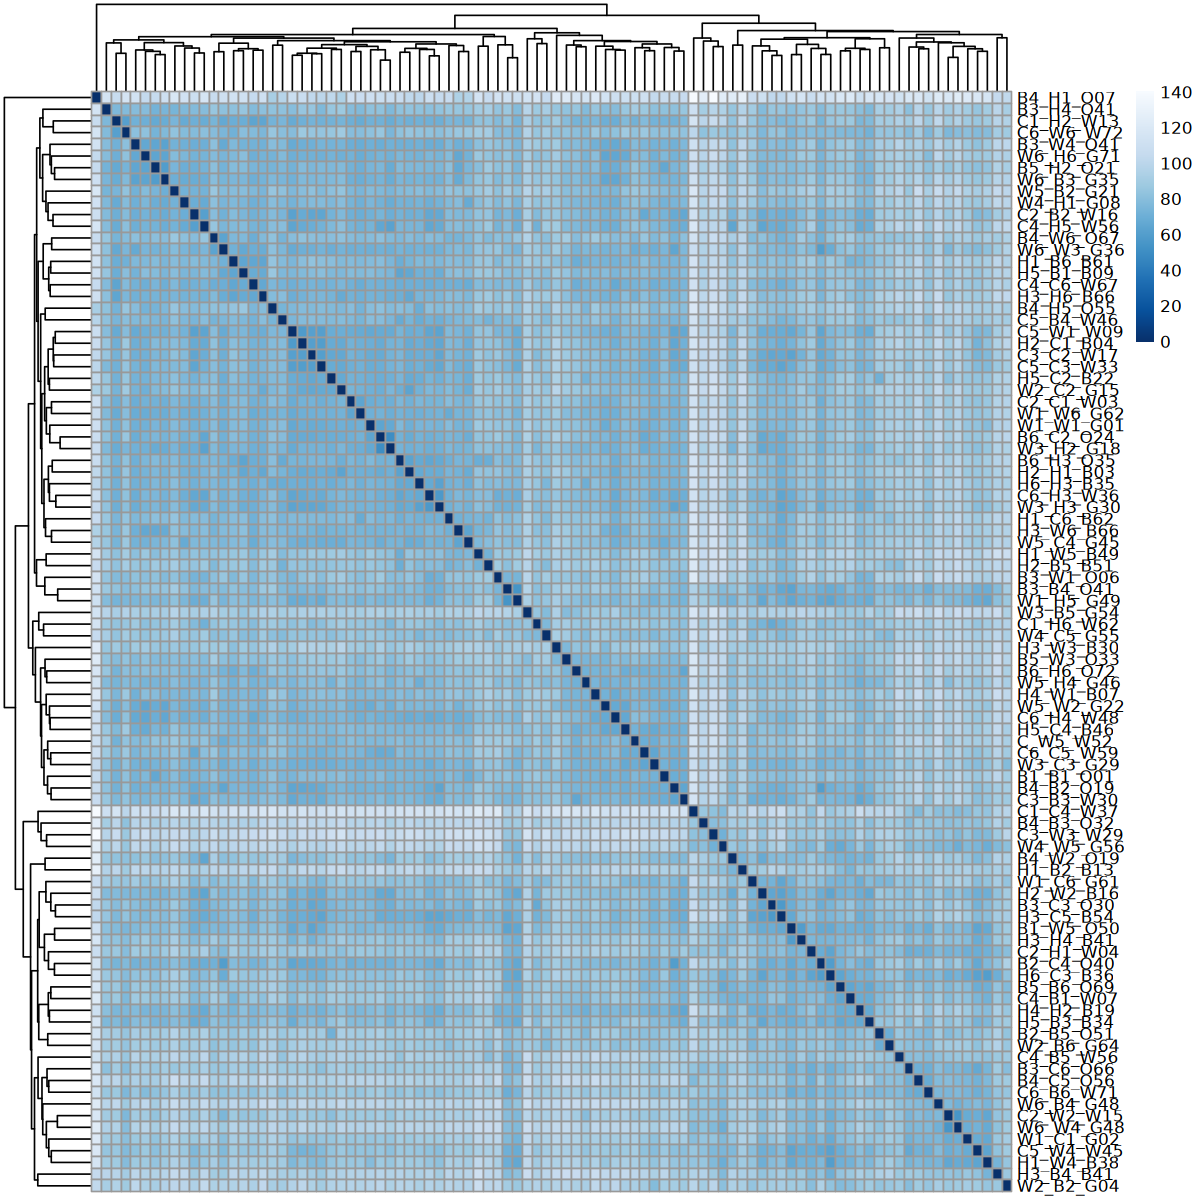

In [28]:
sampleDistMatrix <- as.matrix(sample_dists_filtered)
rownames(sampleDistMatrix) <- paste(colnames(vsd_filtered))
colnames(sampleDistMatrix) <- NULL
colors <- colorRampPalette( rev(brewer.pal(9, "Blues")) )(255)
pheatmap(sampleDistMatrix,
         clustering_distance_rows = sample_dists_filtered,
         clustering_distance_cols = sample_dists_filtered,
         col = colors)

In [29]:
pcaData_filtered <- plotPCA(vsd_filtered, intgroup = c( "Phase1_treatment", "Phase2_treatment"), returnData = TRUE)
head(pcaData_filtered)

using ntop=500 top features by variance



,PC1,PC2,group,Phase1_treatment,Phase2_treatment,name
,<dbl>,<dbl>,<fct>,<chr>,<chr>,<chr>
B1_B1_O01,-13.110647,-8.330373,both:both,both,both,B1_B1_O01
B1_W5_O50,12.421904,4.383282,both:warm,both,warm,B1_W5_O50
B2_B5_O51,15.652446,-13.012978,both:both,both,both,B2_B5_O51
B2_C4_O40,2.546170,7.187841,both:control,both,control,B2_C4_O40
B3_B4_O41,15.867706,6.575690,both:both,both,both,B3_B4_O41
B3_C3_O30,1.332008,5.057415,both:control,both,control,B3_C3_O30


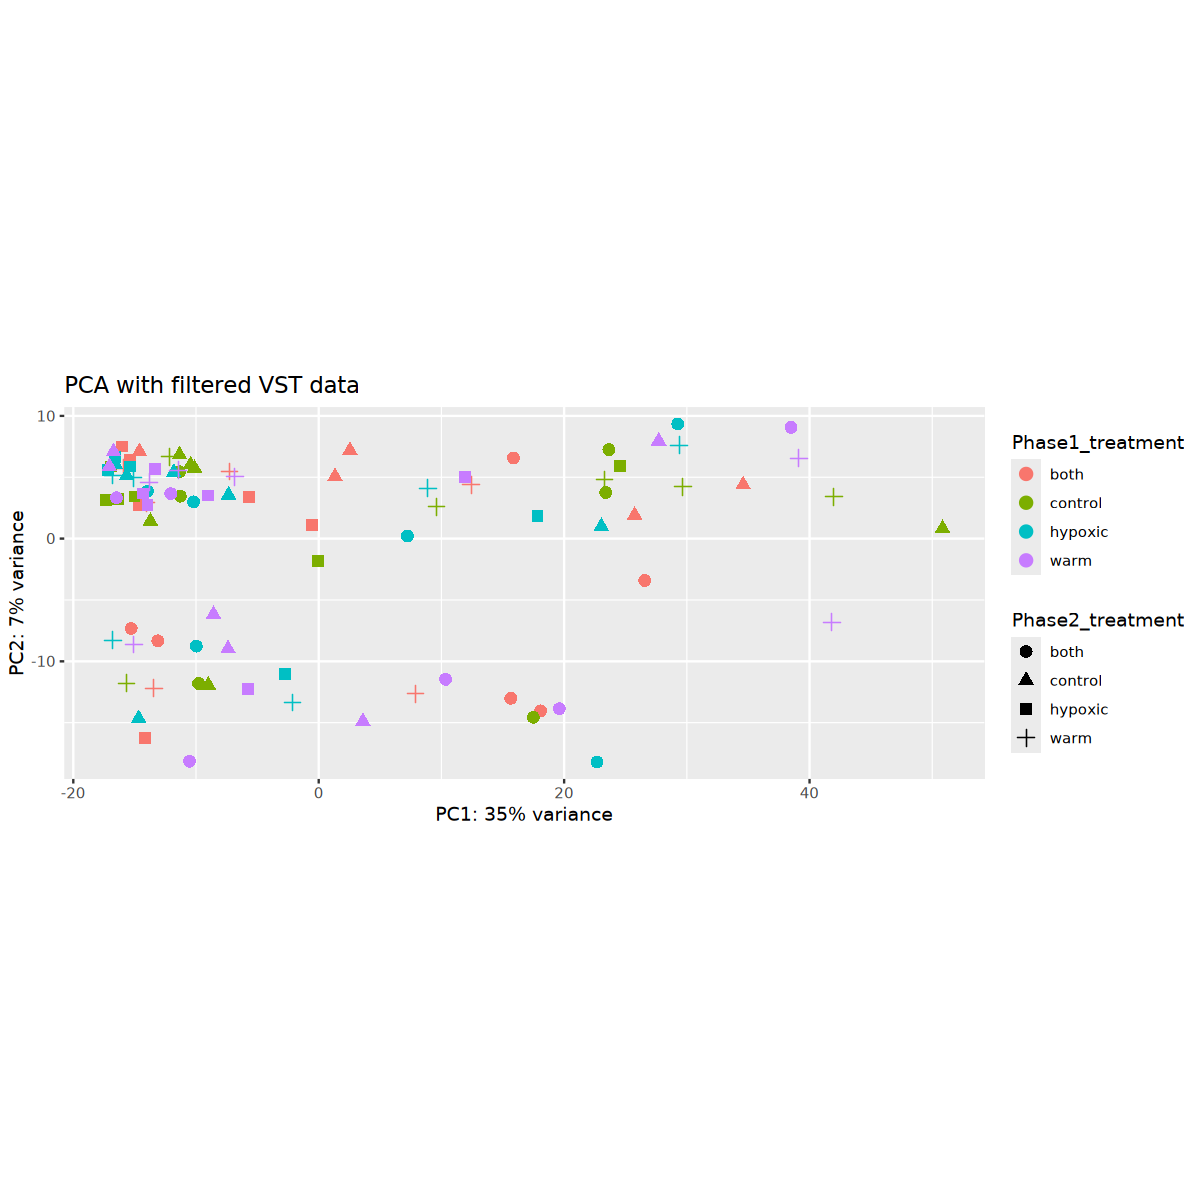

In [30]:
options(repr.plot.width=10, repr.plot.height=10)

percentVar <- round(100 * attr(pcaData_filtered, "percentVar"))

ggplot(pcaData_filtered, aes(x = PC1, y = PC2, color = Phase1_treatment, shape = Phase2_treatment)) +
  geom_point(size =3) +
  xlab(paste0("PC1: ", percentVar[1], "% variance")) +
  ylab(paste0("PC2: ", percentVar[2], "% variance")) +
  coord_fixed() +
  ggtitle("PCA with filtered VST data")

In [31]:
# calculate MDS value from distance matrix
mdsData_filtered <- data.frame(cmdscale(sample_dists_filtered))
mds_filtered <- cbind(mdsData_filtered, as.data.frame(colData(vsd_filtered))) # combine with sample data
head(mds_filtered)

,X1,X2,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt,sizeFactor,group
,<dbl>,<dbl>,<chr>,<fct>,<fct>,<int>,<chr>,<fct>,<fct>,<int>,<fct>,<dbl>,<fct>
B1_B1_O01,16.0046465,-8.792288998,both,warm,hypoxic,1,both,warm,hypoxic,1,both both,1.0589461,both both
B1_W5_O50,-13.6021237,6.083812880,both,warm,hypoxic,1,warm,warm,normoxic,5,both warm,0.9973812,both warm
B2_B5_O51,-18.8291291,-0.658455087,both,warm,hypoxic,2,both,warm,hypoxic,5,both both,1.0525815,both both
B2_C4_O40,-0.9679314,0.006604586,both,warm,hypoxic,2,control,ambient,normoxic,4,both control,1.1432401,both control
B3_B4_O41,-17.3399189,9.290500622,both,warm,hypoxic,3,both,warm,hypoxic,4,both both,0.8649451,both both
B3_C3_O30,0.1441657,15.910793629,both,warm,hypoxic,3,control,ambient,normoxic,3,both control,0.8602578,both control


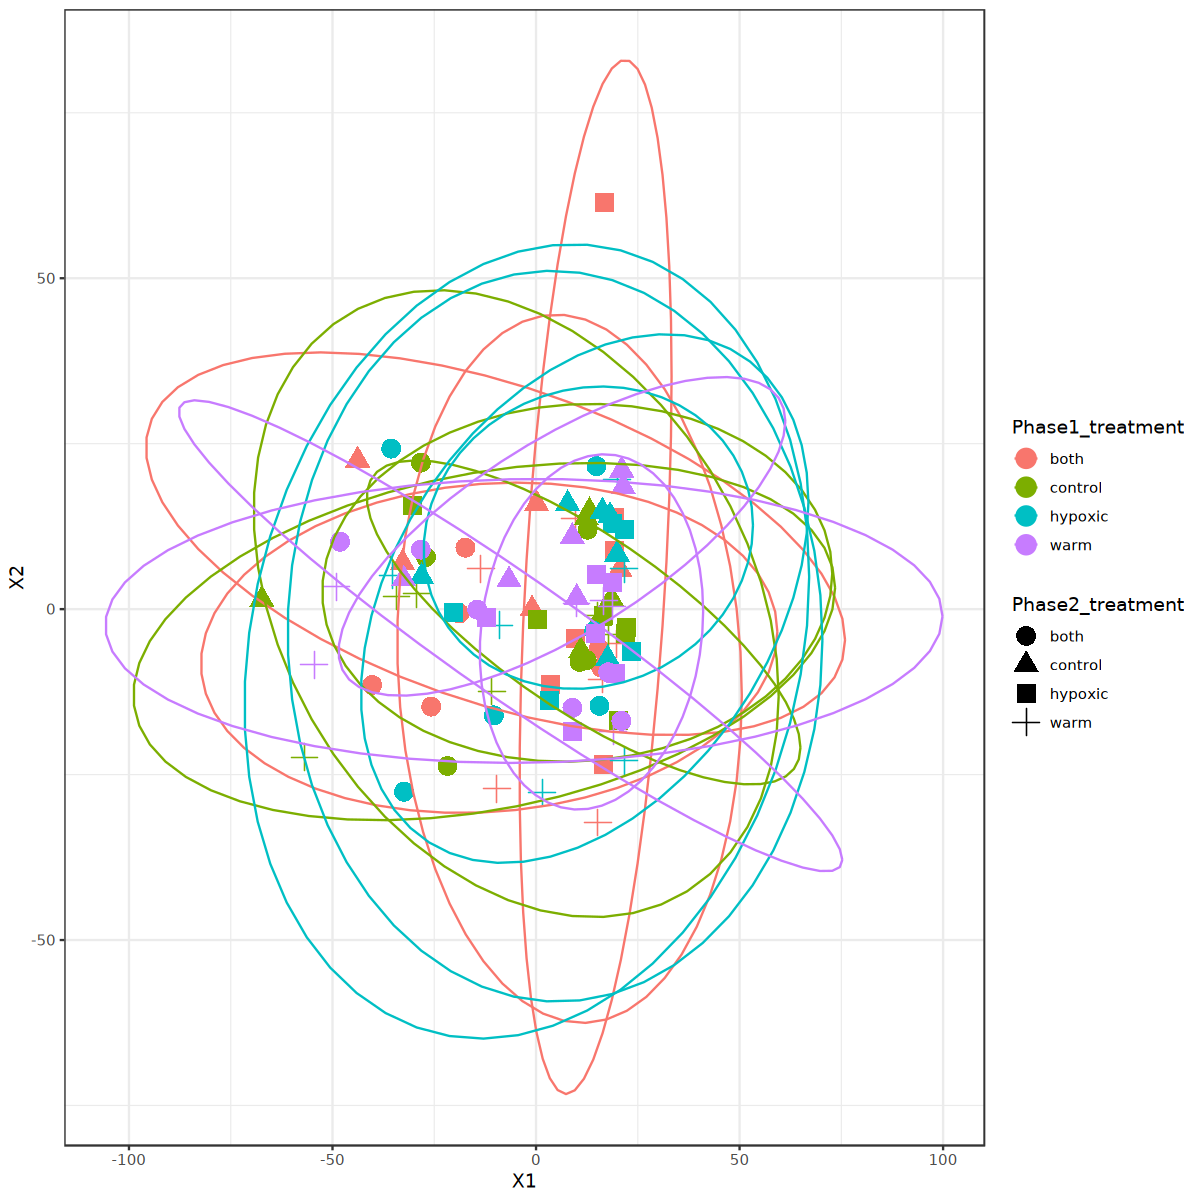

In [32]:
ggplot(mds_filtered, aes(X1, X2, col = Phase1_treatment, shape = Phase2_treatment)) +
geom_point(size = 5) +
stat_ellipse() + 
theme_bw()

okay so it appears when we remove those two seemingly outlier samples, the data gets a little bit 'more clear' and replicates segregate a little better

let's remove those samples (**B5_C1_O09** and **H2_H5_B51**) and re-run DESeq2

## 2b. remove outliers, run DESeq again

In [33]:
outlier_samples <- c('B5_C1_O09', 'H2_H5_B51', 'B4_H1_O07', 'C1_C4_W37')

dds_rm <- dds_filtered[, !colnames(dds_filtered) %in% outlier_samples]
dds_rm <- DESeq(dds_rm)

using pre-existing size factors

estimating dispersions

found already estimated dispersions, replacing these

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

final dispersion estimates

fitting model and testing



In [34]:
dds_rm

class: DESeqDataSet 
dim: 26060 92 
metadata(1): version
assays(4): counts mu H cooks
rownames(26060): LOC144621260 LOC144621269 ... LOC144621306
  LOC144621888
rowData names(78): baseMean baseVar ... deviance maxCooks
colnames(92): B1_B1_O01 B1_W5_O50 ... W6_W3_G36 W6_W4_G48
colData names(11): Phase1_treatment Phase1_temp ... sizeFactor group

In [35]:
vsd <- vst(dds_rm, blind = FALSE)
vst_mat <- assay(vsd)
head(vst_mat)

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
LOC144621260,11.623469,11.423471,11.408838,11.275151,11.000572,10.984042,11.367711,11.063231,11.165032,11.186417,⋯,11.835304,10.661320,11.109093,11.545469,11.412500,11.239716,11.371961,11.224874,11.809569,11.656580
LOC144621269,9.029866,11.165142,11.566796,10.565749,11.604647,10.704805,12.821577,11.068945,8.822612,8.684961,⋯,13.912374,8.621367,8.691295,10.274234,8.968732,9.263748,13.469161,8.803617,9.970848,13.447100
LOC111120925,9.098889,8.848789,10.019625,8.719850,8.800497,8.700895,8.483578,8.561028,8.483578,8.559747,⋯,9.898177,8.483578,8.630520,10.036487,9.143250,8.897954,8.666530,8.563742,8.746574,8.719664
LOC144621283,10.155971,10.545362,10.566871,10.406314,10.492742,10.753400,10.721783,10.029620,10.340600,10.432119,⋯,10.240015,10.675777,10.441461,10.568882,10.541882,10.464685,10.218781,11.013852,10.231790,10.260001
LOC144621276,13.471496,13.514187,13.684737,13.520469,13.795151,13.915398,13.731482,13.241632,13.773795,13.454805,⋯,14.039092,13.330391,13.866055,13.565448,13.121654,13.302953,13.949750,13.395173,13.440389,13.391663
LOC111115920,9.429854,9.490282,9.402242,9.264949,9.195805,9.150586,9.071305,9.912396,9.234906,9.790446,⋯,9.168003,9.248230,9.651698,9.353947,9.937921,9.940522,9.492055,9.633900,9.216327,9.313269


In [36]:
length(colnames(vst_mat))

[1] 92

In [ ]:
#write.csv(vst_mat, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/vst_filtered.csv', row.names = TRUE)

In [37]:
meta_noOutliers <- meta[!rownames(meta) %in% outlier_samples, ]

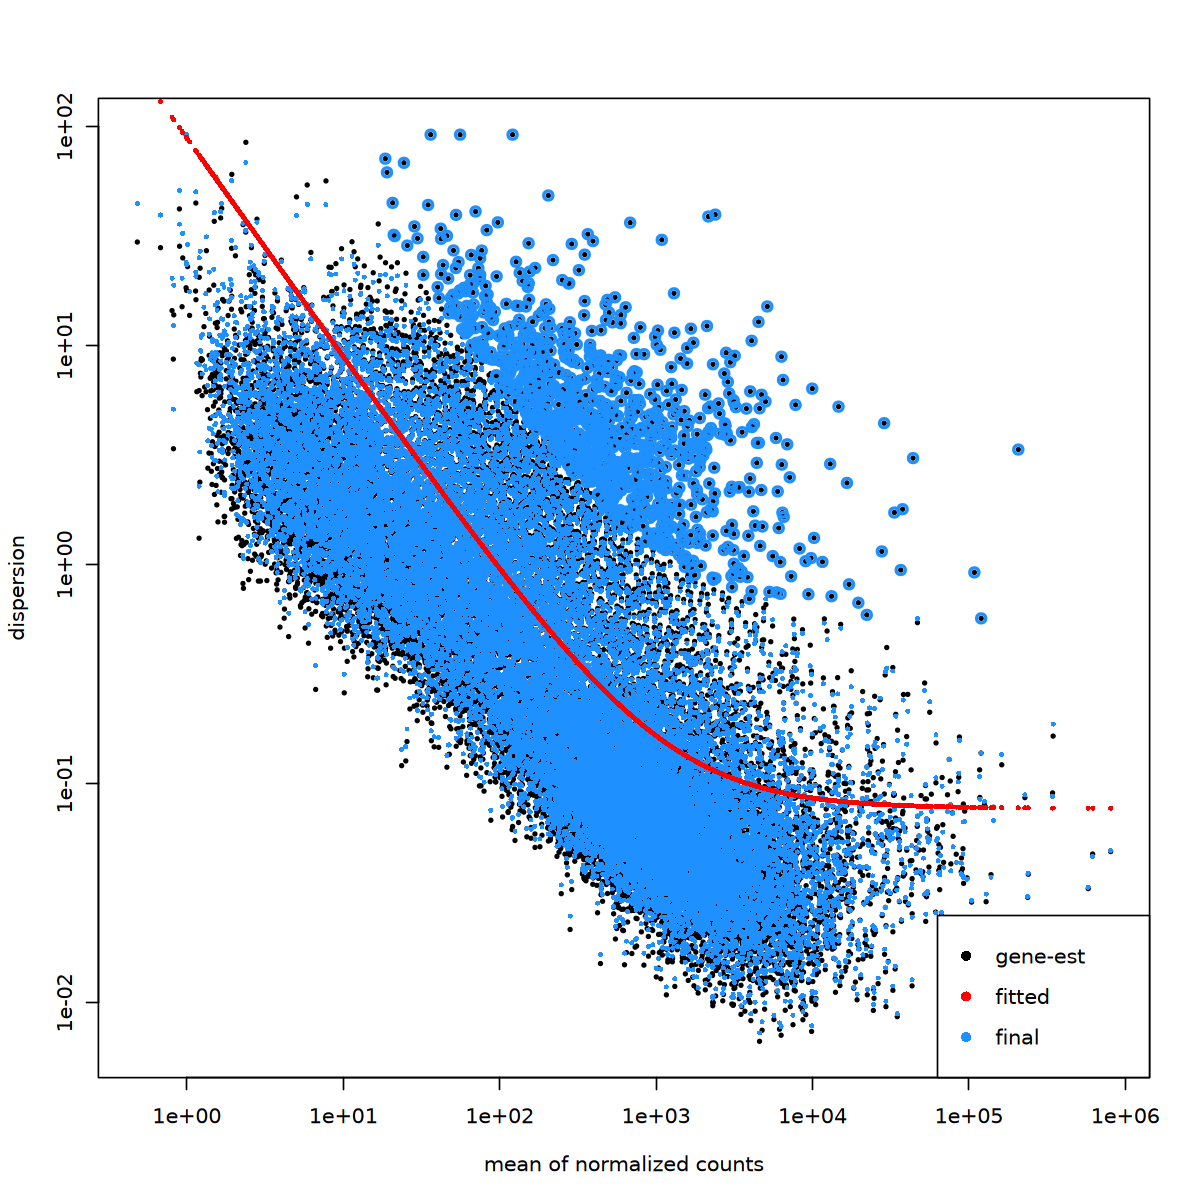

In [38]:
options(repr.plot.height = 10, repr.plot.width = 10)

plotDispEsts(dds_rm)

### nMDS
normalize and transform DESeq object using vst (variance stabilized expression matrix)

In [39]:
# variance stabilizing transformation
vsd <- vst(dds_rm, blind = FALSE)
head(assay(vsd))

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
LOC144621260,11.623469,11.423471,11.408838,11.275151,11.000572,10.984042,11.367711,11.063231,11.165032,11.186417,⋯,11.835304,10.661320,11.109093,11.545469,11.412500,11.239716,11.371961,11.224874,11.809569,11.656580
LOC144621269,9.029866,11.165142,11.566796,10.565749,11.604647,10.704805,12.821577,11.068945,8.822612,8.684961,⋯,13.912374,8.621367,8.691295,10.274234,8.968732,9.263748,13.469161,8.803617,9.970848,13.447100
LOC111120925,9.098889,8.848789,10.019625,8.719850,8.800497,8.700895,8.483578,8.561028,8.483578,8.559747,⋯,9.898177,8.483578,8.630520,10.036487,9.143250,8.897954,8.666530,8.563742,8.746574,8.719664
LOC144621283,10.155971,10.545362,10.566871,10.406314,10.492742,10.753400,10.721783,10.029620,10.340600,10.432119,⋯,10.240015,10.675777,10.441461,10.568882,10.541882,10.464685,10.218781,11.013852,10.231790,10.260001
LOC144621276,13.471496,13.514187,13.684737,13.520469,13.795151,13.915398,13.731482,13.241632,13.773795,13.454805,⋯,14.039092,13.330391,13.866055,13.565448,13.121654,13.302953,13.949750,13.395173,13.440389,13.391663
LOC111115920,9.429854,9.490282,9.402242,9.264949,9.195805,9.150586,9.071305,9.912396,9.234906,9.790446,⋯,9.168003,9.248230,9.651698,9.353947,9.937921,9.940522,9.492055,9.633900,9.216327,9.313269


In [40]:
# calculate sample distances
sample_dists <- assay(vsd) %>%
t() %>%
dist() %>%
as.matrix()

head(sample_dists)

# calculate MDS value from distance matrix
mdsData <- data.frame(cmdscale(sample_dists))
mds <- cbind(mdsData, as.data.frame(colData(vsd))) # combine with sample data
head(mds)

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
B1_B1_O01,0.00000,81.05438,84.36473,78.96515,83.82950,82.22897,91.34086,83.37069,83.33753,74.60543,⋯,99.18040,80.11536,70.27711,74.33794,71.24632,74.70062,95.16339,77.73474,76.01661,99.91575
B1_W5_O50,81.05438,0.00000,78.14444,68.46881,64.68388,70.36510,71.56501,82.11807,78.95112,78.24557,⋯,81.99964,86.12387,79.74161,79.86841,82.28850,79.47582,83.83553,81.26913,76.08288,80.38987
B2_B5_O51,84.36473,78.14444,0.00000,86.03586,80.41595,85.33788,81.92405,92.59697,95.66805,92.18366,⋯,87.60077,98.15491,89.66849,77.75370,88.64503,90.80736,88.25958,91.05225,86.89929,83.41549
B2_C4_O40,78.96515,68.46881,86.03586,0.00000,72.22323,70.41162,79.75209,80.12270,82.77844,73.11420,⋯,87.97269,81.27520,77.41400,77.38288,78.28200,76.48491,91.23279,75.57144,60.87540,88.45088
B3_B4_O41,83.82950,64.68388,80.41595,72.22323,0.00000,75.32381,77.39728,87.17872,75.68428,82.09094,⋯,80.04957,89.81285,80.81508,83.50678,87.35314,84.16942,79.77210,84.43673,79.44505,80.41415
B3_C3_O30,82.22897,70.36510,85.33788,70.41162,75.32381,0.00000,82.36413,85.90469,86.30665,81.29381,⋯,91.37605,87.86846,74.08503,83.62610,84.66437,80.95308,94.24608,78.14530,78.65124,92.58801


,X1,X2,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt,sizeFactor,group
,<dbl>,<dbl>,<chr>,<fct>,<fct>,<int>,<chr>,<fct>,<fct>,<int>,<fct>,<dbl>,<fct>
B1_B1_O01,15.510958,14.85234,both,warm,hypoxic,1,both,warm,hypoxic,1,both both,1.0589461,both both
B1_W5_O50,-14.624564,-12.18380,both,warm,hypoxic,1,warm,warm,normoxic,5,both warm,0.9973812,both warm
B2_B5_O51,-20.016206,16.47871,both,warm,hypoxic,2,both,warm,hypoxic,5,both both,1.0525815,both both
B2_C4_O40,-1.562856,-13.45336,both,warm,hypoxic,2,control,ambient,normoxic,4,both control,1.1432401,both control
B3_B4_O41,-18.654898,-11.41609,both,warm,hypoxic,3,both,warm,hypoxic,4,both both,0.8649451,both both
B3_C3_O30,-1.173129,-17.92709,both,warm,hypoxic,3,control,ambient,normoxic,3,both control,0.8602578,both control


In [41]:
mds$Phase1_treatment <- factor(mds$Phase1_treatment, levels = c('control', 'warm', 'hypoxic', 'both'))

mds$Phase2_treatment <- factor(mds$Phase2_treatment, levels = c('control', 'warm', 'hypoxic', 'both'))

#### all treatments

Ignoring unknown labels:
• fill : "Phase 1 Treatment"


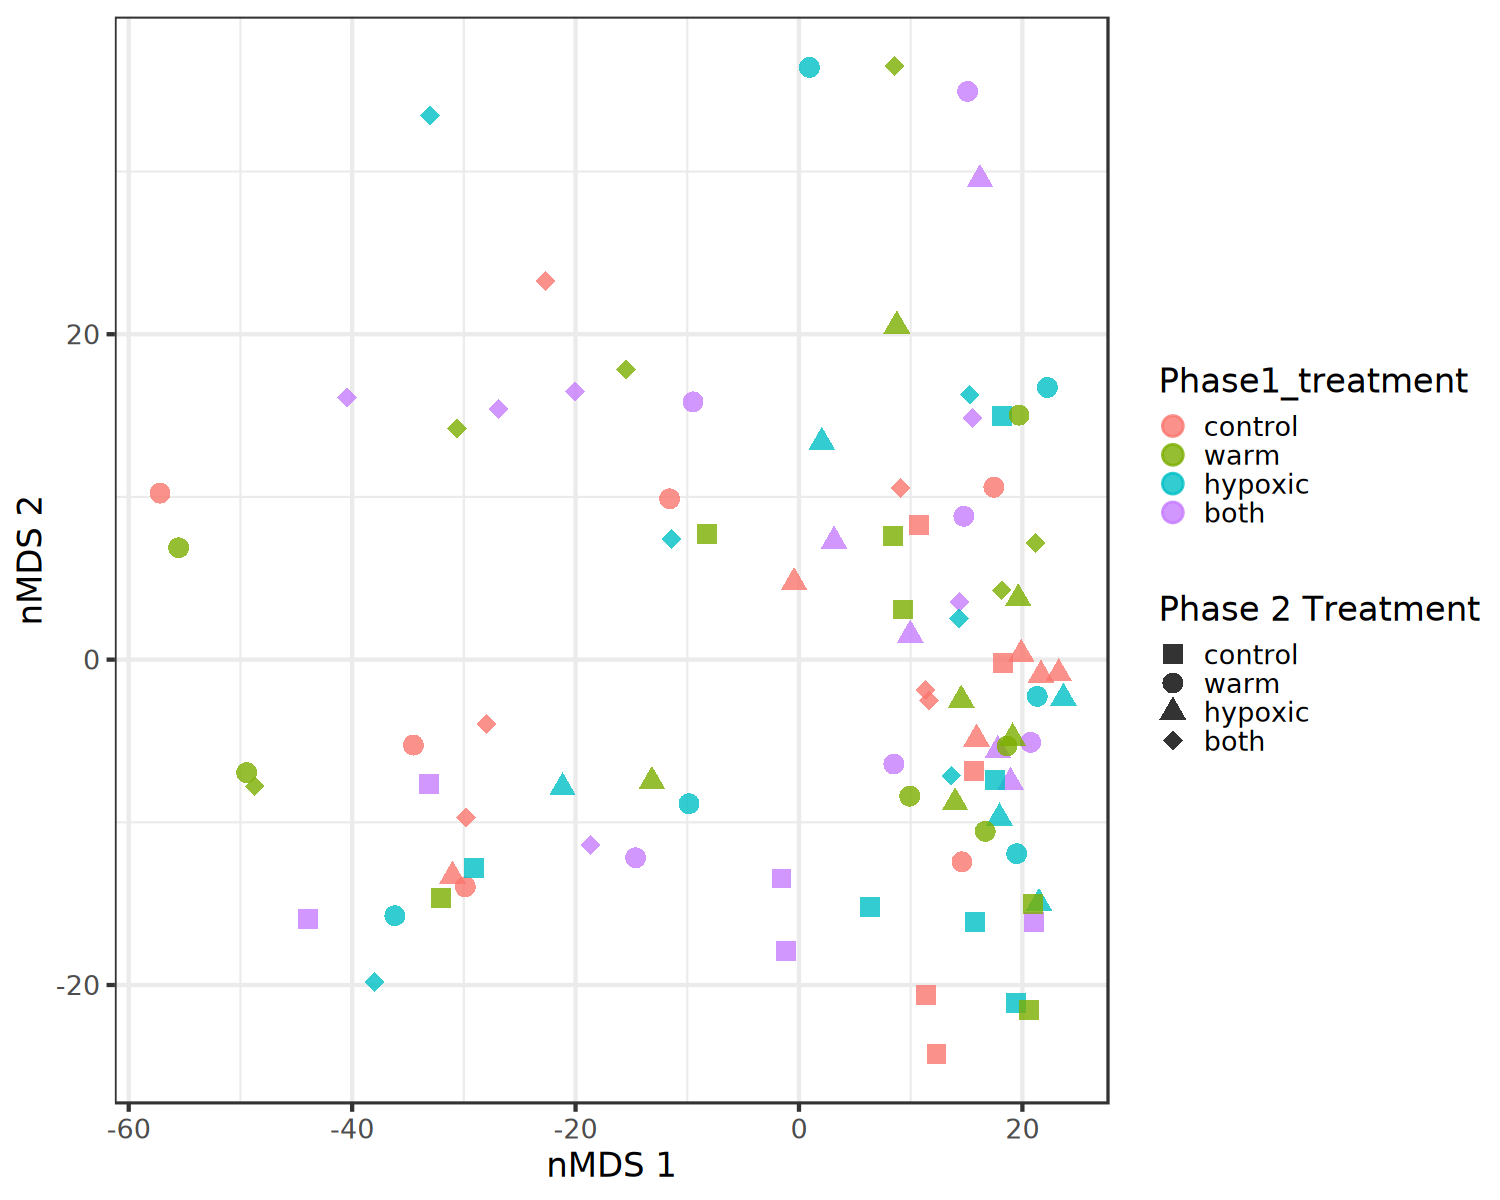

In [42]:
options(repr.plot.width = 12.5, repr.plot.height = 10)

nmds.plot <- ggplot(mds, aes(X1, X2, col = Phase1_treatment, shape = Phase2_treatment)) +
geom_point(
    size = 5,
    alpha = 0.8,
  ) +
scale_shape_manual(values = c(15, 16, 17,18)) +
# stat_ellipse() + 
theme_bw(base_size = 20) +
labs(x = 'nMDS 1', 
     y = 'nMDS 2',
    fill = 'Phase 1 Treatment',
    shape = 'Phase 2 Treatment')

nmds.plot

#### permANOVA

differences in centroid location(position) between two groups

In [43]:
adonis2(sample_dists ~ Phase1_temp * Phase1_DO * Phase2_temp * Phase2_DO, data = meta_noOutliers, permutations = 999)

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Phase1_temp,1,3221.751,0.010034440,0.9276520,0.550
Phase1_DO,1,2675.027,0.008331619,0.7702316,0.899
Phase2_temp,1,9155.971,0.028517117,2.6363168,0.001
Phase2_DO,1,5305.676,0.016525018,1.5276853,0.027
Phase1_temp:Phase1_DO,1,2689.338,0.008376192,0.7743523,0.902
Phase1_temp:Phase2_temp,1,2690.928,0.008381144,0.7748101,0.890
Phase1_DO:Phase2_temp,1,3173.095,0.009882898,0.9136425,0.592
Phase1_temp:Phase2_DO,1,2736.705,0.008523719,0.7879908,0.860
Phase1_DO:Phase2_DO,1,3414.139,0.010633650,0.9830471,0.455


significant effects:
- phase2_temp (2.6% of variance)
- phase2_DO (1.7% of variance)
- phase2_temp:phase2_DO (1.7% of variance)

reformatting the nmds to look at the sig. effects of phase 2 temp and DO

#### p2 temp and DO 

In [44]:
mds$Phase2_temp <- factor(mds$Phase2_temp, levels = c('ambient', 'warm'))

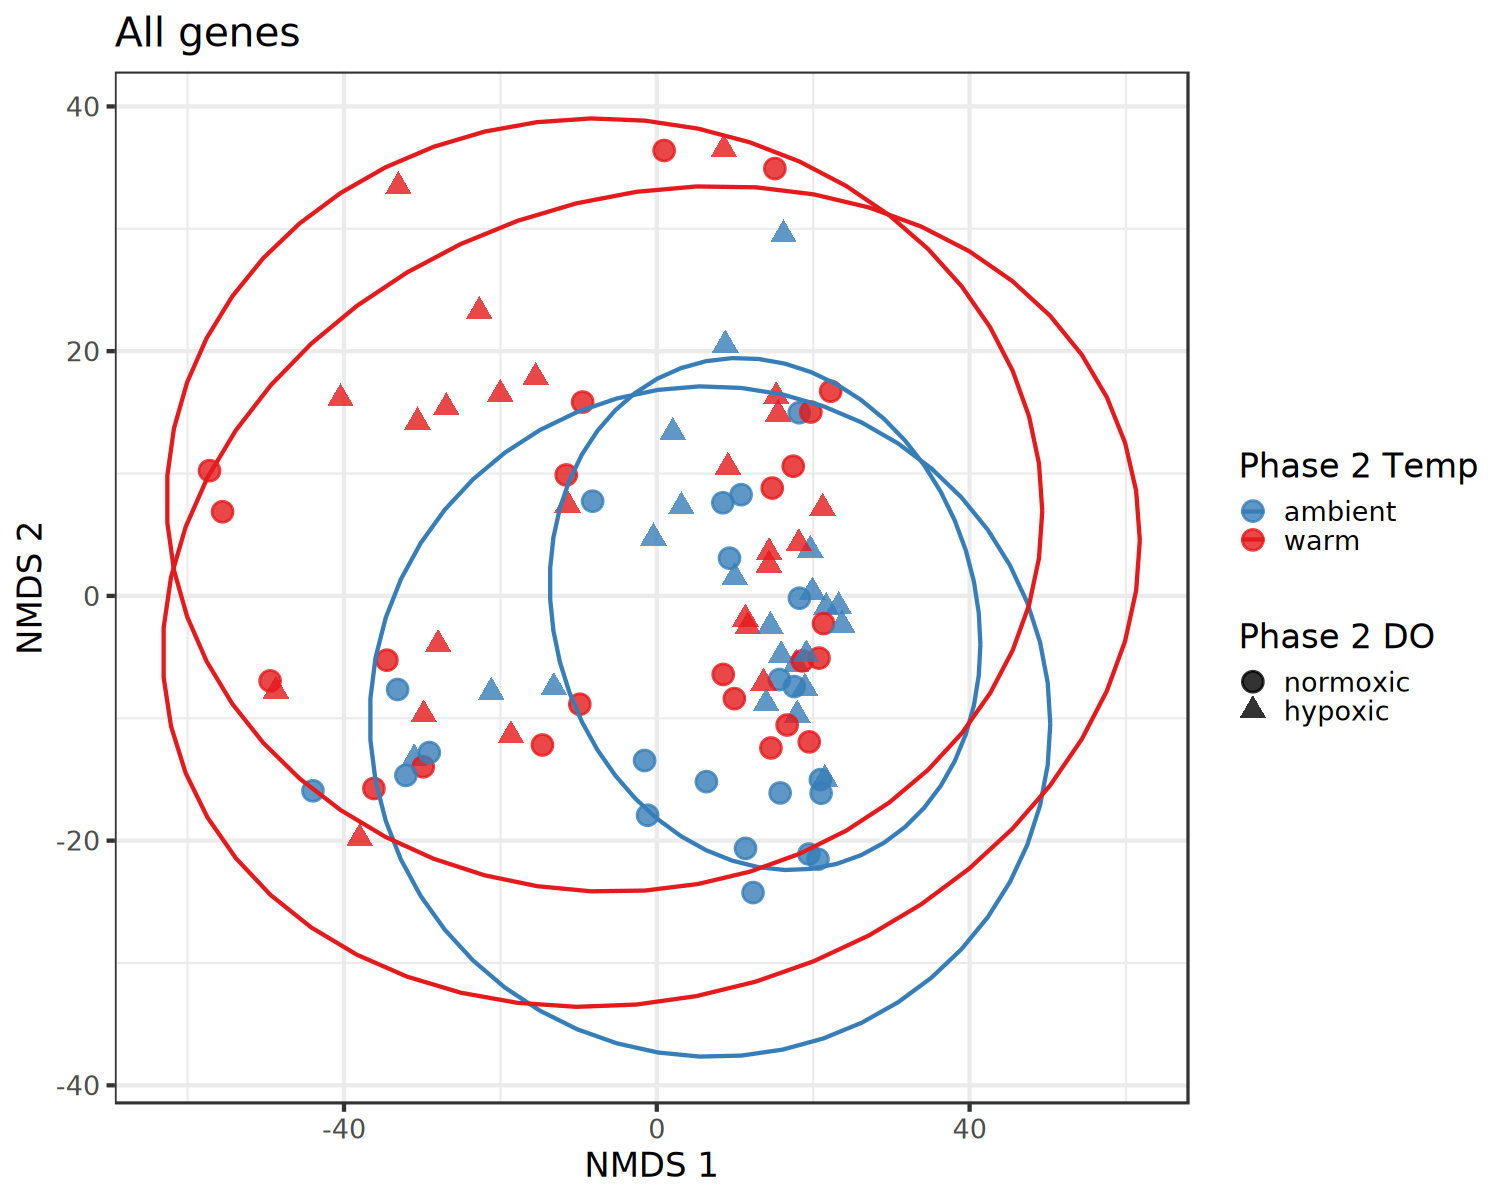

In [48]:
options(repr.plot.width = 12.5, repr.plot.height = 10)

nmds.plot2 <- ggplot(mds, aes(X1, X2, col = Phase2_temp, shape = Phase2_DO)) +
geom_point(
    size = 5,
    alpha = 0.8
  ) +
scale_shape_manual(values = c(19, 17)) +
scale_color_brewer(palette = 'Set1', direction = -1) +
 stat_ellipse() + 
theme_bw(base_size = 20) +
labs(x = 'NMDS 1', 
     y = 'NMDS 2',
    col = 'Phase 2 Temp',
    shape = 'Phase 2 DO',
    title = 'All genes')

nmds.plot2

the blue circles, which are phase 2 warm temp treatment, seem to overlap and have a large dispersion

meanwhile, the red circles, which are phase 2 ambient temp treatment, have some overlap but different dispersion patterns - ambient and hypoxic in phase 2 result in tighter clustering, while ambient and normoxic in phase 2 have wider dispersion

in ambient temperatures, oysters have different transcriptomic profiles depending on the DO treatment. in warm temperatures, the effect of DO is negligible - so warming supersedes DO?

#### just p2 temp

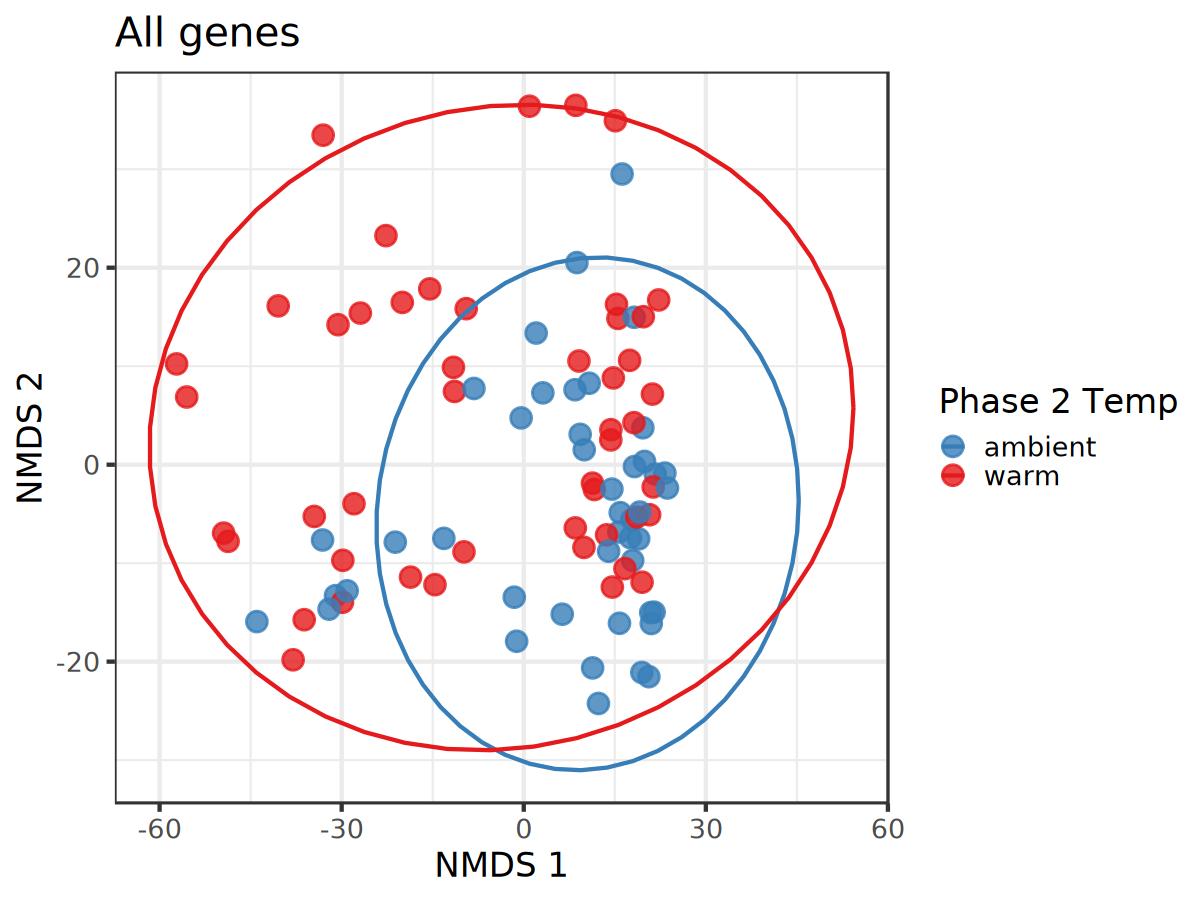

In [56]:
options(repr.plot.width = 10, repr.plot.height = 7.5)

nmds.plot2 <- ggplot(mds, aes(X1, X2, col = Phase2_temp)) +
geom_point(
    size = 5,
    alpha = 0.8
  ) +
scale_shape_manual(values = c(19, 17)) +
scale_color_brewer(palette = 'Set1', direction = -1) +
 stat_ellipse() + 
theme_bw(base_size = 20) +
labs(x = 'NMDS 1', 
     y = 'NMDS 2',
    col = 'Phase 2 Temp',
    title = 'All genes')

nmds.plot2

#### just p2 DO

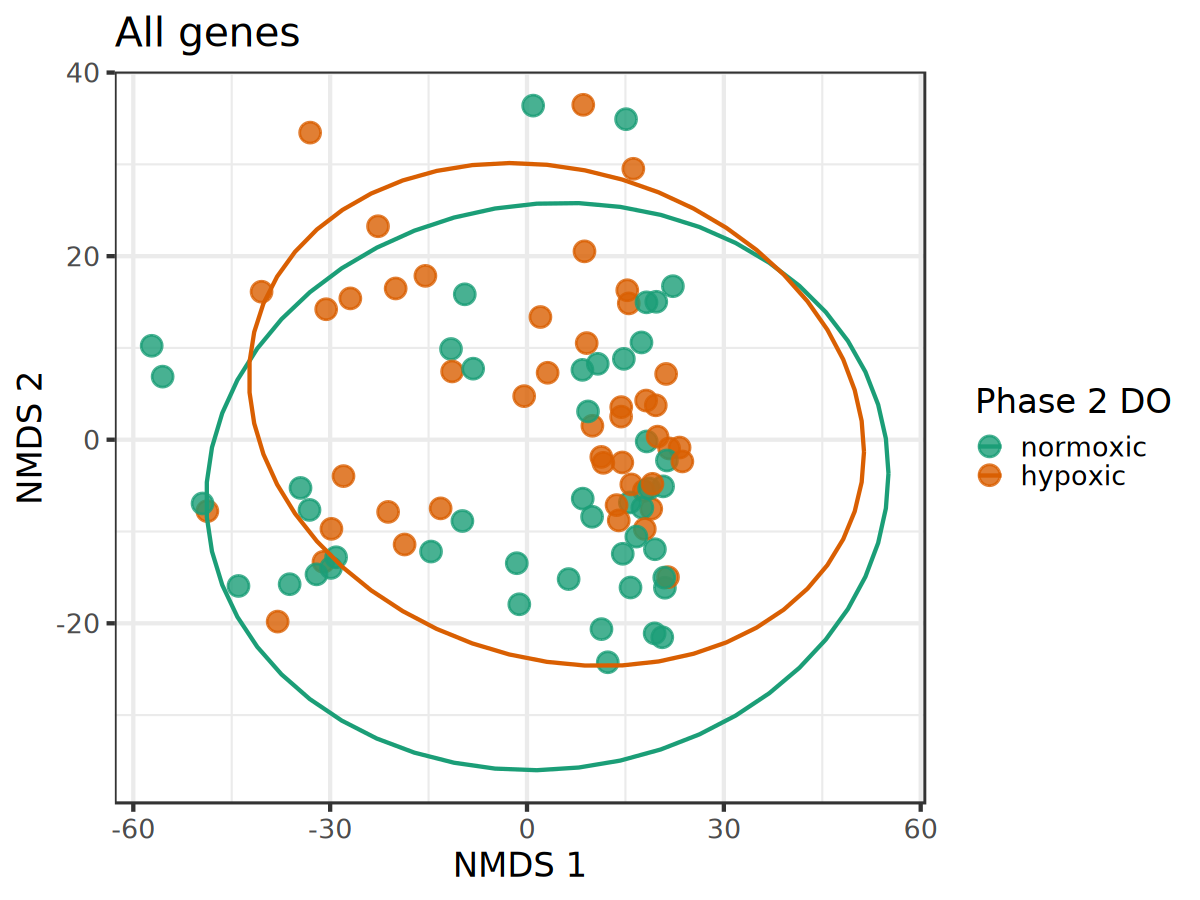

In [57]:
options(repr.plot.width = 10, repr.plot.height = 7.5)

nmds.plot2 <- ggplot(mds, aes(X1, X2, col = Phase2_DO)) +
geom_point(
    size = 5,
    alpha = 0.8
  ) +
scale_shape_manual(values = c(19, 17)) +
scale_color_brewer(palette = 'Dark2') +
 stat_ellipse() + 
theme_bw(base_size = 20) +
labs(x = 'NMDS 1', 
     y = 'NMDS 2',
    col = 'Phase 2 DO',
    title = 'All genes')

nmds.plot2

#### just p1 temp

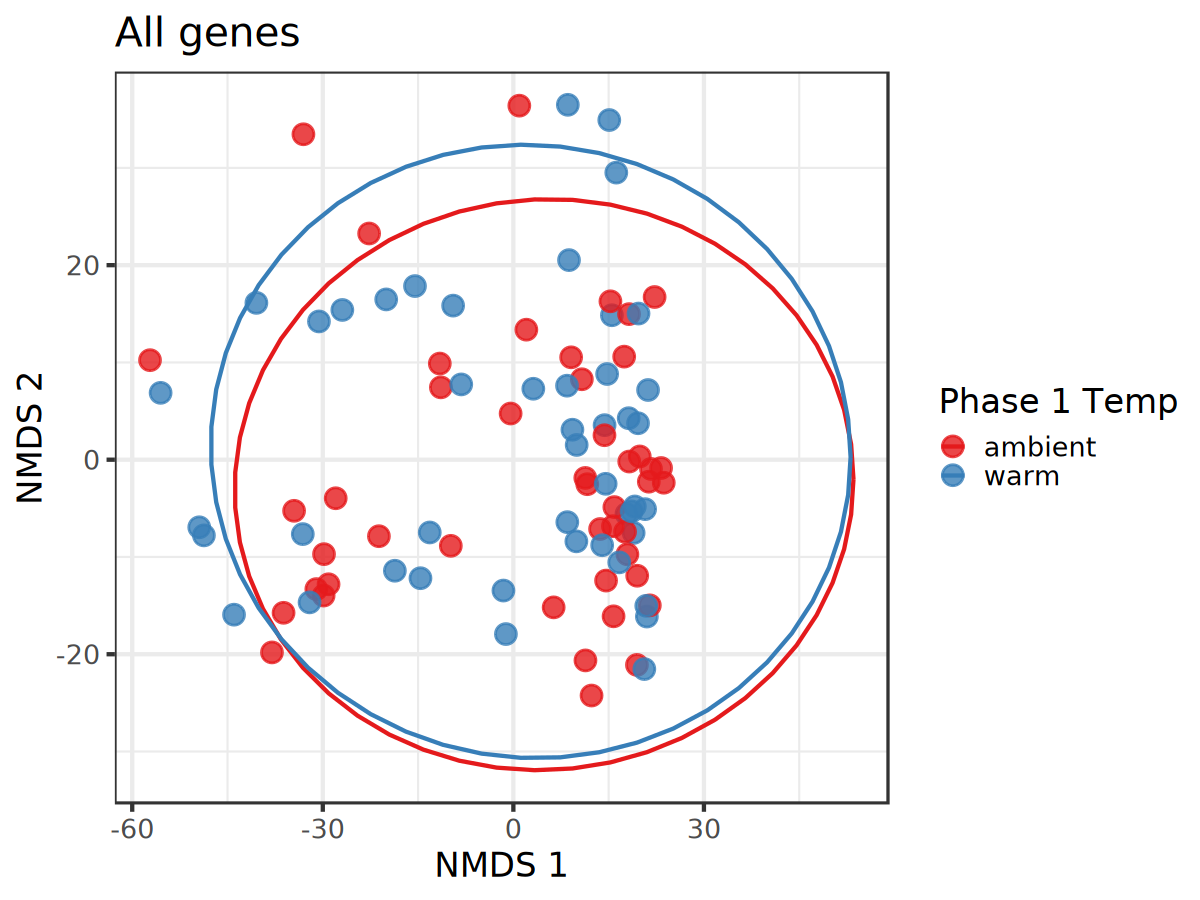

In [58]:
options(repr.plot.width = 10, repr.plot.height = 7.5)

nmds.plot2 <- ggplot(mds, aes(X1, X2, col = Phase1_temp)) +
geom_point(
    size = 5,
    alpha = 0.8
  ) +
scale_shape_manual(values = c(19, 17)) +
scale_color_brewer(palette = 'Set1') +
 stat_ellipse() + 
theme_bw(base_size = 20) +
labs(x = 'NMDS 1', 
     y = 'NMDS 2',
    col = 'Phase 1 Temp',
    title = 'All genes')

nmds.plot2

#### just p1 DO

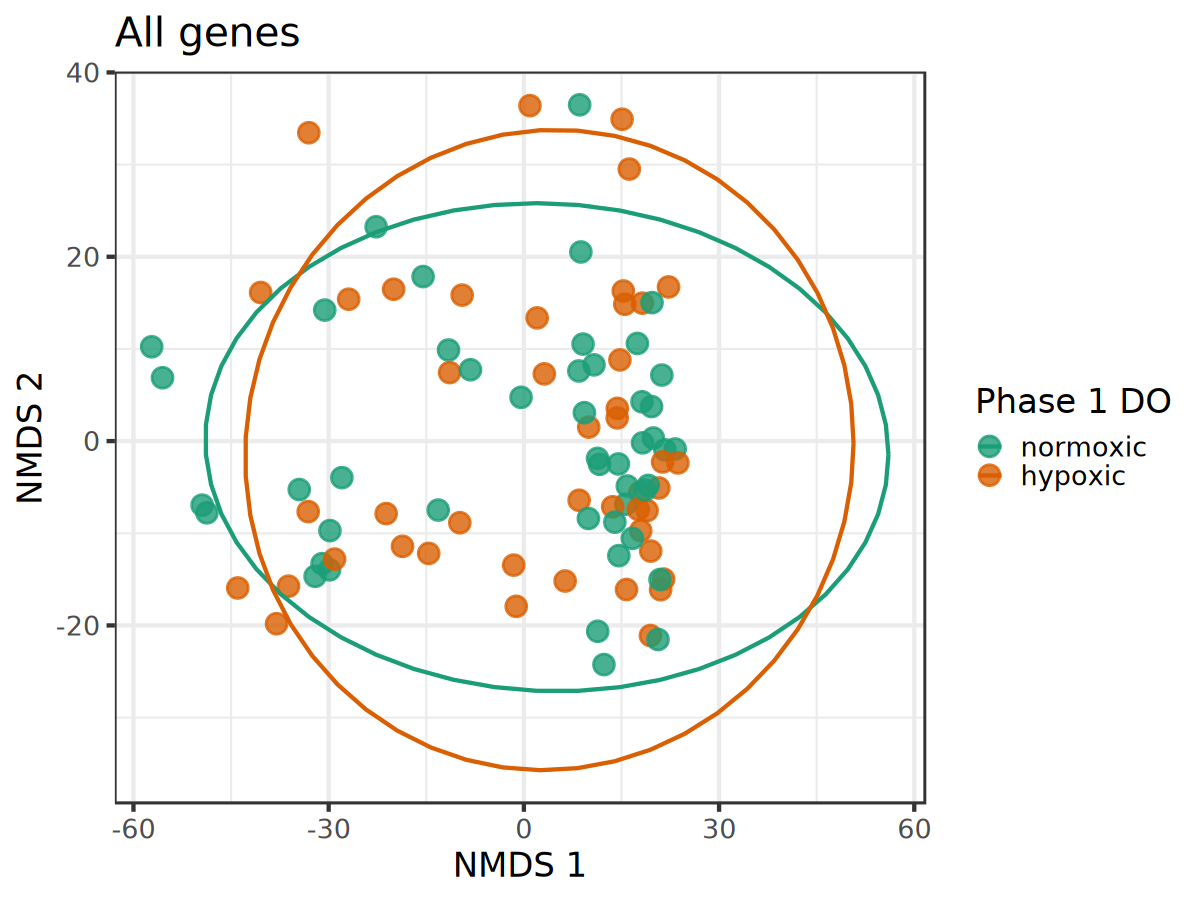

In [59]:
options(repr.plot.width = 10, repr.plot.height = 7.5)

nmds.plot2 <- ggplot(mds, aes(X1, X2, col = Phase1_DO)) +
geom_point(
    size = 5,
    alpha = 0.8
  ) +
scale_shape_manual(values = c(19, 17)) +
scale_color_brewer(palette = 'Dark2') +
 stat_ellipse() + 
theme_bw(base_size = 20) +
labs(x = 'NMDS 1', 
     y = 'NMDS 2',
    col = 'Phase 1 DO',
    title = 'All genes')

nmds.plot2

### heatmap 
of sample-to-sample distances using the variance stabilizing transformed values


following [RNA-seq workflow](https://master.bioconductor.org/packages/release/workflows/vignettes/rnaseqGene/inst/doc/rnaseqGene.html) from Mike Love

In [ ]:
# normalization & transformation
vsd <- vst(dds_rm, blind = FALSE)

# calculate sample distances
sample_dists <- dist(t(assay(vsd)))
head(sample_dists)

In [ ]:
head(vsd)

In [ ]:
options(repr.plot.width=20, repr.plot.height=20)

sampleDistMatrix <- as.matrix(sample_dists)
rownames(sampleDistMatrix) <- paste(colnames(vsd))
colnames(sampleDistMatrix) <- NULL
colors <- colorRampPalette( rev(brewer.pal(9, "Blues")) )(255)
pheatmap(sampleDistMatrix,
         clustering_distance_rows = sample_dists,
         clustering_distance_cols = sample_dists,
         col = colors)

In [ ]:
resultsNames(dds_rm)

### MA plot
of one example comparison between HC and CC

In [ ]:
# Unshrunken results for your contrast/interaction term
res <- results(dds_rm, contrast = c("complete_trtmt", "hypoxic.control", "control.control"))
# or for an interaction/complex contrast:
# res <- results(dds, name = "phase1stressorA.phase2stressorB")

# Shrunken with ashr — works with contrast= or name= directly, no coef restriction
res_shrunk <- lfcShrink(dds_rm, contrast = c("complete_trtmt", "hypoxic.control", "control.control"), type = "ashr")
# or: res_shrunk <- lfcShrink(dds, res = res, type = "ashr")

In [ ]:
options(repr.plot.height = 10, repr.plot.width = 15)
par(mfrow = c(1, 2))
DESeq2::plotMA(res, ylim = c(-5, 5), main = "Unshrunken (MLE)")
DESeq2::plotMA(res_shrunk, ylim = c(-5, 5), main = "Shrunken (ashr)")

shrinking collapes the grey cloud to LFC = 0, so that genes with large LFC and low mean counts aren't showing up as DEGs (likely due to noise)

this shouldn't change the number of DEGs really - checking below:

In [ ]:
sum(res$padj < 0.05, na.rm = TRUE)
sum(res_shrunk$padj < 0.05, na.rm = TRUE)  # should be ~identical to above

# now check with your actual FC cutoff
sum(res_shrunk$padj < 0.05 & abs(res_shrunk$log2FoldChange) > 1, na.rm = TRUE)
sum(res$padj < 0.05 & abs(res$log2FoldChange) > 1, na.rm = TRUE)  # unshrunken FC filter, for comparison

## 3. Pairwise comparisons

### 1. Effect of single exposure on GE after a period of recovery
- CC vs. WC
- CC vs. HC
- CC vs. BC

**CC vs. WC**

In [208]:
options(repr.plot.width = 5, repr.plot.height = 10)

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 170, 0.65%
LFC < 0 (down)     : 45, 0.17%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1949.4353,5.263514e-05,0.006479416,0.7621780,0.9993550,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2097.0613,2.007077e-02,0.284265323,0.0388126,0.6621438,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,132.0849,-2.639033e-04,0.051065318,0.8548965,0.9993550,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,866.8099,-5.714255e-05,0.006495785,0.7425560,0.9993550,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12195.3765,1.455013e-04,0.006259427,0.5049455,0.9910647,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.8729,3.818718e-04,0.017404082,0.1993023,0.9155633,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


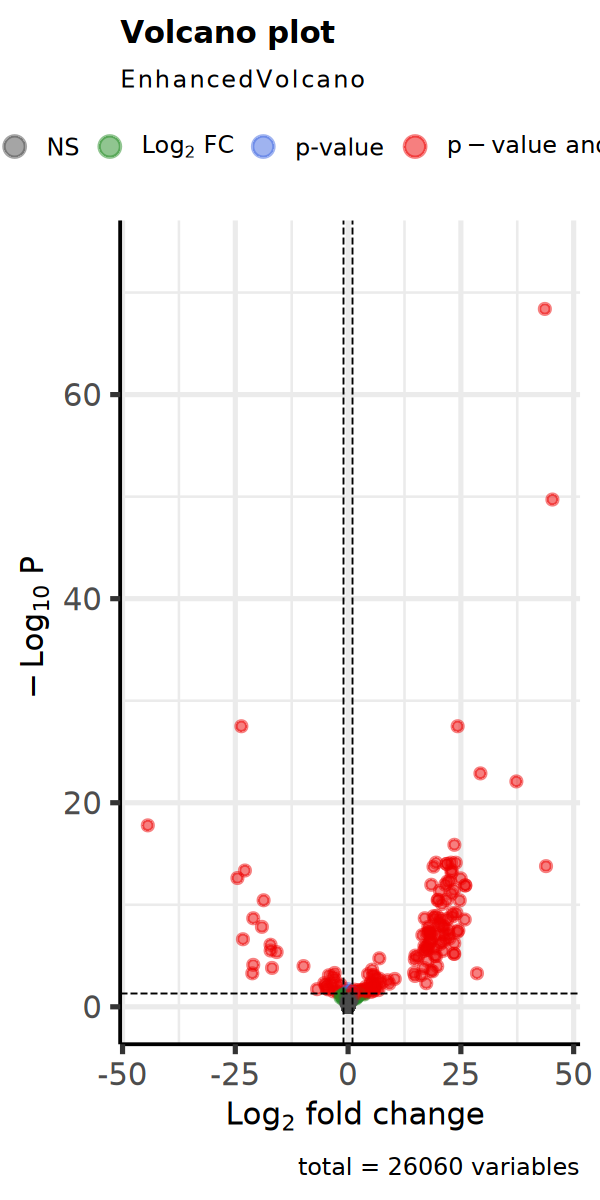

In [209]:
res.wc.cc <- lfcShrink(dds_rm, 
                       contrast= c('complete_trtmt', 'warm.control', 'control.control'), # CC is the "control"
                     type = 'ashr')

summary(res.wc.cc)

EnhancedVolcano(res.wc.cc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.wc.cc <- merge(res.wc.cc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.wc.cc)[1] <- 'Gene'

head(res.wc.cc)

In [210]:
write.csv(res.wc.cc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/wc_cc.csv', row.names = FALSE)

**CC vs. HC**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 129, 0.5%
LFC < 0 (down)     : 55, 0.21%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1949.4353,-1.252077e-04,0.006759149,0.4828558,0.9997977,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2097.0613,3.486384e-03,0.107785028,0.1656265,0.9997977,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,132.0849,-1.978631e-04,0.046113469,0.8671729,0.9997977,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,866.8099,2.580752e-05,0.006421184,0.8810783,0.9997977,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12195.3765,1.035562e-04,0.006212481,0.6374844,0.9997977,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.8729,6.318219e-05,0.009006003,0.7005645,0.9997977,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


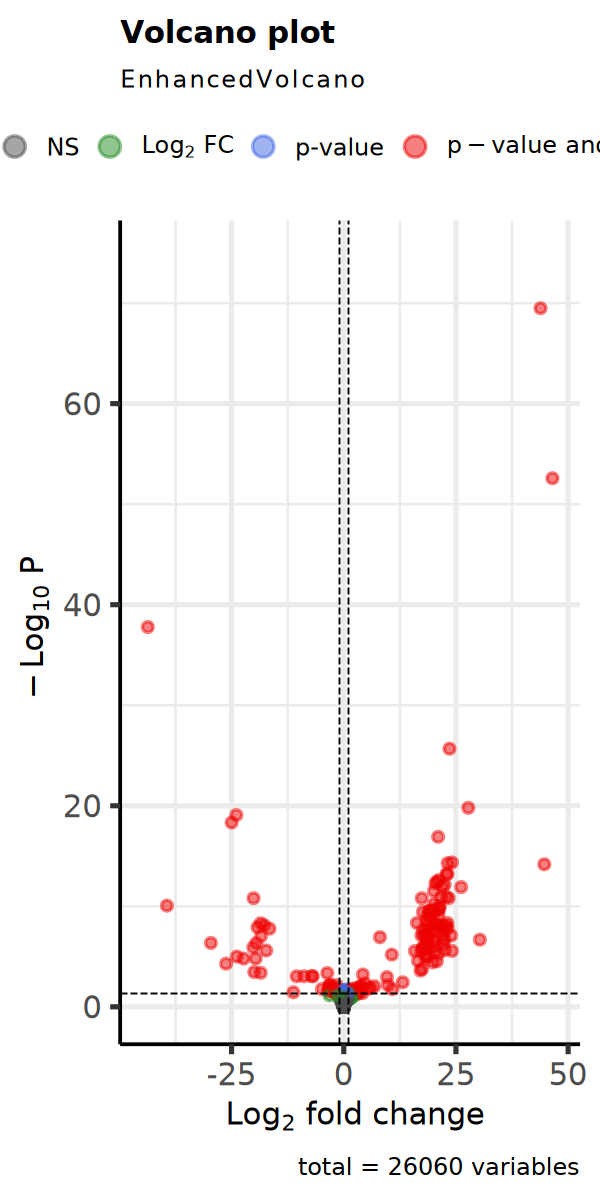

In [211]:
res.hc.cc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'hypoxic.control', 'control.control'), # CC is the "control"
                     type = 'ashr')

summary(res.hc.cc)

EnhancedVolcano(res.hc.cc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.hc.cc <- merge(res.hc.cc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.hc.cc)[1] <- 'Gene'

head(res.hc.cc)

In [212]:
write.csv(res.hc.cc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/hc_cc.csv', row.names = FALSE)

**CC vs. BC**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 310, 1.2%
LFC < 0 (down)     : 155, 0.59%
outliers [1]       : 79, 0.3%
low counts [2]     : 1011, 3.9%
(mean count < 4)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1949.4353,-1.347907e-04,0.007804748,0.526721470,0.9800919,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2097.0613,3.042329e-01,1.209814454,0.005428612,0.1942012,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,132.0849,-3.722537e-02,0.400673618,0.054787252,0.6142962,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,866.8099,1.038693e-05,0.007031827,0.958258775,0.9984961,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12195.3765,1.307305e-04,0.006558402,0.558302566,0.9835943,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.8729,7.118697e-05,0.012576477,0.822862379,0.9981033,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


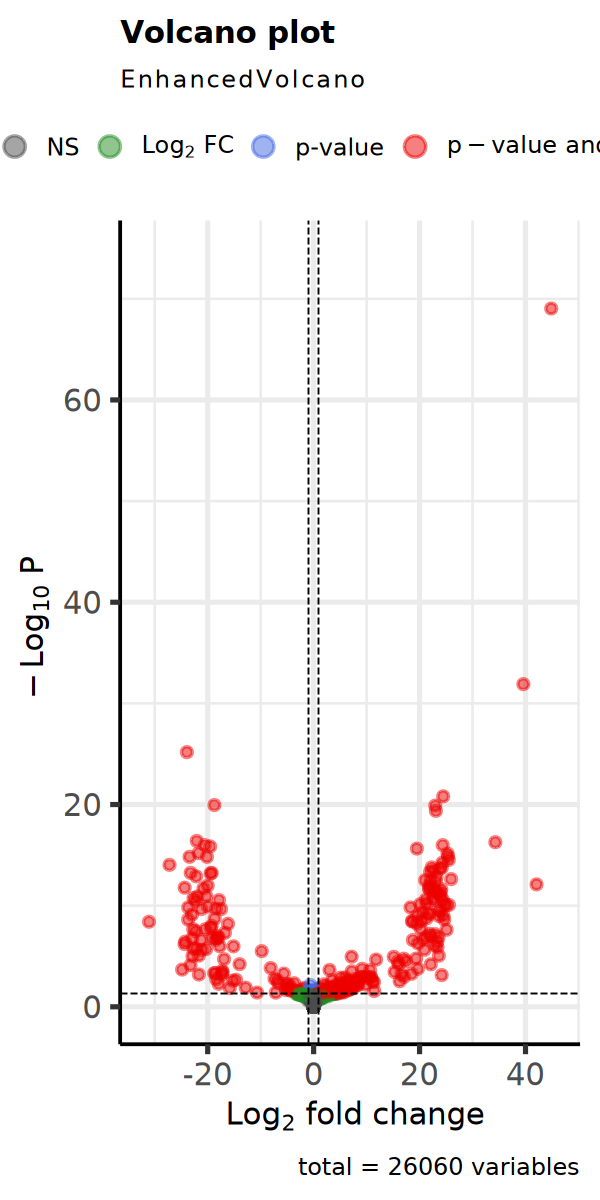

In [213]:
res.bc.cc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'both.control', 'control.control'), # CC is the "control"
                     type = 'ashr')

summary(res.bc.cc)

EnhancedVolcano(res.bc.cc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.bc.cc <- merge(res.bc.cc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.bc.cc)[1] <- 'Gene'

head(res.bc.cc)

In [214]:
write.csv(res.bc.cc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/bc_cc.csv', row.names = FALSE)

### 2. Effect of single exposure experienced only later in life
- CC vs. CW
- CC vs. CH
- CC vs. CB

**CC vs. CW**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 670, 2.6%
LFC < 0 (down)     : 121, 0.46%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1949.4353,0.04013752,0.1069693,0.397716697,0.84446431,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2097.0613,2.22676374,2.5627737,0.001057433,0.05376351,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,132.0849,-0.01837661,0.2367145,0.443738885,0.87108273,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,866.8099,-0.01893659,0.1062007,0.688027953,0.95135602,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12195.3765,-0.01495351,0.0970663,0.782872597,0.97180186,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.8729,0.01582504,0.1182082,0.599730109,0.92798444,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


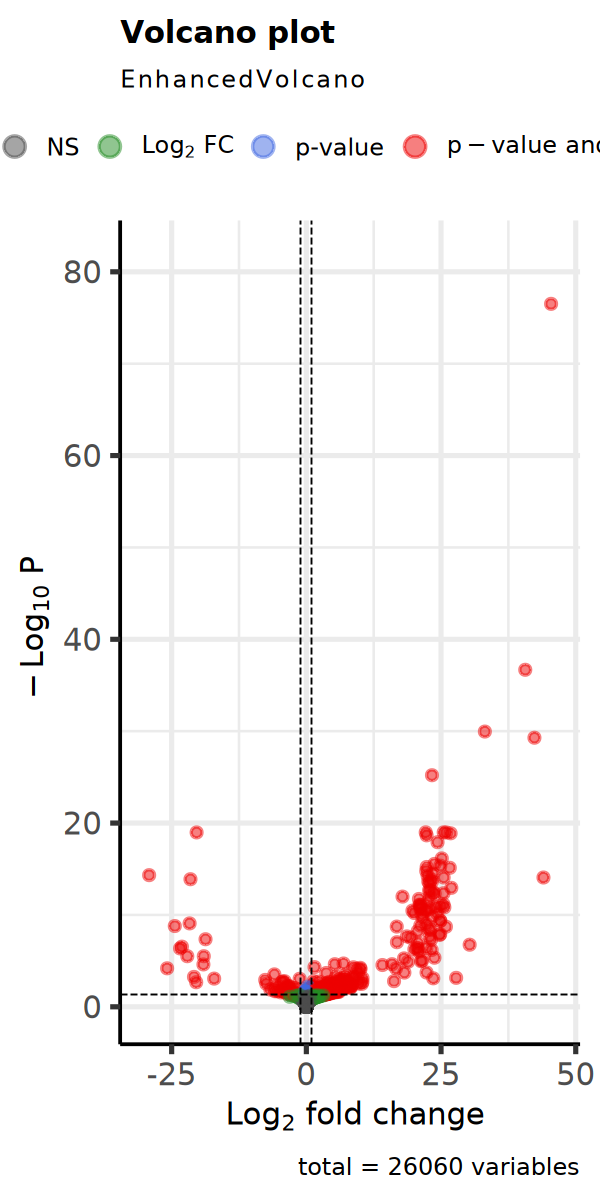

In [215]:
res.cw.cc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'control.warm', 'control.control'), # CC is the "control"
                     type = 'ashr')

summary(res.cw.cc)

EnhancedVolcano(res.cw.cc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cw.cc <- merge(res.cw.cc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cw.cc)[1] <- 'Gene'

head(res.cw.cc)

In [216]:
write.csv(res.cw.cc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/cw_cc.csv', row.names = FALSE)

**CC vs. CH**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 217, 0.83%
LFC < 0 (down)     : 102, 0.39%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1949.4353,-0.04075623,0.10066656,0.33031257,0.8239895,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2097.0613,0.03106497,0.26391475,0.07693410,0.5689795,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,132.0849,-0.02758665,0.26038711,0.09615184,0.6017707,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,866.8099,-0.02888310,0.10006217,0.48799377,0.8915301,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12195.3765,-0.07666562,0.09495092,0.12296485,0.6466232,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.8729,0.01045492,0.10863668,0.68375075,0.9508149,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


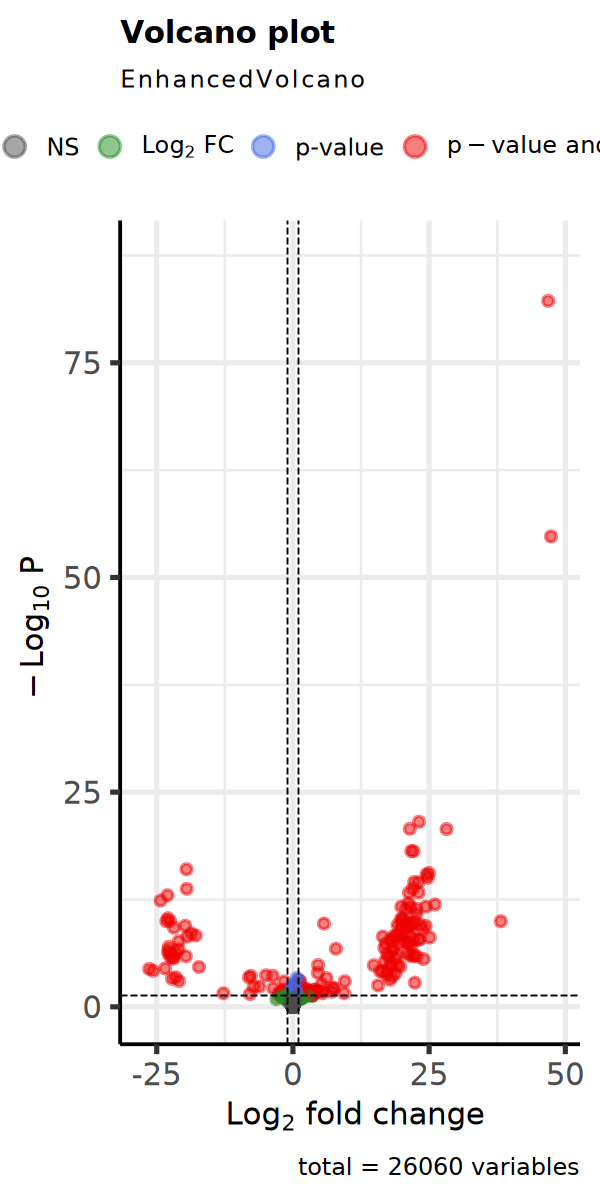

In [217]:
res.ch.cc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'control.hypoxic', 'control.control'), # CC is the "control"
                     type = 'ashr')

summary(res.ch.cc)

EnhancedVolcano(res.ch.cc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.ch.cc <- merge(res.ch.cc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.ch.cc)[1] <- 'Gene'

head(res.ch.cc)

In [218]:
write.csv(res.ch.cc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/ch_cc.csv', row.names = FALSE)

**CC vs. CB**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 437, 1.7%
LFC < 0 (down)     : 138, 0.53%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1949.4353,0.006536631,0.1261864,0.92212269,0.9884476,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2097.0613,0.111197104,0.5331903,0.02002371,0.2843286,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,132.0849,0.017410833,0.2059179,0.42602966,0.8505213,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,866.8099,0.001871410,0.1262128,0.97765540,0.9975742,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12195.3765,0.111385180,0.1232053,0.13622536,0.6002366,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.8729,0.025333642,0.1552162,0.62456120,0.9209521,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


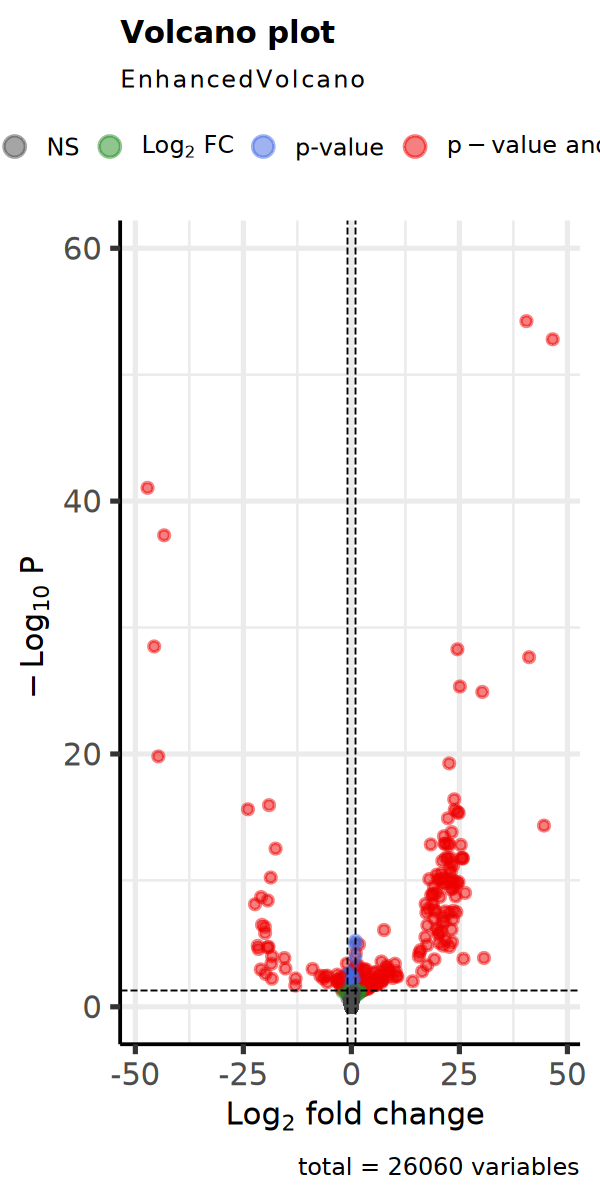

In [219]:
res.cb.cc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'control.both', 'control.control'), # CC is the "control"
                     type = 'ashr')

summary(res.cb.cc)

EnhancedVolcano(res.cb.cc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cb.cc <- merge(res.cb.cc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cb.cc)[1] <- 'Gene'

head(res.cb.cc)

In [220]:
write.csv(res.cb.cc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/cb_cc.csv', row.names = FALSE)

### 3. Timing of Stress Exposure
How does GE change depending on when stress is experienced (when all oysters only experience stress once)?
- CH vs. HC
- CW vs. WC
- CB vs. BC

**CH vs. HC**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 77, 0.3%
LFC < 0 (down)     : 67, 0.26%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1949.4353,-0.0038217383,0.05520097,0.77570773,0.9901066,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2097.0613,0.0015186033,0.07826684,0.68833177,0.9888299,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,132.0849,-0.0109919027,0.17180139,0.11656667,0.7829513,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,866.8099,-0.0118800631,0.05551043,0.37674168,0.9402360,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12195.3765,-0.0377351031,0.05649831,0.03470123,0.5966728,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.8729,0.0001777859,0.05712227,0.98101320,1.0000000,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


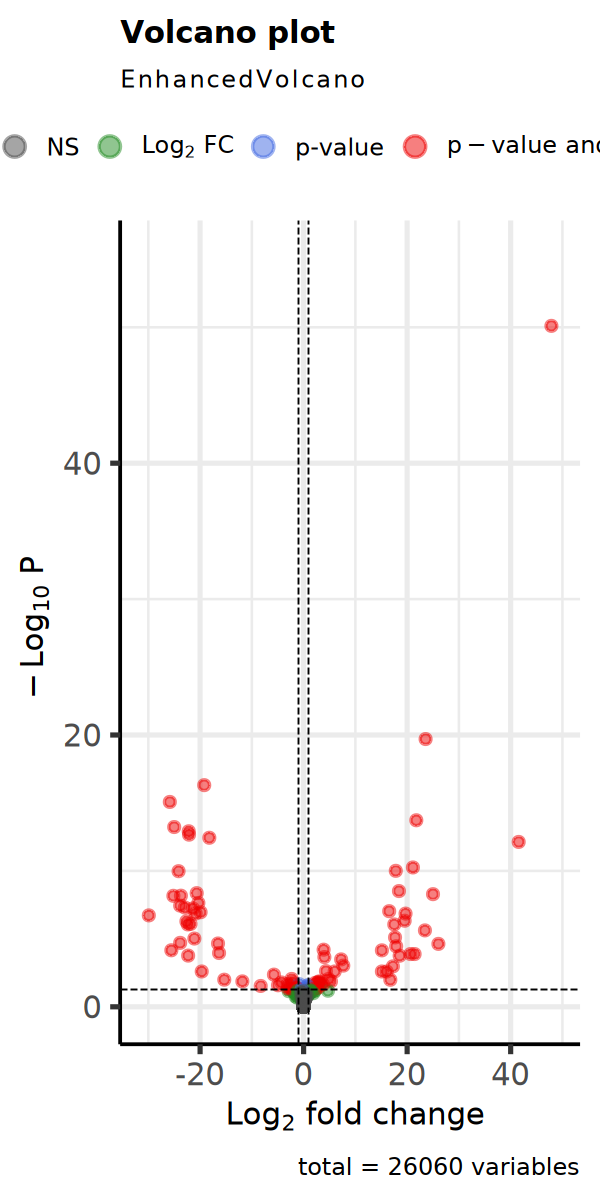

In [221]:
res.ch.hc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'control.hypoxic', 'hypoxic.control'), # HC is the "control"
                     type = 'ashr')

summary(res.ch.hc)

EnhancedVolcano(res.ch.hc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.ch.hc <- merge(res.ch.hc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.ch.hc)[1] <- 'Gene'

head(res.ch.hc)

In [222]:
write.csv(res.ch.hc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/ch_hc.csv', row.names = FALSE)

**CW vs. WC**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 158, 0.61%
LFC < 0 (down)     : 135, 0.52%
outliers [1]       : 79, 0.3%
low counts [2]     : 506, 1.9%
(mean count < 3)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1949.4353,0.051072671,0.1426527,0.5690362,0.8713366,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2097.0613,0.032654081,0.2173761,0.2047771,0.6386391,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,132.0849,-0.013859183,0.1980226,0.5409203,0.8577619,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,866.8099,-0.006866949,0.1428074,0.9389260,0.9871909,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12195.3765,-0.090136750,0.1228125,0.3230504,0.7378920,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.8729,-0.052274474,0.1695785,0.4265558,0.8013003,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


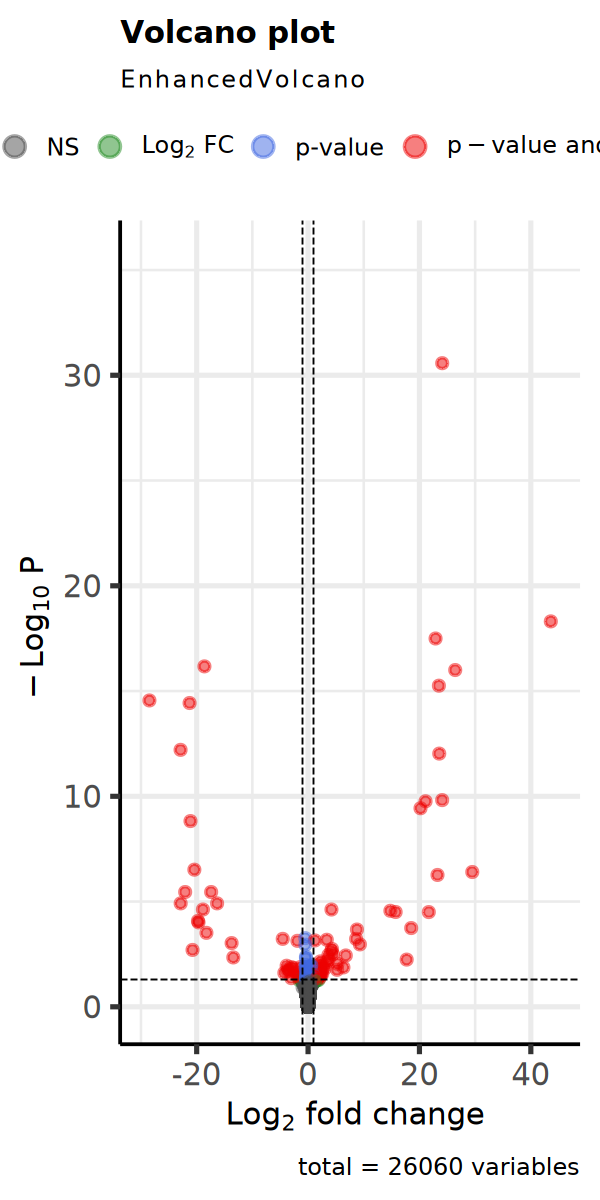

In [223]:
res.cw.wc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'control.warm', 'warm.control'), # WC is the "control"
                     type = 'ashr')

summary(res.cw.wc)

EnhancedVolcano(res.cw.wc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cw.wc <- merge(res.cw.wc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cw.wc)[1] <- 'Gene'

head(res.cw.wc)

In [224]:
write.csv(res.cw.wc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/cw_wc.csv', row.names = FALSE)

**CB vs. BC**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 322, 1.2%
LFC < 0 (down)     : 157, 0.6%
outliers [1]       : 79, 0.3%
low counts [2]     : 506, 1.9%
(mean count < 3)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1949.4353,0.048874800,0.1275387,0.448011282,0.8746440,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2097.0613,-0.012536874,0.1897280,0.563085869,0.9179377,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,132.0849,0.233395215,0.9541083,0.005163739,0.1669397,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,866.8099,-0.001664765,0.1220831,0.978749639,0.9965885,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12195.3765,0.058378124,0.1108150,0.379620842,0.8417124,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.8729,0.012830220,0.1521291,0.798277452,0.9670909,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


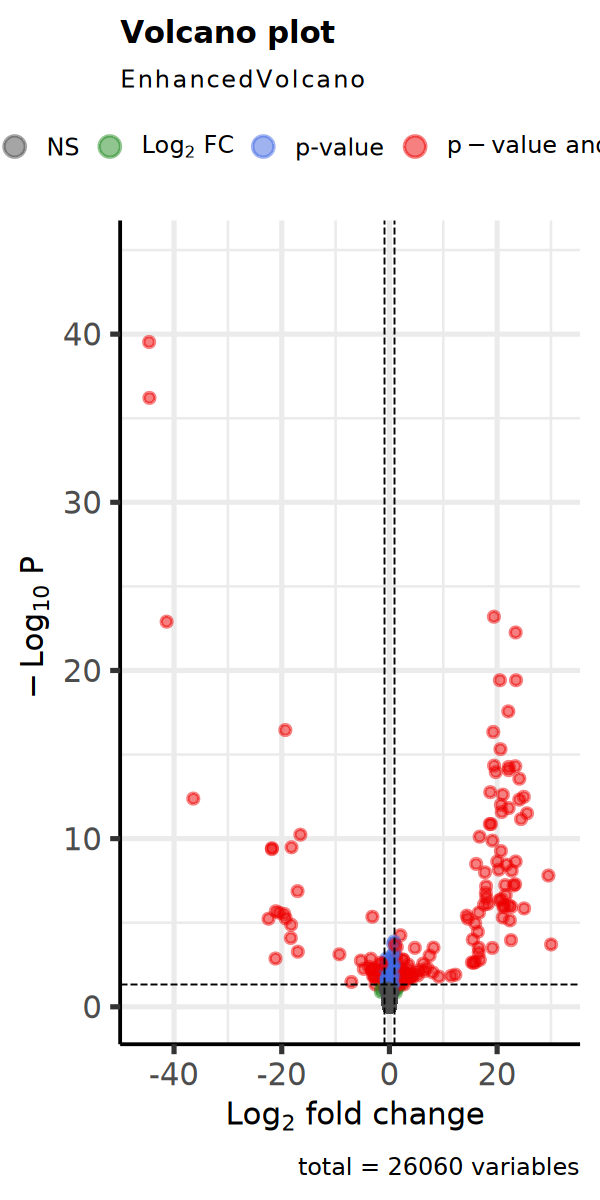

In [225]:
res.cb.bc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'control.both', 'both.control'), # BC is the "control"
                     type = 'ashr')

summary(res.cb.bc)

EnhancedVolcano(res.cb.bc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cb.bc <- merge(res.cb.bc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cb.bc)[1] <- 'Gene'

head(res.cb.bc)

In [226]:
write.csv(res.cb.bc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/cb_bc.csv', row.names = FALSE)

### 4. No stress vs. most stress
- CC vs. WW
- CC vs. HH
- CC vs. BB

**CC vs. WW**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 447, 1.7%
LFC < 0 (down)     : 82, 0.31%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1949.4353,0.015823536,0.07006766,0.439270327,0.9229082,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2097.0613,0.931150843,1.92899119,0.002539826,0.1148813,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,132.0849,-0.002866569,0.13776688,0.781766644,0.9823538,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,866.8099,-0.025258743,0.07105243,0.219521891,0.8095835,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12195.3765,-0.011913309,0.06690657,0.643699509,0.9719826,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.8729,0.011248997,0.07680185,0.354740811,0.8937666,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


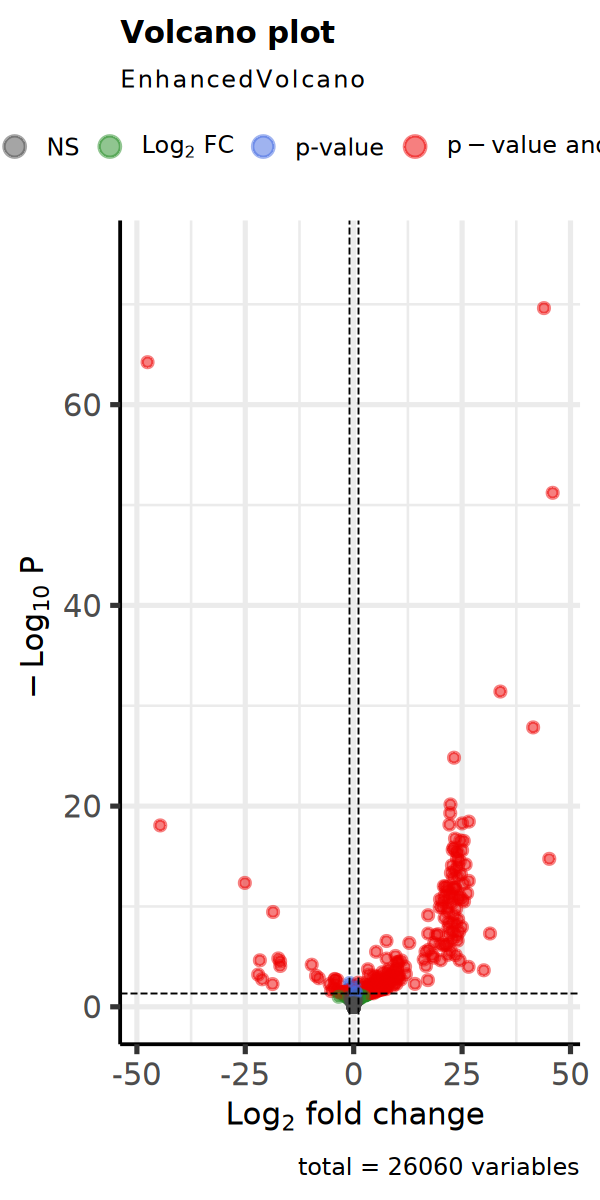

In [227]:
res.cc.ww <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'warm.warm', 'control.control'), # CC is the "control"
                     type = 'ashr')

summary(res.cc.ww)

EnhancedVolcano(res.cc.ww,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cc.ww <- merge(res.cc.ww, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cc.ww)[1] <- 'Gene'

head(res.cc.ww)

In [228]:
write.csv(res.cc.ww, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/ww_cc.csv', row.names = FALSE)

**CC vs. HH**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 168, 0.64%
LFC < 0 (down)     : 105, 0.4%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1949.4353,-0.0113704496,0.07137721,0.57568066,0.9694209,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2097.0613,0.0146288384,0.19819384,0.09907047,0.7220055,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,132.0849,-0.0000318036,0.09386252,0.99473641,1.0000000,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,866.8099,0.0032244154,0.07094887,0.87323172,0.9939193,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12195.3765,0.0070046548,0.06750396,0.77993944,0.9857824,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.8729,0.0071690313,0.07503128,0.53945027,0.9601601,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


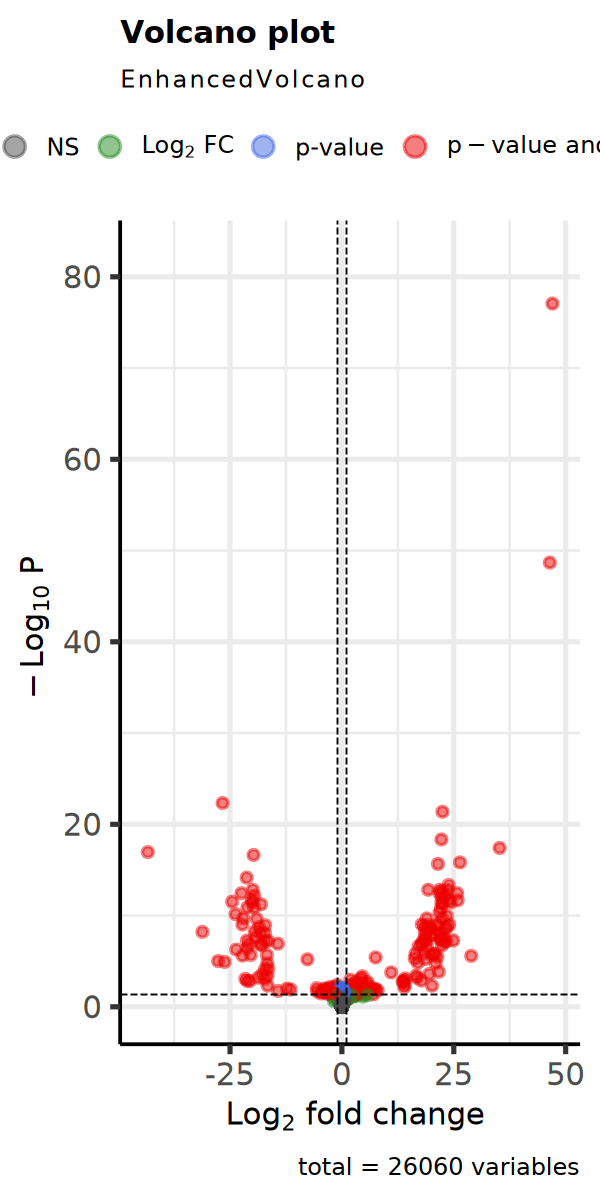

In [229]:
res.cc.hh <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'hypoxic.hypoxic', 'control.control'), # CC is the "control"
                     type = 'ashr')

summary(res.cc.hh)

EnhancedVolcano(res.cc.hh,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cc.hh <- merge(res.cc.hh, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cc.hh)[1] <- 'Gene'

head(res.cc.hh)

In [230]:
write.csv(res.cc.hh, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/hh_cc.csv', row.names = FALSE)

**CC vs. BB**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 125, 0.48%
LFC < 0 (down)     : 562, 2.2%
outliers [1]       : 79, 0.3%
low counts [2]     : 1011, 3.9%
(mean count < 4)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1949.4353,-0.0108461397,0.1181687,0.853183094,0.9724506,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2097.0613,-0.5742275313,1.4169120,0.005417241,0.1414943,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,132.0849,-0.0126684632,0.2188418,0.611221381,0.9005917,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,866.8099,0.0074761380,0.1181747,0.898386832,0.9815658,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12195.3765,-0.0149763325,0.1055757,0.815501885,0.9615752,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.8729,-0.0006587228,0.1373625,0.987225525,0.9965243,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


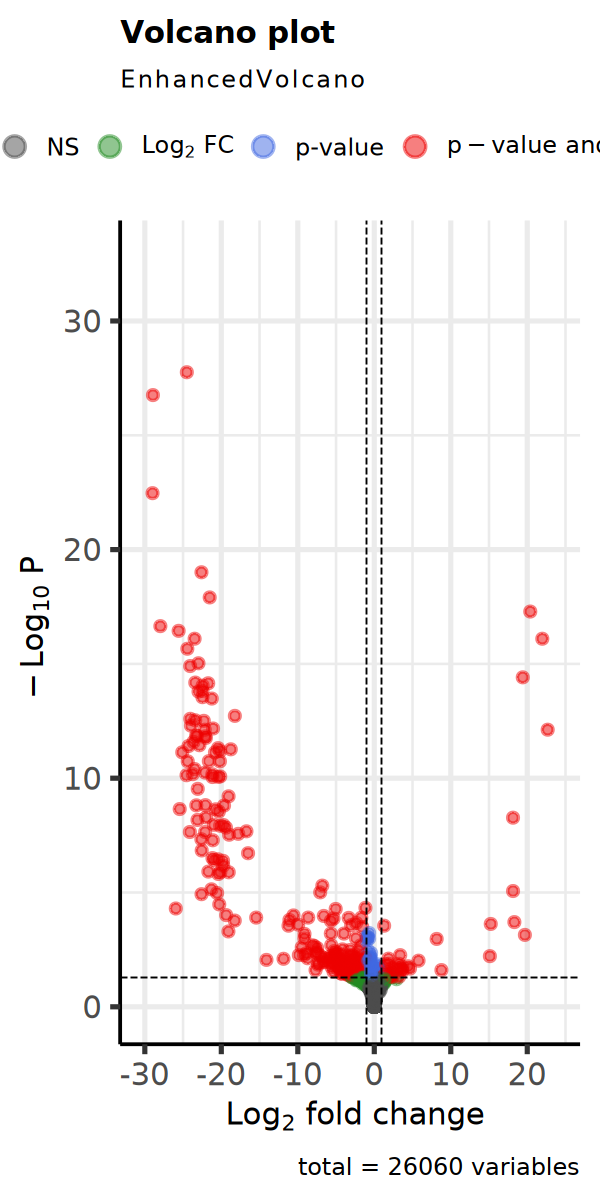

In [231]:
res.cc.bb <- lfcShrink(dds_rm, coef='complete_trtmt_control.control_vs_both.both', # BB is the "control"
                     type = 'ashr')

summary(res.cc.bb)

EnhancedVolcano(res.cc.bb,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cc.bb <- merge(res.cc.bb, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cc.bb)[1] <- 'Gene'

head(res.cc.bb)

switch LFC direction so CC is the baseline (deseq recognizes as bb as the baseline rn)

In [232]:
cc.bb.df <- as.data.frame(res.cc.bb) %>% # create df
mutate(log2FoldChange = log2FoldChange * -1) # multiple by -1 to make pos to neg and vice versa 

# validate
head(res.cc.bb)
head(cc.bb.df)

,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1949.4353,-0.0108461397,0.1181687,0.853183094,0.9724506,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2097.0613,-0.5742275313,1.4169120,0.005417241,0.1414943,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,132.0849,-0.0126684632,0.2188418,0.611221381,0.9005917,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,866.8099,0.0074761380,0.1181747,0.898386832,0.9815658,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12195.3765,-0.0149763325,0.1055757,0.815501885,0.9615752,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.8729,-0.0006587228,0.1373625,0.987225525,0.9965243,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1949.4353,0.0108461397,0.1181687,0.853183094,0.9724506,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2097.0613,0.5742275313,1.4169120,0.005417241,0.1414943,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,132.0849,0.0126684632,0.2188418,0.611221381,0.9005917,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,866.8099,-0.0074761380,0.1181747,0.898386832,0.9815658,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12195.3765,0.0149763325,0.1055757,0.815501885,0.9615752,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.8729,0.0006587228,0.1373625,0.987225525,0.9965243,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


In [233]:
write.csv(cc.bb.df, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/bb_cc.csv', row.names = FALSE)

### 5. Effect of initial exposure on response in later exposure
(also gets at the effect of priming to stress)

#### 5A. Matched stressors
Oyster is primed with a stress, and experiences the *same* stressor again
- HH vs. CH
- WW vs. CW
- BB vs. CB

**HH vs. CH**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 92, 0.35%
LFC < 0 (down)     : 186, 0.71%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1949.4353,9.206689e-05,0.007773743,0.69740204,0.9975065,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2097.0613,-1.857086e-04,0.080354065,0.96322223,0.9986647,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,132.0849,2.582345e-02,0.305219025,0.09754631,0.8235392,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,866.8099,2.370917e-04,0.009619311,0.38980634,0.9835722,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12195.3765,8.589979e-04,0.015967071,0.06662258,0.7616922,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.8729,1.072274e-04,0.014831101,0.81537292,0.9975065,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


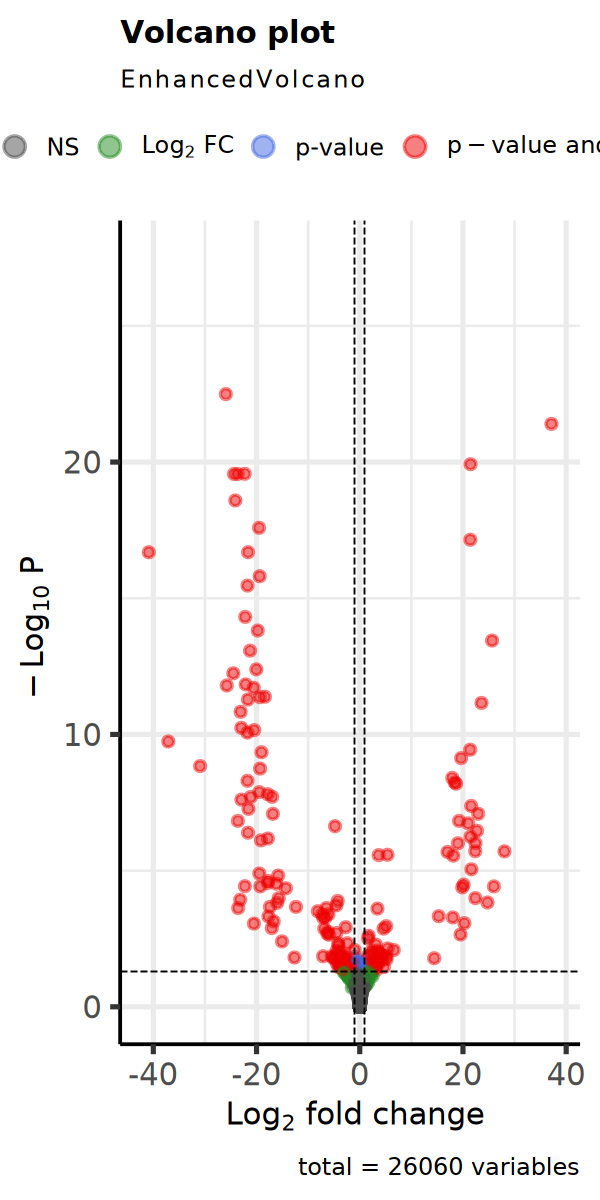

In [234]:
res.hh.ch <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'hypoxic.hypoxic', 'control.hypoxic'), # CH is the "control"
                     type = 'ashr')

summary(res.hh.ch)

EnhancedVolcano(res.hh.ch,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.hh.ch <- merge(res.hh.ch, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.hh.ch)[1] <- 'Gene'

head(res.hh.ch)

In [235]:
write.csv(res.hh.ch, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/hh_ch.csv', row.names = FALSE)

**WW vs. CW**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 35, 0.13%
LFC < 0 (down)     : 29, 0.11%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1949.4353,-1.323572e-05,0.006291869,0.9395135,1,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2097.0613,-1.725200e-04,0.032218931,0.7880494,1,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,132.0849,4.072439e-04,0.040190235,0.6081297,1,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,866.8099,-1.571557e-04,0.006741459,0.3865750,1,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12195.3765,-4.417325e-05,0.006108378,0.8445713,1,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.8729,6.215105e-05,0.008346437,0.6747439,1,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


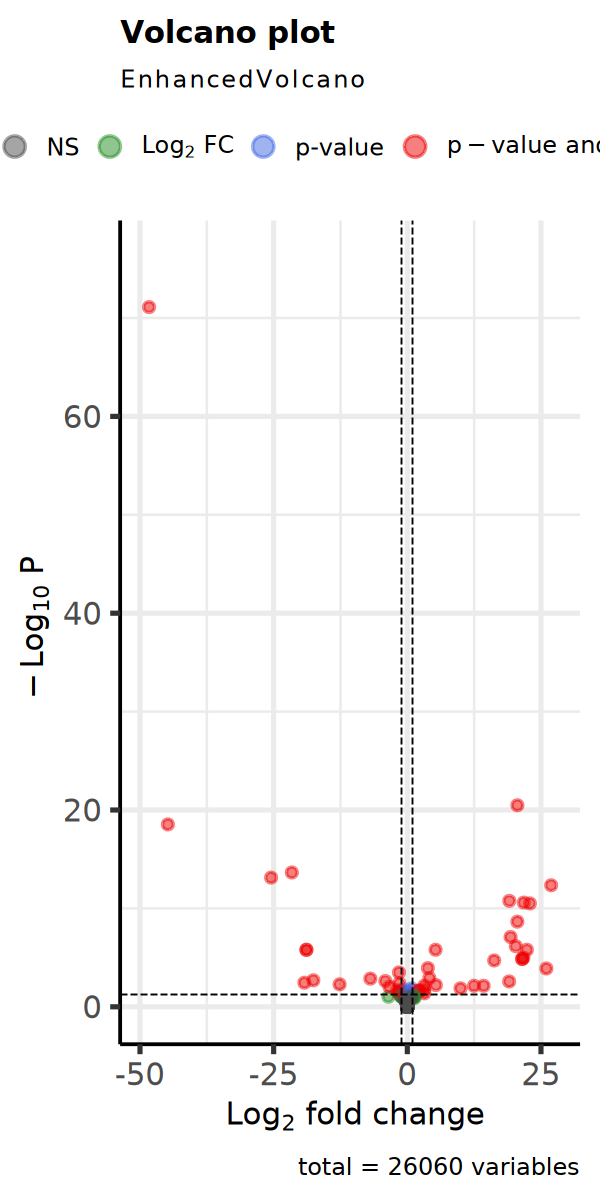

In [236]:
res.ww.cw <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'warm.warm', 'control.warm'), # CW is the "control"
                     type = 'ashr')

summary(res.ww.cw)

EnhancedVolcano(res.ww.cw,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.ww.cw <- merge(res.ww.cw, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.ww.cw)[1] <- 'Gene'

head(res.ww.cw)

In [237]:
write.csv(res.ww.cw, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/ww_cw.csv', row.names = FALSE)

**BB vs. CB**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 37, 0.14%
LFC < 0 (down)     : 76, 0.29%
outliers [1]       : 79, 0.3%
low counts [2]     : 506, 1.9%
(mean count < 3)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1949.4353,-1.364266e-05,0.005821118,0.9270728,0.9991122,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2097.0613,-6.824354e-04,0.051212699,0.6329516,0.9991122,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,132.0849,4.695586e-04,0.052933759,0.7628431,0.9991122,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,866.8099,2.435941e-05,0.005843465,0.8703500,0.9991122,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12195.3765,2.645677e-04,0.006720658,0.1875285,0.9779508,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.8729,9.794821e-05,0.010048442,0.6198223,0.9991122,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


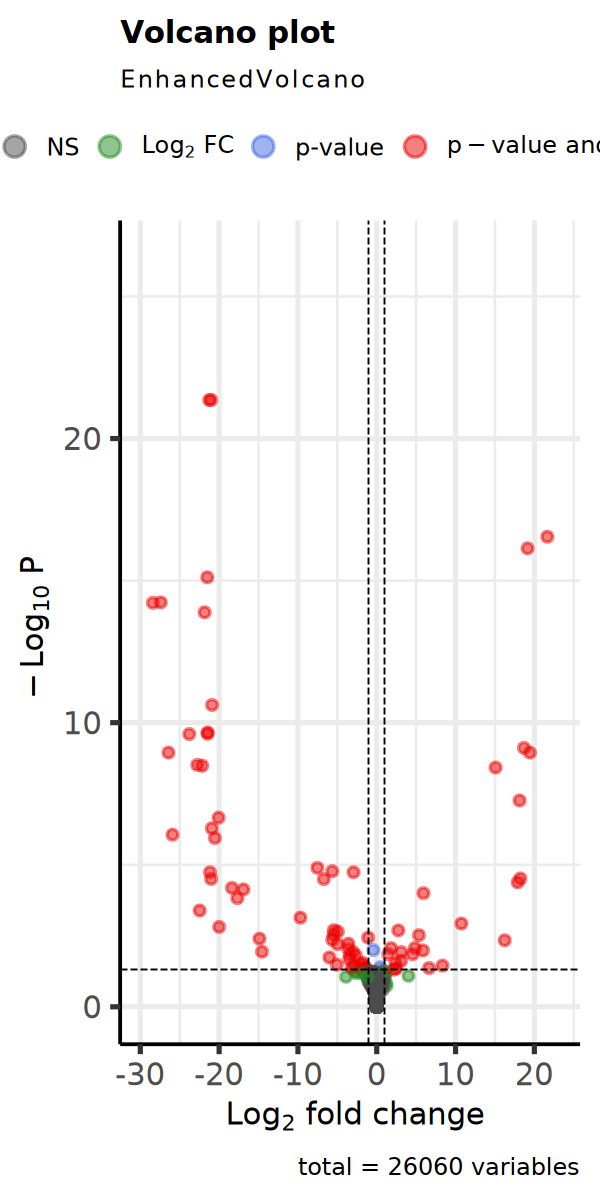

In [238]:
res.cb.bb <- lfcShrink(dds_rm, 
                       coef= 'complete_trtmt_control.both_vs_both.both', # BB is the "control"
                       type = 'ashr')

summary(res.cb.bb)

EnhancedVolcano(res.cb.bb,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cb.bb <- merge(res.cb.bb, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cb.bb)[1] <- 'Gene'

head(res.cb.bb)

In [239]:
write.csv(res.cb.bb, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/cb_bb.csv', row.names = FALSE)

#### 5B. Semi-matched priming: in context of later *single* stress
- CH vs. BH
- CW vs. BW

**CH vs. BH**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 149, 0.57%
LFC < 0 (down)     : 253, 0.97%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1949.4353,0.023901915,0.08136684,0.3696530,0.8394552,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2097.0613,-0.008432876,0.15557890,0.4917508,0.8813334,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,132.0849,0.021680121,0.24275351,0.2126663,0.7407538,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,866.8099,-0.032466372,0.08389264,0.2304843,0.7541741,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12195.3765,0.026258230,0.07540414,0.4097955,0.8543669,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.8729,0.017987472,0.09298877,0.2961129,0.8025401,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


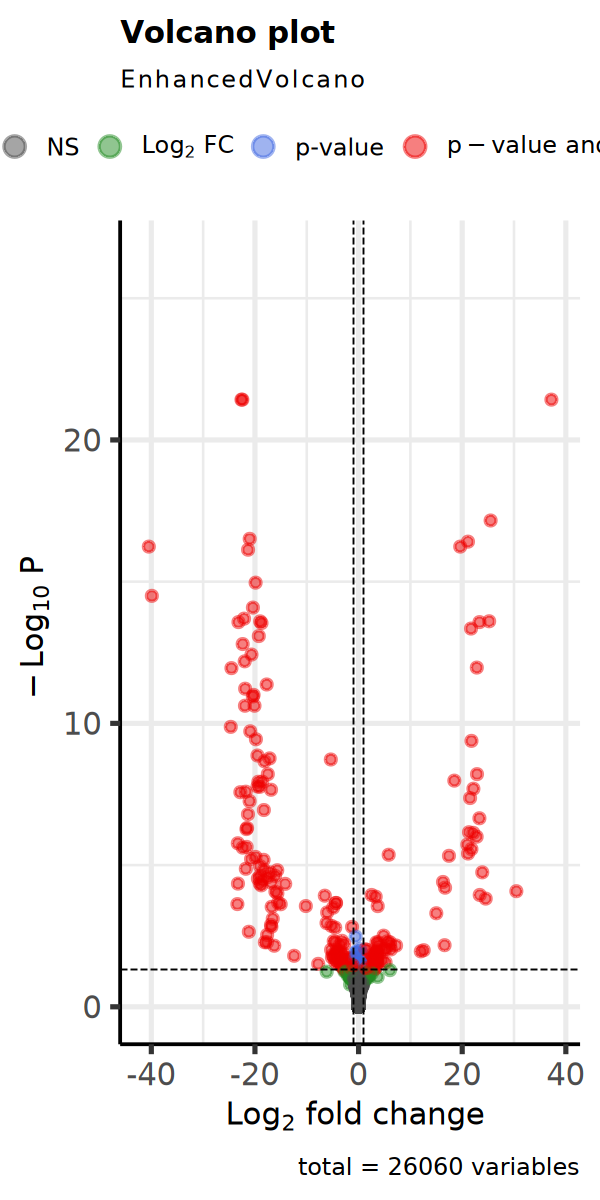

In [240]:
res.bh.ch <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'both.hypoxic', 'control.hypoxic'), # CH is the "control"
                     type = 'ashr')

summary(res.bh.ch)

EnhancedVolcano(res.bh.ch,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.bh.ch <- merge(res.bh.ch, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.bh.ch)[1] <- 'Gene'

head(res.bh.ch)

In [241]:
write.csv(res.bh.ch, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/bh_ch.csv', row.names = FALSE)

**CW vs. BW**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 45, 0.17%
LFC < 0 (down)     : 120, 0.46%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1949.4353,-0.0053745666,0.05580477,0.6950456,0.9794894,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2097.0613,-0.0079014708,0.13351052,0.1818675,0.8187295,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,132.0849,0.0046499972,0.10903945,0.3433073,0.9007543,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,866.8099,-0.0086997608,0.05590683,0.5248991,0.9512947,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12195.3765,-0.0123693491,0.05430153,0.4860552,0.9431775,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.8729,-0.0004004415,0.05775280,0.9581509,0.9983169,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


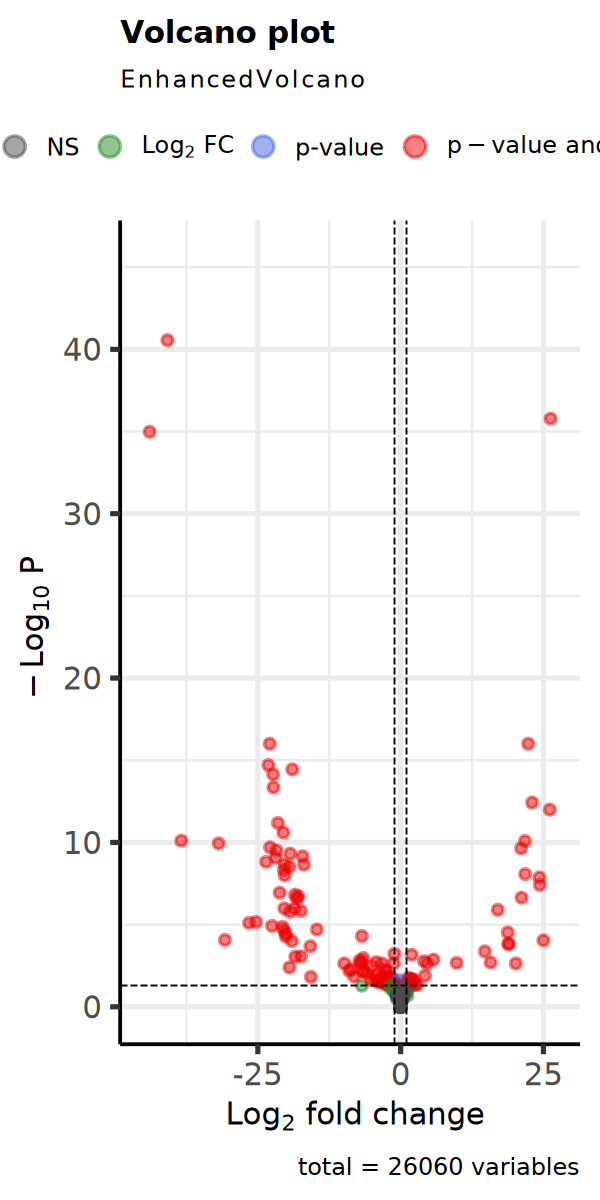

In [242]:
res.bw.cw <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'both.warm', 'control.warm'), # CW is the "control"
                     type = 'ashr')

summary(res.bw.cw)

EnhancedVolcano(res.bw.cw,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.bw.cw <- merge(res.bw.cw, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.bw.cw)[1] <- 'Gene'

head(res.bw.cw)

In [243]:
write.csv(res.bw.cw, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/bw_cw.csv', row.names = FALSE)

#### 5C. Semi-matched priming: in context of later *multiple* stress
- CB vs. WB
- CB vs. HB

**CB vs. WB**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 243, 0.93%
LFC < 0 (down)     : 81, 0.31%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1949.4353,7.928023e-05,0.009850424,0.8497169,0.9922720,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2097.0613,2.547313e-03,0.122038181,0.7811193,0.9872983,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,132.0849,2.768690e-03,0.135635109,0.7907396,0.9884667,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,866.8099,-7.886078e-04,0.017653399,0.2377836,0.8550664,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12195.3765,-3.809808e-04,0.009835152,0.3677349,0.9147951,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.8729,8.995247e-04,0.028412341,0.4755729,0.9484780,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


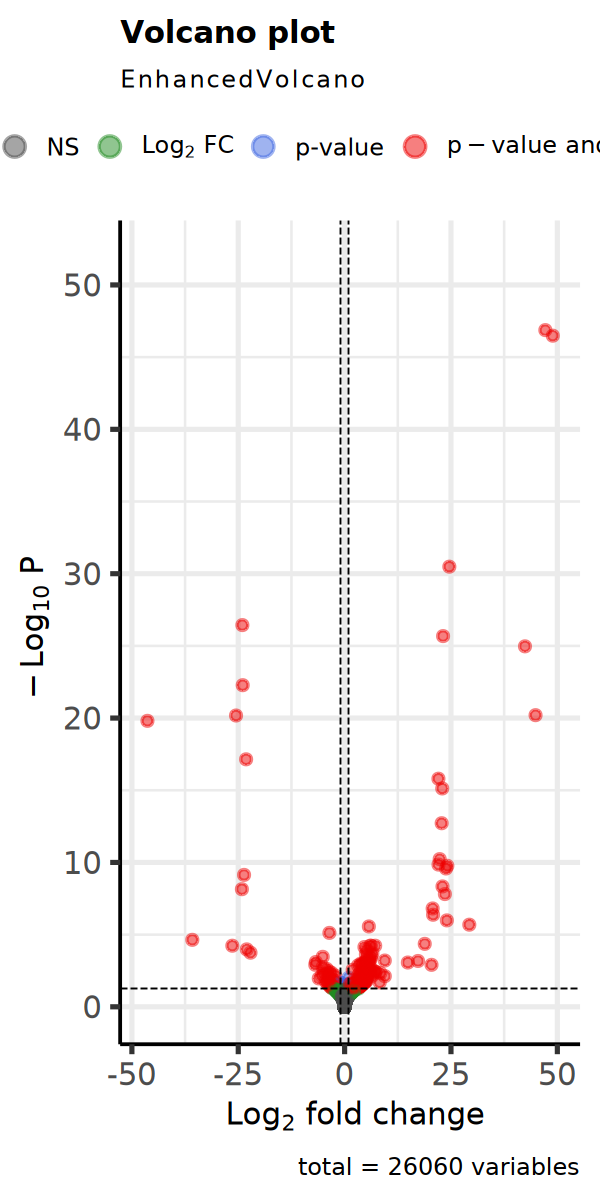

In [244]:
res.wb.cb <- lfcShrink(dds_rm, contrast = c('complete_trtmt', 'warm.both', 'control.both'), # CB is the "control"
                       type = 'ashr')

summary(res.wb.cb)

EnhancedVolcano(res.wb.cb,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.wb.cb <- merge(res.wb.cb, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.wb.cb)[1] <- 'Gene'

head(res.wb.cb)

In [245]:
write.csv(res.wb.cb, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/wb_cb.csv', row.names = FALSE)

**CB vs. HB**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 68, 0.26%
LFC < 0 (down)     : 46, 0.18%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1949.4353,-1.198000e-04,0.006598513,0.5092791,1,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2097.0613,3.469825e-04,0.038934058,0.6887549,1,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,132.0849,-8.502572e-05,0.039799978,0.9281587,1,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,866.8099,-8.214213e-05,0.006457520,0.6458173,1,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12195.3765,4.002502e-05,0.006130082,0.8600324,1,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.8729,-4.876307e-05,0.008440995,0.7540039,1,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


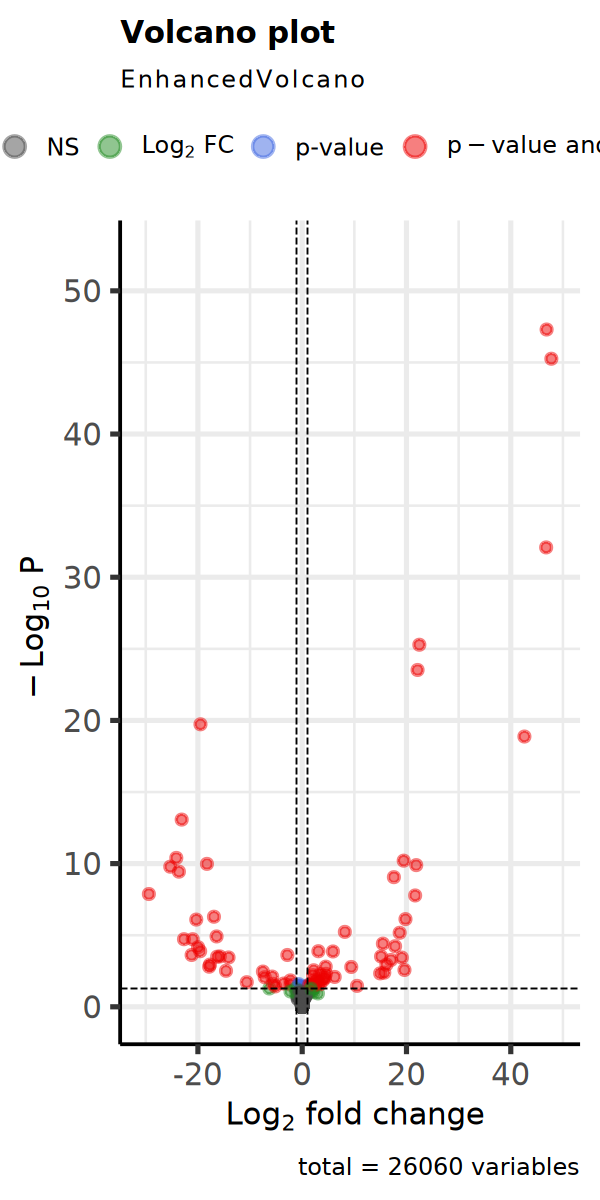

In [246]:
res.hb.cb <- lfcShrink(dds_rm, contrast = c('complete_trtmt', 'hypoxic.both', 'control.both'), # CB is the "control"
                       type = 'ashr')

summary(res.hb.cb)

EnhancedVolcano(res.hb.cb,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.hb.cb <- merge(res.hb.cb, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.hb.cb)[1] <- 'Gene'

head(res.hb.cb)

In [247]:
write.csv(res.hb.cb, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/hb_cb.csv', row.names = FALSE)

### 6. Effect of initial exposure on subsequent response to stress
Oysters all experience the same early stressor, but either return to that stressor or experience control conditions
- HC vs. HH
- WC vs. WW
- BB vs. BC

**HC vs. HH**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 150, 0.58%
LFC < 0 (down)     : 109, 0.42%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1949.4353,-0.0029918860,0.07798142,0.9067505,0.9914525,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2097.0613,-0.0025349220,0.11204156,0.7366114,0.9747869,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,132.0849,-0.0012031717,0.11516127,0.8726017,0.9880202,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,866.8099,-0.0004343138,0.07798496,0.9864183,0.9994837,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12195.3765,0.0056758901,0.07408432,0.8576259,0.9859211,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.8729,-0.0038062598,0.08255336,0.7978433,0.9814453,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


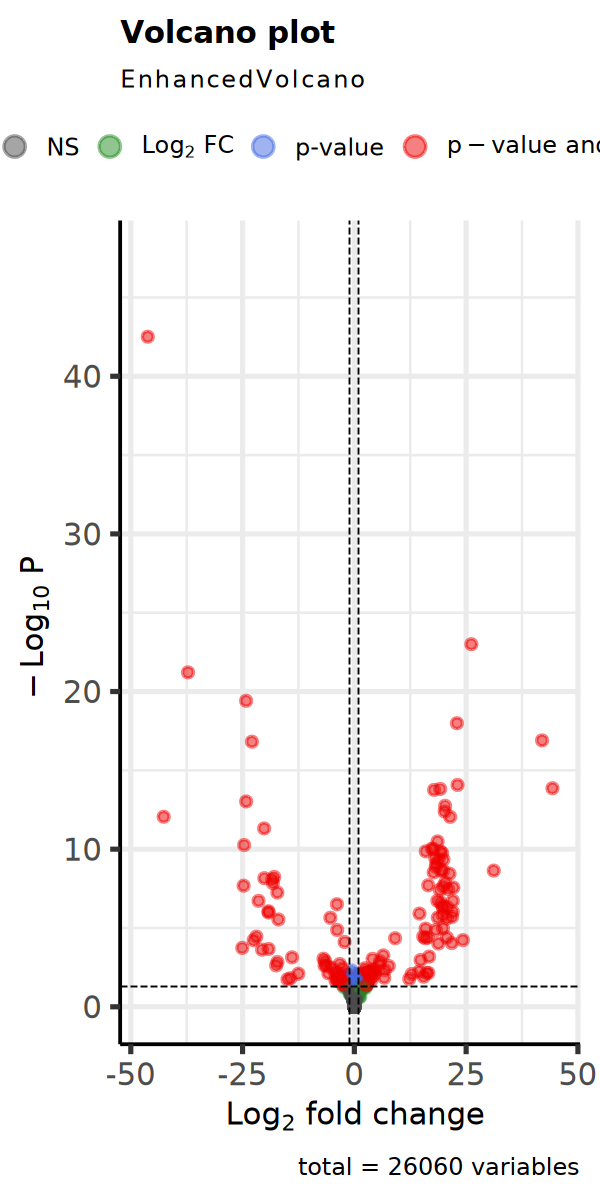

In [248]:
res.hc.hh <- lfcShrink(dds_rm, contrast = c('complete_trtmt', 'hypoxic.control', 'hypoxic.hypoxic'), # HH is the "control"
                     type = 'ashr')

summary(res.hc.hh)

EnhancedVolcano(res.hc.hh,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.hc.hh <- merge(res.hc.hh, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.hc.hh)[1] <- 'Gene'

head(res.hc.hh)

In [249]:
write.csv(res.hc.hh, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/hc_hh.csv', row.names = FALSE)

**WC vs. WW**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 87, 0.33%
LFC < 0 (down)     : 102, 0.39%
outliers [1]       : 79, 0.3%
low counts [2]     : 1011, 3.9%
(mean count < 4)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1949.4353,-0.037738152,0.1319155,0.6215518,0.8959790,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2097.0613,-0.020585307,0.1878330,0.3176881,0.7494947,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,132.0849,0.001815557,0.1752821,0.9213585,0.9822940,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,866.8099,0.072313528,0.1329505,0.3458908,0.7671782,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12195.3765,0.095383165,0.1164180,0.2362934,0.6863119,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.8729,0.020334658,0.1537161,0.7071129,0.9254195,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


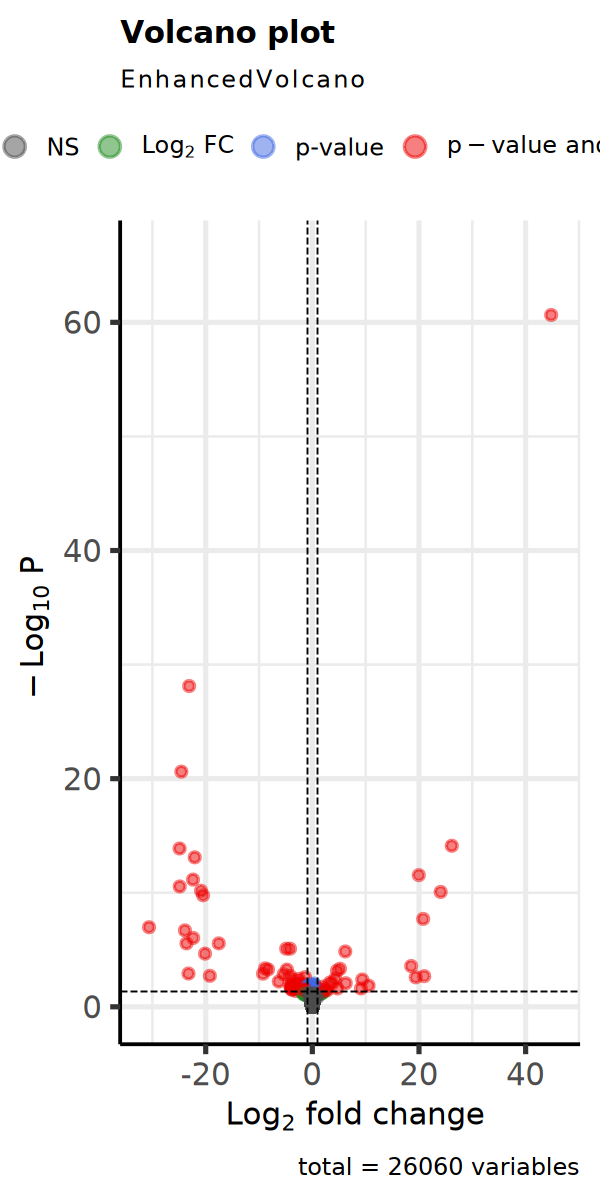

In [250]:
res.wc.ww <- lfcShrink(dds_rm, contrast = c('complete_trtmt', 'warm.control', 'warm.warm'), # WW is the "control"
                     type = 'ashr')

summary(res.wc.ww)

EnhancedVolcano(res.wc.ww,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.wc.ww <- merge(res.wc.ww, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.wc.ww)[1] <- 'Gene'

head(res.wc.ww)

In [251]:
write.csv(res.wc.ww, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/wc_ww.csv', row.names = FALSE)

**BC vs. BB**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 76, 0.29%
LFC < 0 (down)     : 316, 1.2%
outliers [1]       : 79, 0.3%
low counts [2]     : 506, 1.9%
(mean count < 3)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1949.4353,-0.029050377,0.09344341,0.39752099,0.9018087,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2097.0613,0.001401537,0.13540315,0.90217245,0.9906321,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,132.0849,-0.198401080,0.90142270,0.01205333,0.2784523,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,866.8099,0.006057950,0.08914812,0.85534030,0.9870586,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12195.3765,0.014196791,0.08123863,0.70540542,0.9734961,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.8729,0.004902862,0.10179672,0.82770381,0.9863736,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


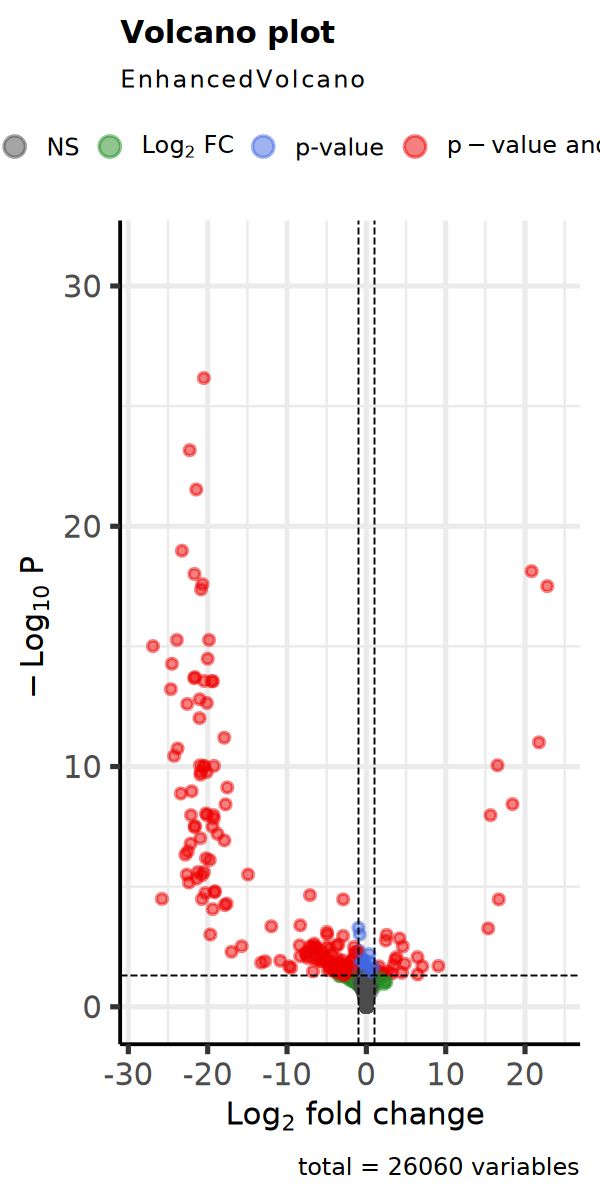

In [252]:
res.bc.bb <- lfcShrink(dds_rm, coef = 'complete_trtmt_both.control_vs_both.both', # BB is the "control"
                     type = 'ashr')

summary(res.bc.bb)

EnhancedVolcano(res.bc.bb,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.bc.bb <- merge(res.bc.bb, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.bc.bb)[1] <- 'Gene'

head(res.bc.bb)

In [253]:
write.csv(res.bc.bb, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/bc_bb.csv', row.names = FALSE)

### 7. Effect of initial single/multiple stress on response in ...
Is it better to be primed with a single stressor or multiple stressor, depending on the context of the future enviornment (single/multiple stressor)?

#### 7A. ...later *single* stress
Oyster is primed with either multiple or a single stressors, and then experiences only a sinlge stressor later
- BH vs. HH
- BW vs. WW

**BH vs. HH**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 154, 0.59%
LFC < 0 (down)     : 180, 0.69%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1949.4353,0.018968322,0.09857140,0.62646648,0.9396283,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2097.0613,-0.006501903,0.14022996,0.53913853,0.9227563,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,132.0849,-0.003998918,0.13957304,0.69385275,0.9512393,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,866.8099,-0.078782944,0.10353275,0.04871548,0.5395851,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12195.3765,-0.045151460,0.09251203,0.33361050,0.8539470,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.8729,0.018328707,0.10680296,0.43728328,0.8927288,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


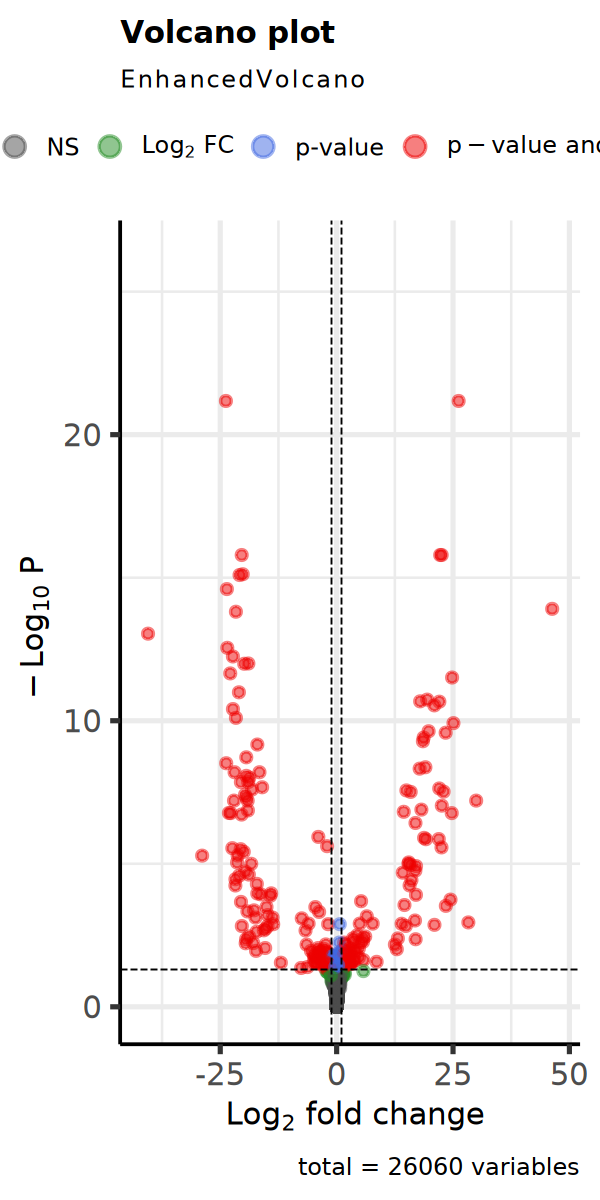

In [254]:
res.hh.bh <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'both.hypoxic', 'hypoxic.hypoxic'), # HH is the "control"
                     type = 'ashr')

summary(res.hh.bh)

EnhancedVolcano(res.hh.bh,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.hh.bh <- merge(res.hh.bh, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.hh.bh)[1] <- 'Gene'

head(res.hh.bh)

In [255]:
write.csv(res.hh.bh, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/bh_hh.csv', row.names = FALSE)

**BW vs. WW**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 60, 0.23%
LFC < 0 (down)     : 112, 0.43%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1949.4353,-0.008960441,0.08021959,0.7518669,0.9762012,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2097.0613,-0.008755456,0.13208065,0.2863380,0.8554512,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,132.0849,0.003051413,0.11122211,0.6635044,0.9638748,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,866.8099,0.006495712,0.08023444,0.8181722,0.9821763,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12195.3765,-0.017377597,0.07588154,0.6166706,0.9536528,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.8729,-0.007824331,0.08520629,0.6367942,0.9584748,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


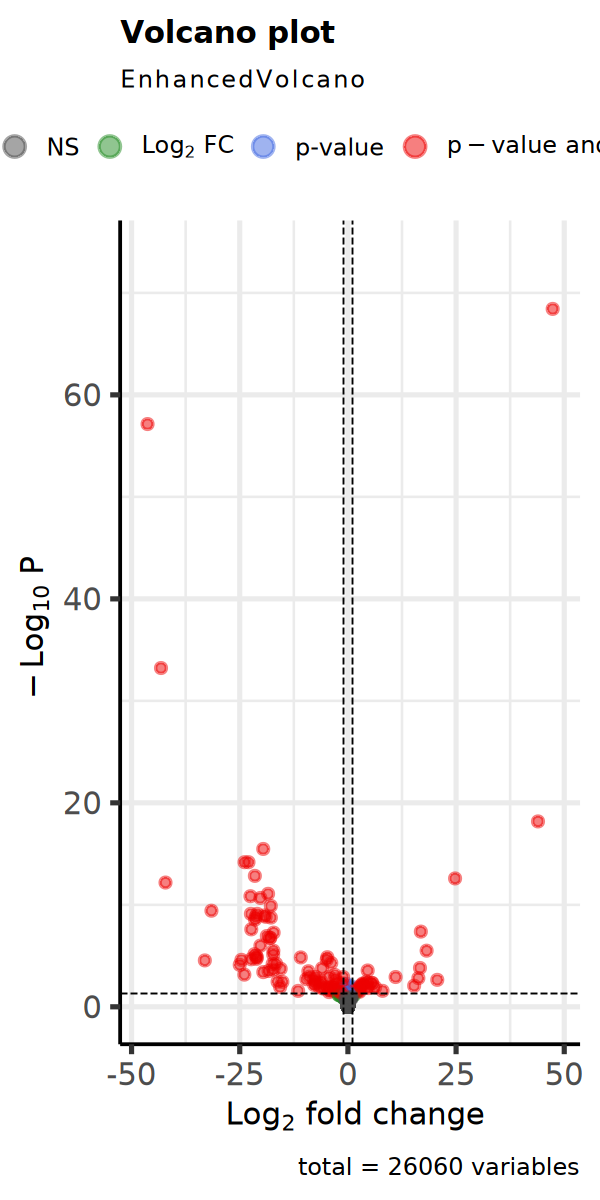

In [256]:
res.bw.ww <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'both.warm', 'warm.warm'), # WW is the "control"
                     type = 'ashr')

summary(res.bw.ww)

EnhancedVolcano(res.bw.ww,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.bw.ww <- merge(res.bw.ww, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.bw.ww)[1] <- 'Gene'

head(res.bw.ww)

In [257]:
write.csv(res.bw.ww, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/bw_ww.csv', row.names = FALSE)

#### 7B. ...later *multiple* stressors
Oyster is primed with either multiple or a single stressors, and then experiences multiple stressors later
- HB vs. BB
- WB vs. BB

**HB vs. BB**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 52, 0.2%
LFC < 0 (down)     : 81, 0.31%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1949.4353,-2.231568e-04,0.008783081,0.4523478,0.9998085,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2097.0613,-1.552763e-04,0.055591930,0.9386032,0.9998085,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,132.0849,4.933351e-04,0.063475946,0.8324372,0.9998085,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,866.8099,-8.319474e-05,0.008066272,0.7668348,0.9998085,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12195.3765,5.914334e-04,0.009983965,0.1351275,0.9313029,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.8729,5.984043e-05,0.012118926,0.8553990,0.9998085,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


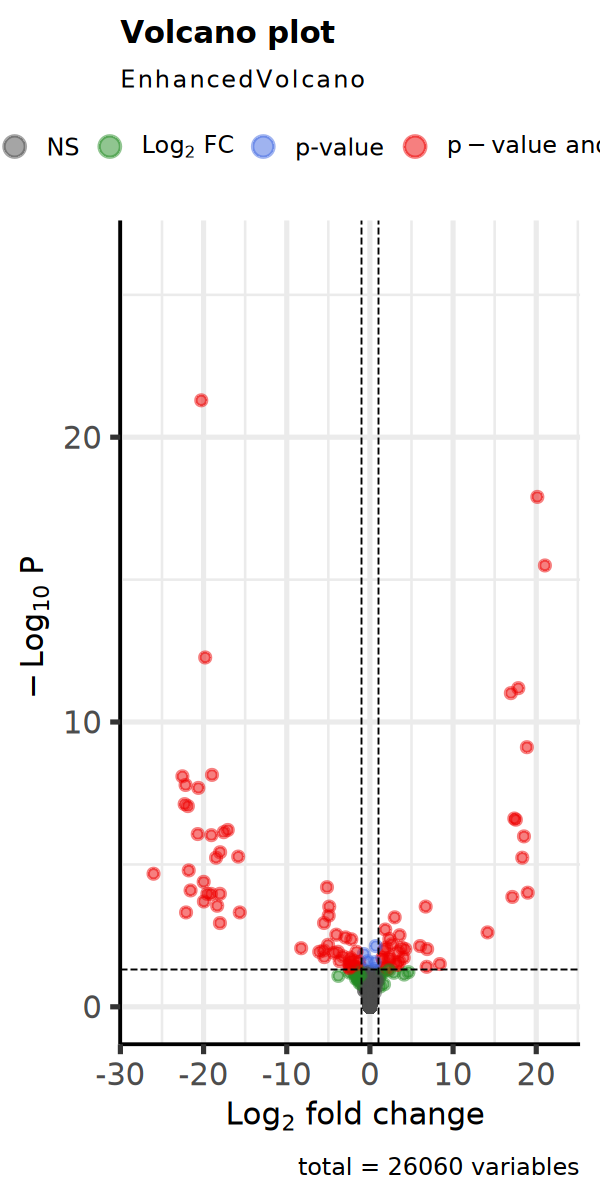

In [258]:
res.hb.bb <- lfcShrink(dds_rm, 
                       coef= 'complete_trtmt_hypoxic.both_vs_both.both', # BB is the "control"
                     type = 'ashr')

summary(res.hb.bb)

EnhancedVolcano(res.hb.bb,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.hb.bb <- merge(res.hb.bb, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.hb.bb)[1] <- 'Gene'

head(res.hb.bb)

In [259]:
write.csv(res.hb.bb, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/hb_bb.csv', row.names = FALSE)

**WB vs. BB**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 67, 0.26%
LFC < 0 (down)     : 47, 0.18%
outliers [1]       : 79, 0.3%
low counts [2]     : 506, 1.9%
(mean count < 3)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1949.4353,2.931105e-05,0.008249004,0.9219559,0.9998257,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2097.0613,-4.618784e-04,0.060310032,0.8417052,0.9998257,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,132.0849,1.634629e-03,0.077263466,0.5706483,0.9998257,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,866.8099,-3.530256e-04,0.010350355,0.3088972,0.9925409,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12195.3765,1.473525e-04,0.007719557,0.6765643,0.9998257,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.8729,7.812109e-04,0.024720225,0.2264678,0.9614486,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


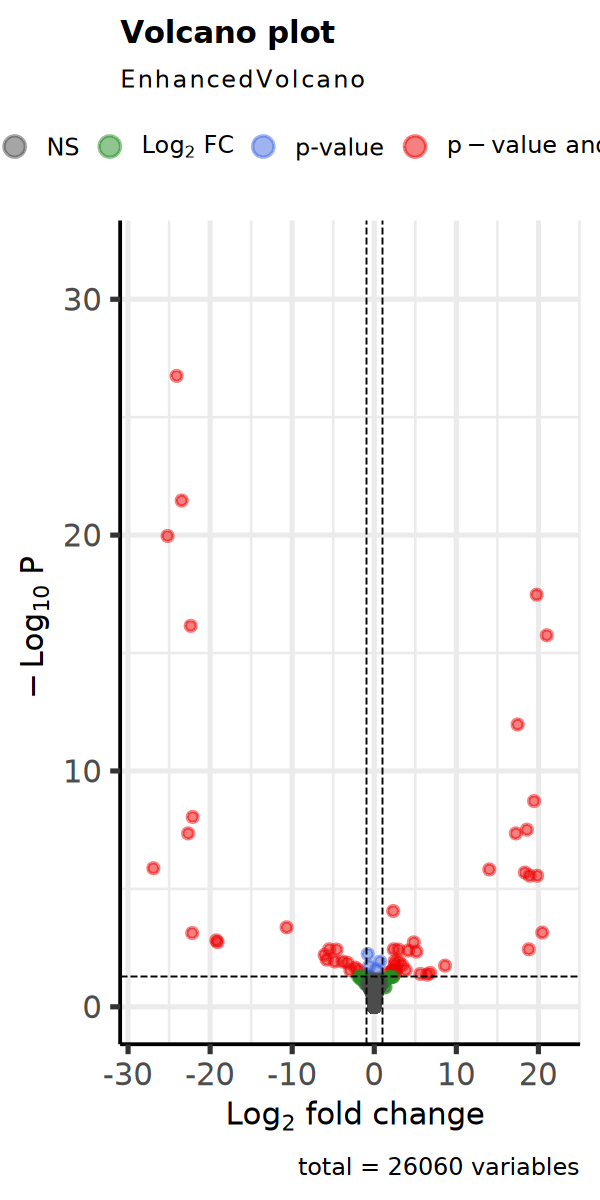

In [260]:
res.wb.bb <- lfcShrink(dds_rm, 
                       coef= 'complete_trtmt_warm.both_vs_both.both', # BB is the "control"
                     type = 'ashr')

summary(res.wb.bb)

EnhancedVolcano(res.wb.bb,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.wb.bb <- merge(res.wb.bb, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.wb.bb)[1] <- 'Gene'

head(res.wb.bb)

In [261]:
write.csv(res.wb.bb, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/wb_bb.csv', row.names = FALSE)

### 8. Shared/Unique responses among stressors with ...

#### 8A. ...different *early* stressors
>can compare these with the phase 1 vs. phase 1 DEGs to see if there are similarities
- WC vs. HC: single early stress
- BC vs. HC: mulitple vs. single
- BC vs. WC: multiple vs. single

**WC vs. HC**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 62, 0.24%
LFC < 0 (down)     : 39, 0.15%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1949.4353,1.919649e-04,0.007167816,0.2922971,1,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2097.0613,8.421776e-04,0.051313774,0.4757594,1,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,132.0849,-1.790786e-05,0.042706489,0.9869234,1,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,866.8099,-8.430958e-05,0.006304253,0.6162482,1,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12195.3765,4.261540e-05,0.005869028,0.8375327,1,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.8729,1.930622e-04,0.011817624,0.3458937,1,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


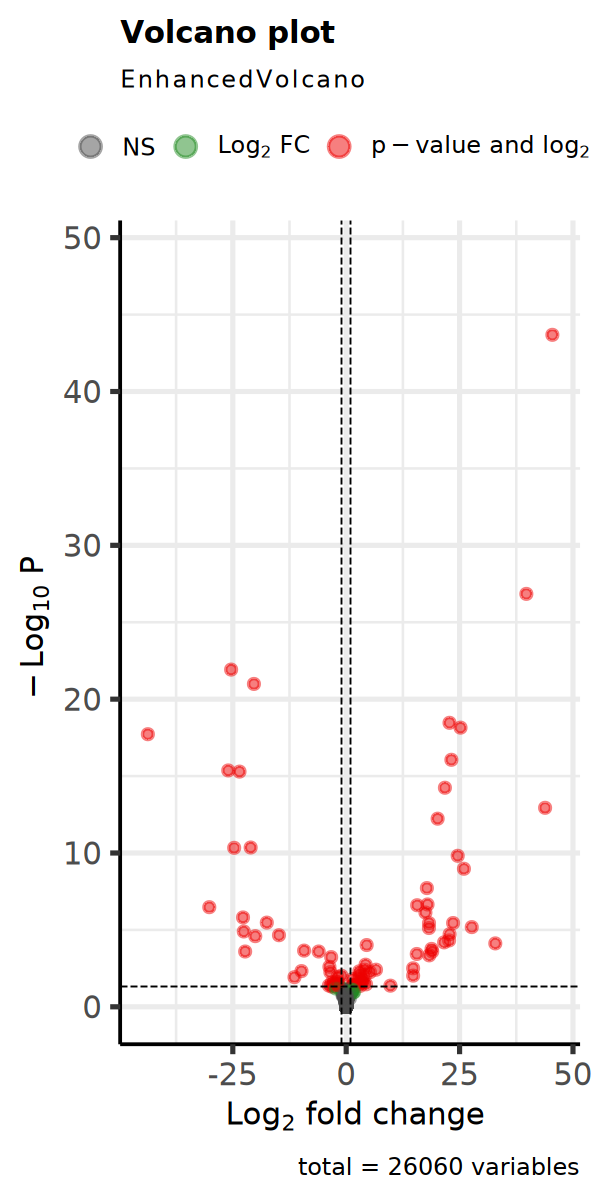

In [262]:
res.wc.hc <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'warm.control', 'hypoxic.control'), # HC is the "control"
                     type = 'ashr')

summary(res.wc.hc)

EnhancedVolcano(res.wc.hc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.wc.hc <- merge(res.wc.hc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.wc.hc)[1] <- 'Gene'

head(res.wc.hc)

In [263]:
write.csv(res.wc.hc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/wc_hc.csv', row.names = FALSE)

**BC vs. HC**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 48, 0.18%
LFC < 0 (down)     : 119, 0.46%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1949.4353,6.353263e-06,0.006107129,0.96764644,1,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2097.0613,4.448622e-03,0.123701333,0.12900889,1,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,132.0849,-1.098138e-02,0.213149981,0.06600494,1,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,866.8099,-1.486193e-05,0.006113404,0.92438242,1,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12195.3765,2.767610e-05,0.005854480,0.88853218,1,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.8729,-2.241928e-05,0.008305642,0.88020057,1,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


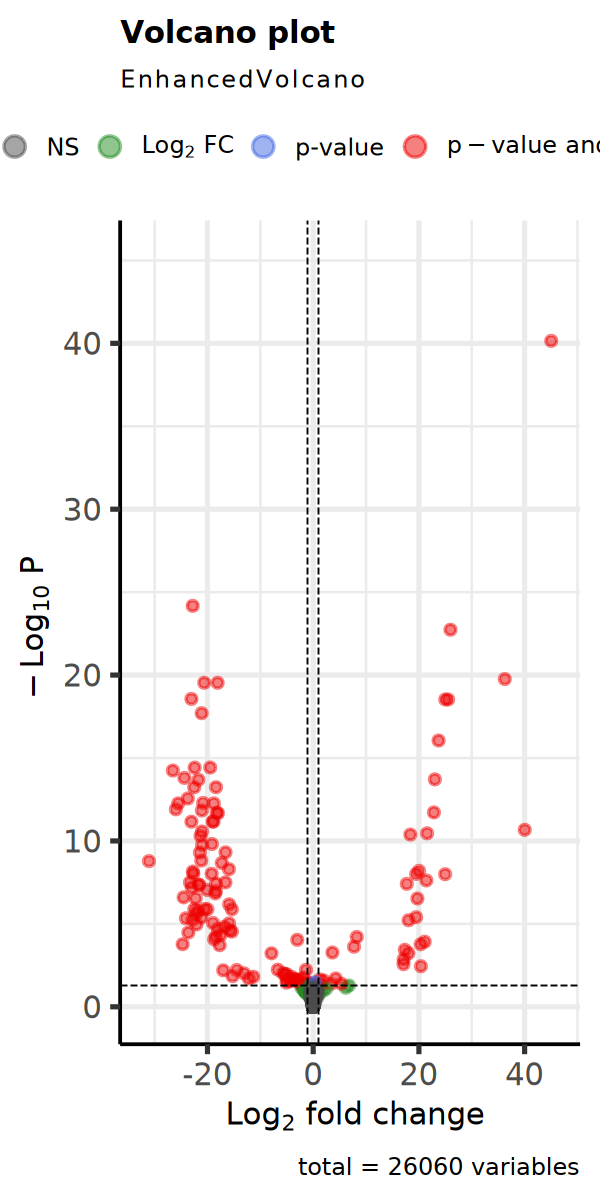

In [264]:
res.bc.hc <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'both.control', 'hypoxic.control'), # HC is the "control"
                     type = 'ashr')

summary(res.bc.hc)

EnhancedVolcano(res.bc.hc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.bc.hc <- merge(res.bc.hc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.bc.hc)[1] <- 'Gene'

head(res.bc.hc)

In [265]:
write.csv(res.bc.hc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/bc_hc.csv', row.names = FALSE)

**BC vs. WC**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 58, 0.22%
LFC < 0 (down)     : 202, 0.78%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1949.4353,-0.0002149845,0.008583531,0.33525895,0.9995207,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2097.0613,0.0027584820,0.093169193,0.40198415,0.9995207,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,132.0849,-0.0234862900,0.303144592,0.06833586,0.8051373,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,866.8099,0.0000739098,0.006945185,0.70170459,0.9995207,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12195.3765,-0.0000115844,0.006025311,0.95585783,0.9995207,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.8729,-0.0004616479,0.019687457,0.29398984,0.9995207,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


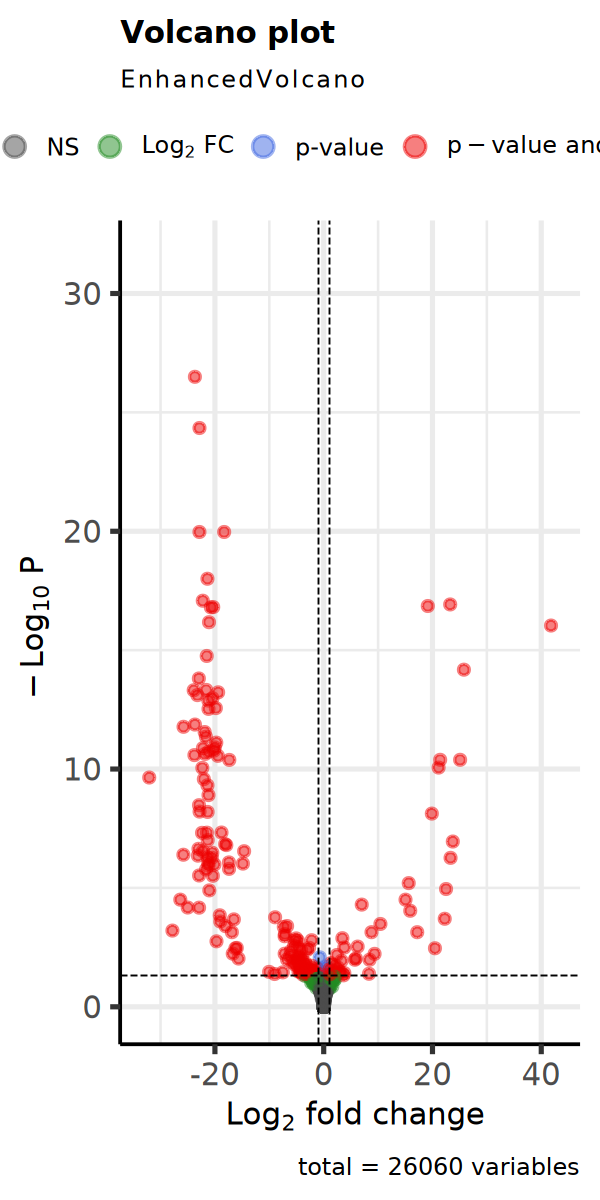

In [266]:
res.bc.wc <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'both.control', 'warm.control'), # WC is the "control"
                     type = 'ashr')

summary(res.bc.wc)

EnhancedVolcano(res.bc.wc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.bc.wc <- merge(res.bc.wc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.bc.wc)[1] <- 'Gene'

head(res.bc.wc)

In [267]:
write.csv(res.bc.wc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/bc_wc.csv', row.names = FALSE)

#### 8B. ...different *late* stressors
- CW vs. CH: single early stress
- CB vs. CH: mulitple vs. single
- CB vs. CW: multiple vs. single

**CW vs. CH**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 138, 0.53%
LFC < 0 (down)     : 71, 0.27%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1949.4353,0.038808502,0.07301369,0.05644975,0.5626799,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2097.0613,0.025435264,0.25084937,0.11408896,0.6886735,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,132.0849,0.009982740,0.16226334,0.34604242,0.8669081,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,866.8099,0.005938533,0.06651325,0.75972977,0.9718314,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12195.3765,0.032976642,0.06496539,0.18399621,0.7637743,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.8729,0.001401342,0.07046269,0.90179597,0.9927446,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


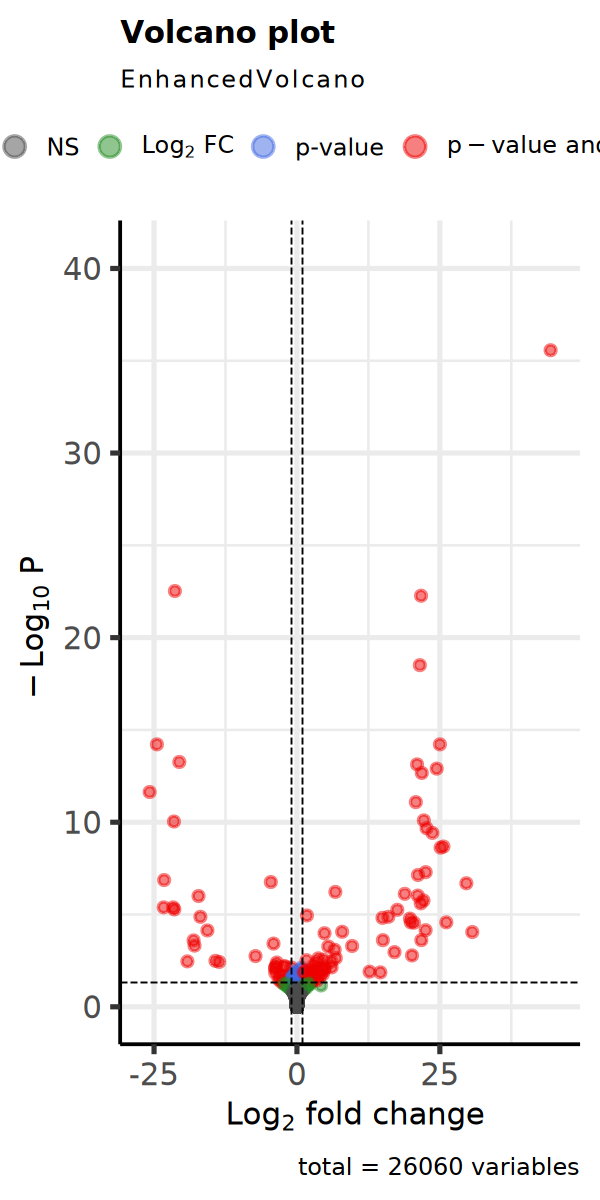

In [268]:
res.cw.ch <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'control.warm', 'control.hypoxic'), # CH is the "control"
                     type = 'ashr')

summary(res.cw.ch)

EnhancedVolcano(res.cw.ch,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cw.ch <- merge(res.cw.ch, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cw.ch)[1] <- 'Gene'

head(res.cw.ch)

In [269]:
write.csv(res.cw.ch, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/cw_ch.csv', row.names = FALSE)

**CB vs. CH**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 137, 0.53%
LFC < 0 (down)     : 153, 0.59%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1949.4353,0.045718288,0.09755116,0.261345882,0.8130796,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2097.0613,0.007801261,0.15105079,0.558866040,0.9257276,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,132.0849,0.215054917,0.88679243,0.009967606,0.2871046,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,866.8099,0.030502331,0.09638094,0.449483256,0.8938974,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12195.3765,0.175645242,0.12004670,0.001471506,0.1150044,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.8729,0.002166253,0.10475918,0.931271354,0.9915575,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


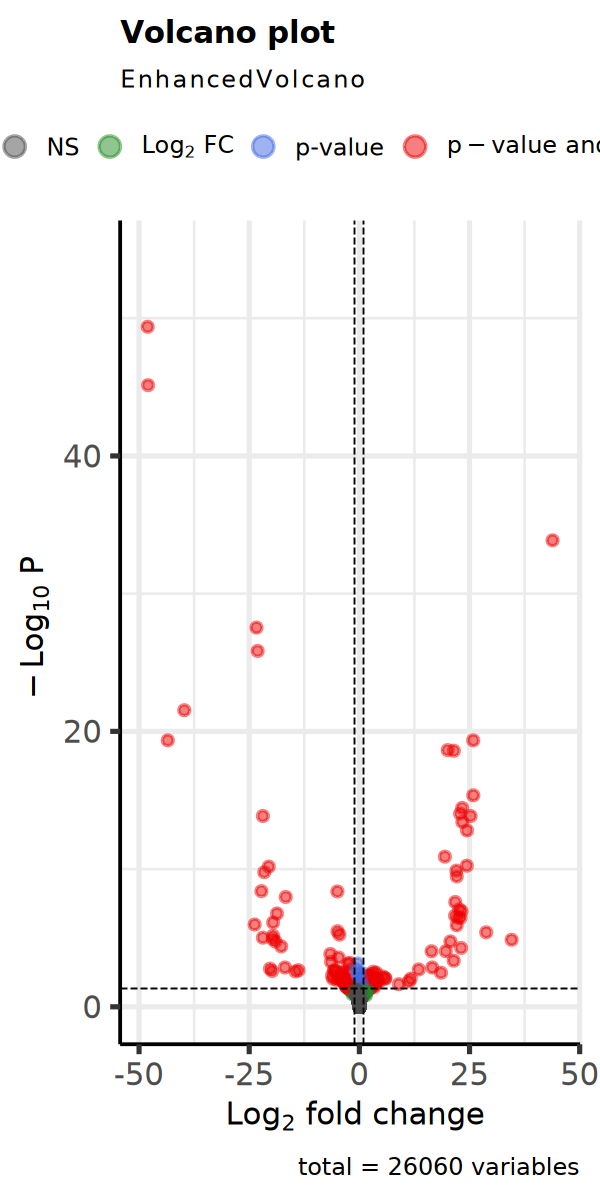

In [270]:
res.cb.ch <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'control.both', 'control.hypoxic'), # CH is the "control"
                     type = 'ashr')

summary(res.cb.ch)

EnhancedVolcano(res.cb.ch,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cb.ch <- merge(res.cb.ch, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cb.ch)[1] <- 'Gene'

head(res.cb.ch)

In [271]:
write.csv(res.cb.ch, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/cb_ch.csv', row.names = FALSE)

**CB vs. CW**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 117, 0.45%
LFC < 0 (down)     : 112, 0.43%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1949.4353,-0.0259807874,0.08721591,0.43289505,0.8927112,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2097.0613,-0.0124201025,0.16041891,0.31946251,0.8509965,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,132.0849,0.0292741874,0.26067571,0.10153230,0.6828503,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,866.8099,0.0148318186,0.08672823,0.65255212,0.9476555,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12195.3765,0.0753405206,0.08504467,0.06408618,0.6081165,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.8729,-0.0007548153,0.09425405,0.97037727,0.9962374,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


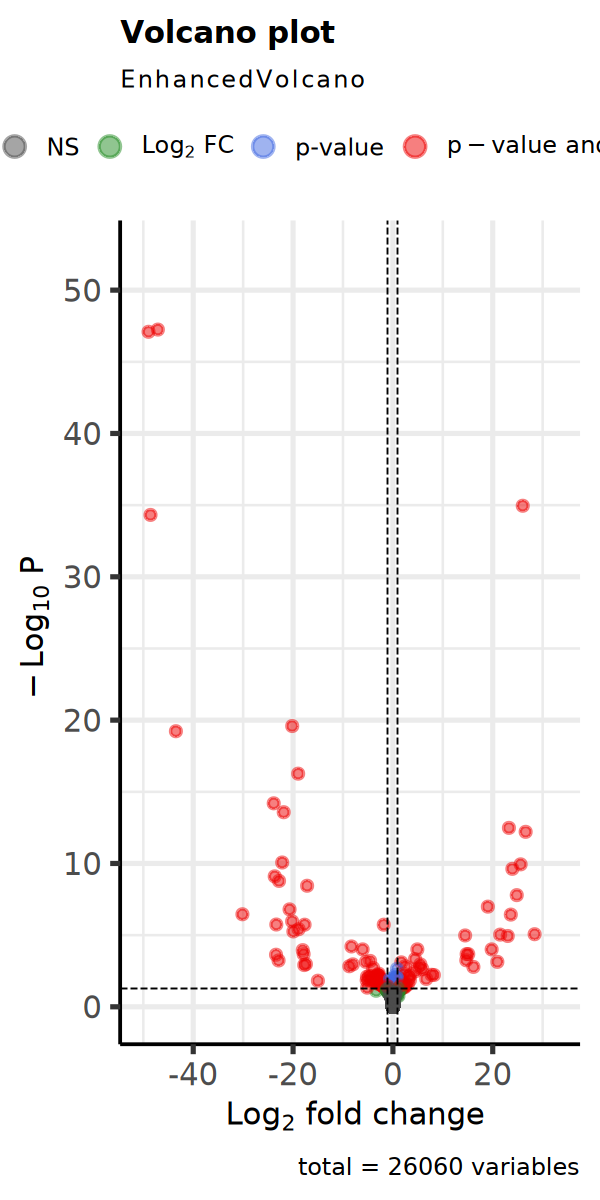

In [272]:
res.cb.cw <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'control.both', 'control.warm'), # CW is the "control"
                     type = 'ashr')

summary(res.cb.cw)

EnhancedVolcano(res.cb.cw,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cb.cw <- merge(res.cb.cw, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cb.cw)[1] <- 'Gene'

head(res.cb.cw)

In [273]:
write.csv(res.cb.cw, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/cb_cw.csv', row.names = FALSE)

### 9. Effect of the order of stressors
Does the order of when stress is experienced matter? Maybe one stressor is an informative cue for a later environmnet?
- WH vs. HW
- WB vs. BW
- HB vs. BH

**WH vs. HW**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 59, 0.23%
LFC < 0 (down)     : 94, 0.36%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1949.4353,0.0005316293,0.05107507,0.9630993,0.9964677,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2097.0613,-0.0034767356,0.09331574,0.4577018,0.9609734,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,132.0849,-0.0007764507,0.08511626,0.8562979,0.9904300,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,866.8099,0.0037295720,0.05134594,0.7459767,0.9847540,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12195.3765,-0.0030042405,0.04875987,0.8341485,0.9904300,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.8729,-0.0014569893,0.05604909,0.8395865,0.9904300,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


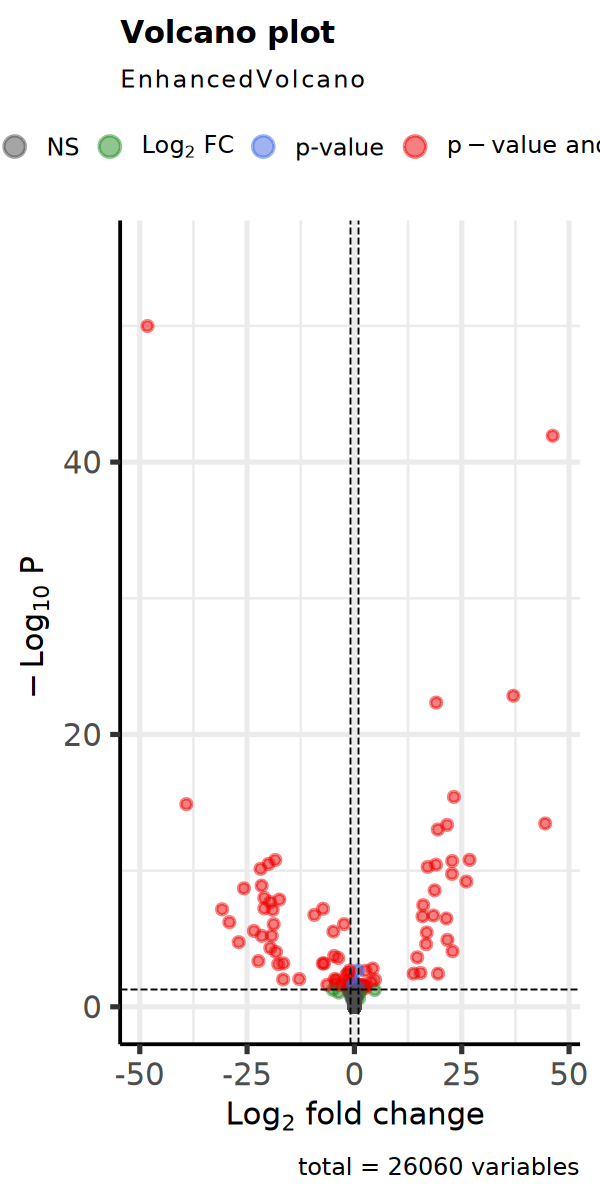

In [274]:
res.wh.hw <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'warm.hypoxic', 'hypoxic.warm'), # HW is the "control"
                     type = 'ashr')

summary(res.wh.hw)

EnhancedVolcano(res.wh.hw,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.wh.hw <- merge(res.wh.hw, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.wh.hw)[1] <- 'Gene'

head(res.wh.hw)

In [275]:
write.csv(res.wh.hw, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/wh_hw.csv', row.names = FALSE)

**WB vs. BW**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 377, 1.4%
LFC < 0 (down)     : 129, 0.5%
outliers [1]       : 79, 0.3%
low counts [2]     : 506, 1.9%
(mean count < 3)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1949.4353,-0.010395994,0.1079025,0.83934155,0.9682691,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2097.0613,0.012730500,0.1916181,0.53701644,0.8717138,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,132.0849,0.023238942,0.2443458,0.33929104,0.7818579,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,866.8099,-0.004844178,0.1079684,0.92457159,0.9853715,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12195.3765,0.097336165,0.1008425,0.09947126,0.5416141,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.8729,0.024375477,0.1219687,0.46613530,0.8459640,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


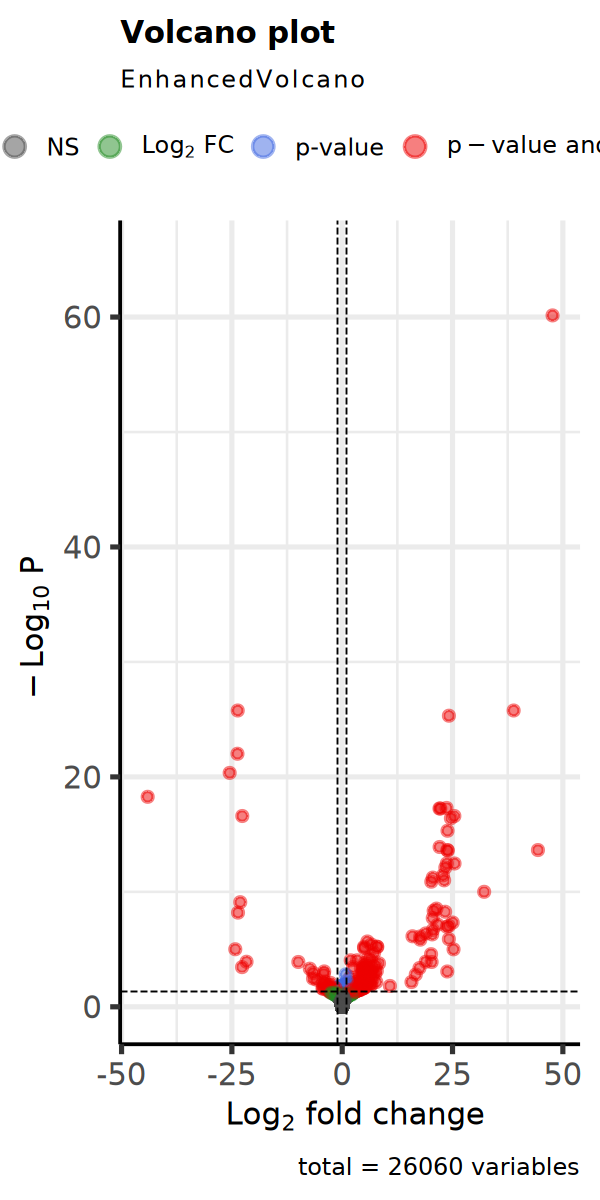

In [276]:
res.wb.bw <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'warm.both', 'both.warm'), # BW is the "control"
                     type = 'ashr')

summary(res.wb.bw)

EnhancedVolcano(res.wb.bw,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.wb.bw <- merge(res.wb.bw, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.wb.bw)[1] <- 'Gene'

head(res.wb.bw)

In [277]:
write.csv(res.wb.bw, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/wb_bw.csv', row.names = FALSE)

**HB vs. BH**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 367, 1.4%
LFC < 0 (down)     : 112, 0.43%
outliers [1]       : 79, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1949.4353,-0.02653231,0.1179627,0.64875053,0.9281270,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2097.0613,0.04916940,0.3415243,0.10380431,0.5516343,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,132.0849,0.02523249,0.2477509,0.25941570,0.7352328,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,866.8099,0.08753774,0.1212815,0.13878787,0.6094362,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12195.3765,0.16106462,0.1139730,0.01750695,0.2876965,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.8729,-0.04904456,0.1370302,0.20762237,0.6910543,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


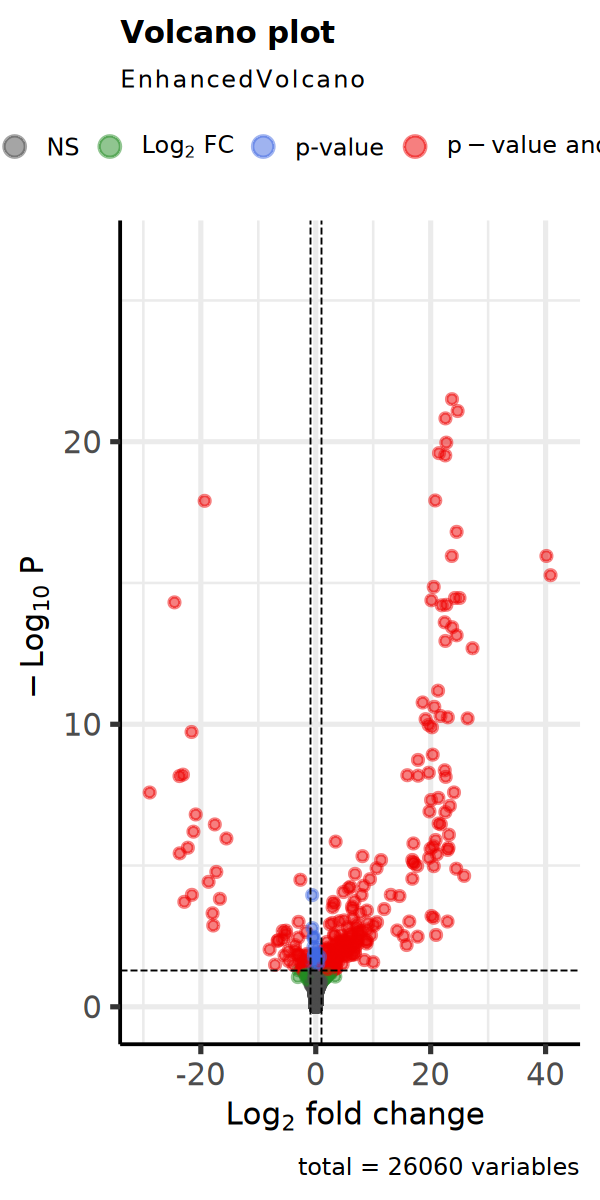

In [278]:
res.hb.bh <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'hypoxic.both', 'both.hypoxic'), # BH is the "control"
                     type = 'ashr')

summary(res.hb.bh)

EnhancedVolcano(res.hb.bh,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.hb.bh <- merge(res.hb.bh, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.hb.bh)[1] <- 'Gene'

head(res.hb.bh)

In [279]:
write.csv(res.hb.bh, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/hb_bh.csv', row.names = FALSE)

## 4. isolated treatment pairwise comparisons
looking at the effects of temperature and DO in an isolated manner

#### phase 1 temp
ambient vs. warm

regardless of phase 2 treatments or phase 1 DO

In [85]:
design(dds_rm) <- ~ Phase1_temp
dds_p1temp <- DESeq(dds_rm)

using pre-existing size factors

estimating dispersions

found already estimated dispersions, replacing these

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 1623 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



In [87]:
vst_temp.p1 <- vst(dds_p1temp, blind = FALSE)
head(vst_temp.p1)

class: DESeqTransform 
dim: 6 92 
metadata(1): version
assays(1): ''
rownames(6): LOC144621260 LOC144621269 ... LOC144621276 LOC111115920
rowData names(23): baseMean baseVar ... replace dispFit
colnames(92): B1_B1_O01 B1_W5_O50 ... W6_W3_G36 W6_W4_G48
colData names(12): Phase1_treatment Phase1_temp ... group replaceable

In [89]:
write.csv(assay(vst_temp.p1), '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/isolated_treatments/vst_p1temp.p2.csv')

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 33, 0.13%
LFC < 0 (down)     : 20, 0.077%
outliers [1]       : 0, 0%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1949.4353,9.194332e-05,0.003045293,0.2239701,0.9259462,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2097.0613,2.332606e-04,0.019241973,0.6891522,0.9888690,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,132.0849,8.626712e-05,0.019719824,0.8909156,0.9949672,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,866.8099,-1.192912e-04,0.003531011,0.1559302,0.8895666,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12195.3765,-6.352865e-05,0.002285109,0.3793323,0.9586465,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.8729,1.006855e-04,0.005266659,0.3345266,0.9517999,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


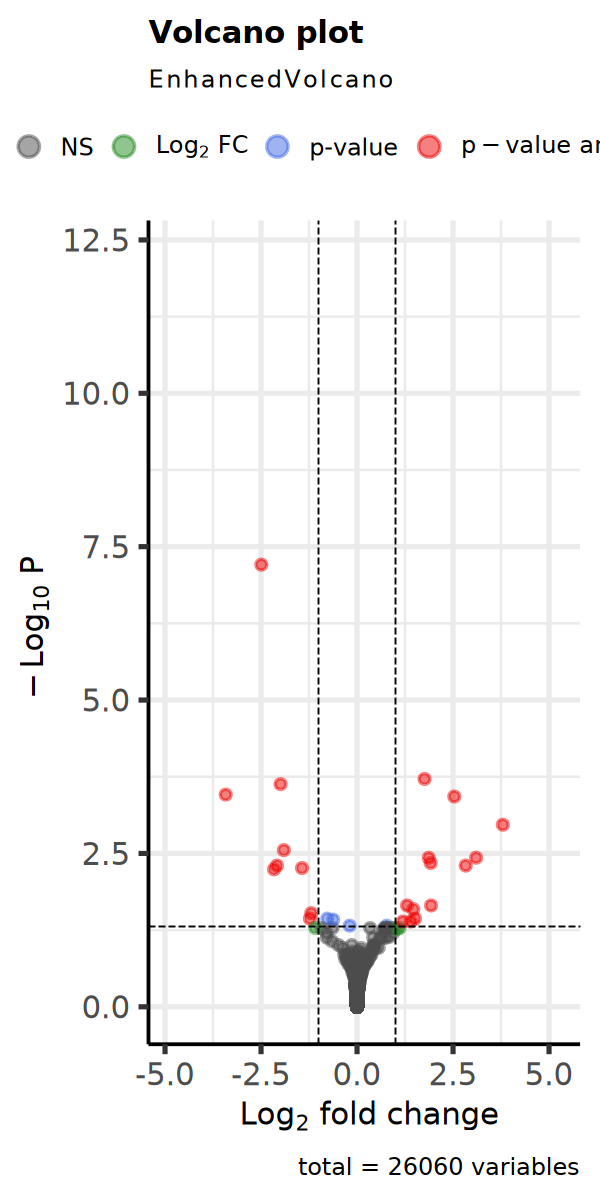

In [281]:
p1_temp.res <- lfcShrink(dds_p1temp, contrast = c('Phase1_temp', 'warm', 'ambient'),
                     type = 'ashr')

summary(p1_temp.res)

EnhancedVolcano(p1_temp.res,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

p1_temp.res <- merge(p1_temp.res, counts(dds_p1temp, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(p1_temp.res)[1] <- 'Gene'

head(p1_temp.res)

In [282]:
as.data.frame(p1_temp.res) %>%
filter(abs(log2FoldChange) > 1 & padj < 0.05) %>%
dim()

# 14 DEGs

[1] 22 98

In [283]:
write.csv(p1_temp.res, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/isolated_treatments/p1_temp.csv', row.names = FALSE)

#### phase 1 DO
normoxic vs. hypoxic

In [90]:
design(dds_rm) <- ~ Phase1_DO
dds_p1DO <- DESeq(dds_rm)

using pre-existing size factors

estimating dispersions

found already estimated dispersions, replacing these

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 1626 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



In [91]:
vst_DO.p1 <- vst(dds_p1DO, blind = FALSE)
head(vst_DO.p1)

class: DESeqTransform 
dim: 6 92 
metadata(1): version
assays(1): ''
rownames(6): LOC144621260 LOC144621269 ... LOC144621276 LOC111115920
rowData names(23): baseMean baseVar ... replace dispFit
colnames(92): B1_B1_O01 B1_W5_O50 ... W6_W3_G36 W6_W4_G48
colData names(12): Phase1_treatment Phase1_temp ... group replaceable

In [92]:
write.csv(assay(vst_DO.p1), '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/isolated_treatments/vst_p1DO.p2.csv')

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 18, 0.069%
LFC < 0 (down)     : 57, 0.22%
outliers [1]       : 0, 0%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1949.4353,-1.142956e-04,0.003371308,0.2165551,0.9950328,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2097.0613,-3.552269e-04,0.022059151,0.6210437,0.9997316,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,132.0849,-1.742986e-04,0.021981456,0.8185242,0.9997316,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,866.8099,1.699618e-05,0.002469576,0.8207352,0.9997316,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12195.3765,3.619230e-05,0.002356943,0.6698179,0.9997316,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.8729,-4.173569e-05,0.004104199,0.6612151,0.9997316,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


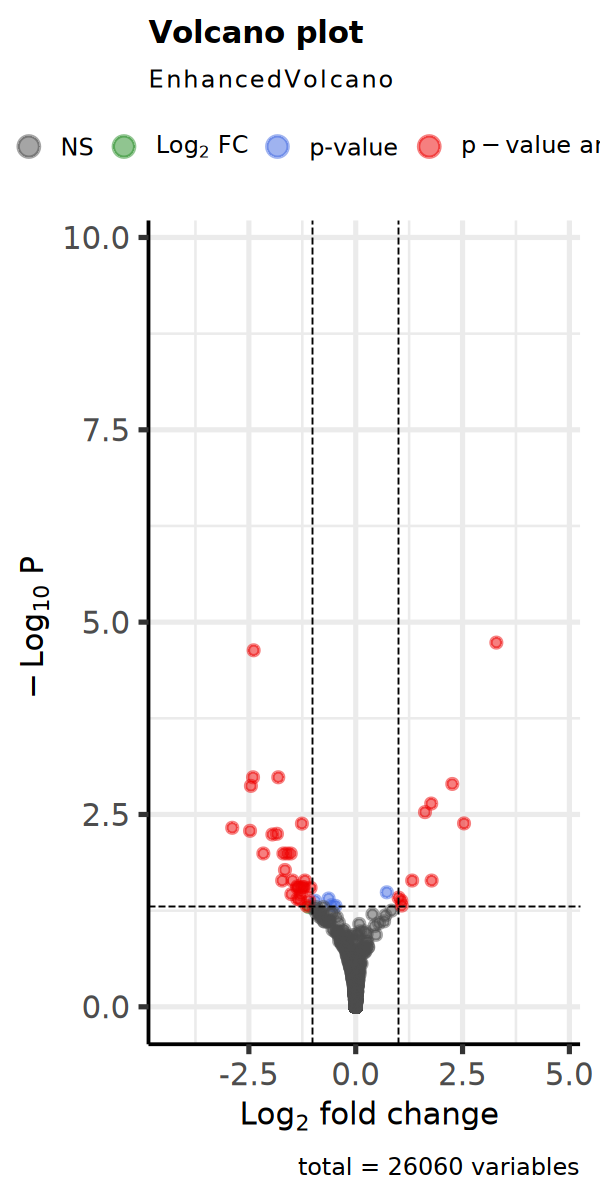

In [285]:
p1_DO.res <- lfcShrink(dds_p1DO, contrast = c('Phase1_DO', 'hypoxic', 'normoxic'), 
                     type = 'ashr')

summary(p1_DO.res)

EnhancedVolcano(p1_DO.res,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

p1_DO.res <- merge(p1_DO.res, counts(dds_p1DO, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(p1_DO.res)[1] <- 'Gene'

head(p1_DO.res)

a couple more DEGs, but still not a ton - to be expected, since we think GE is more short term

In [286]:
as.data.frame(p1_DO.res) %>%
filter(abs(log2FoldChange) >= 1 & padj <= 0.05) %>%
dim()

# 12 DEGs

[1] 39 98

In [287]:
write.csv(p1_DO.res, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/isolated_treatments/p1_DO.csv', row.names = FALSE)

#### phase 2 temp
ambient vs. warm

regardless of phase 1 treatments or phase 2 DO

In [93]:
design(dds_rm) <- ~ Phase2_temp
dds_p2temp <- DESeq(dds_rm)

using pre-existing size factors

estimating dispersions

found already estimated dispersions, replacing these

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 1695 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



In [95]:
vst_temp.p2 <- vst(dds_p2temp, blind = FALSE)
head(vst_temp.p2)

class: DESeqTransform 
dim: 6 92 
metadata(1): version
assays(1): ''
rownames(6): LOC144621260 LOC144621269 ... LOC144621276 LOC111115920
rowData names(23): baseMean baseVar ... replace dispFit
colnames(92): B1_B1_O01 B1_W5_O50 ... W6_W3_G36 W6_W4_G48
colData names(12): Phase1_treatment Phase1_temp ... group replaceable

In [96]:
write.csv(assay(vst_temp.p2), '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/isolated_treatments/vst_p2temp.p2.csv')

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 2117, 8.1%
LFC < 0 (down)     : 1341, 5.1%
outliers [1]       : 0, 0%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1949.4353,0.09824948,0.06887466,0.06641033,0.25815572,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2097.0613,0.24944054,0.45306416,0.01238953,0.09637944,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,132.0849,0.20417546,0.42141044,0.01861760,0.12187051,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,866.8099,-0.04154031,0.06493611,0.41314223,0.68703251,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12195.3765,0.04710868,0.05509091,0.30194367,0.58945630,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.8729,-0.01167950,0.09381850,0.83477588,0.93619053,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


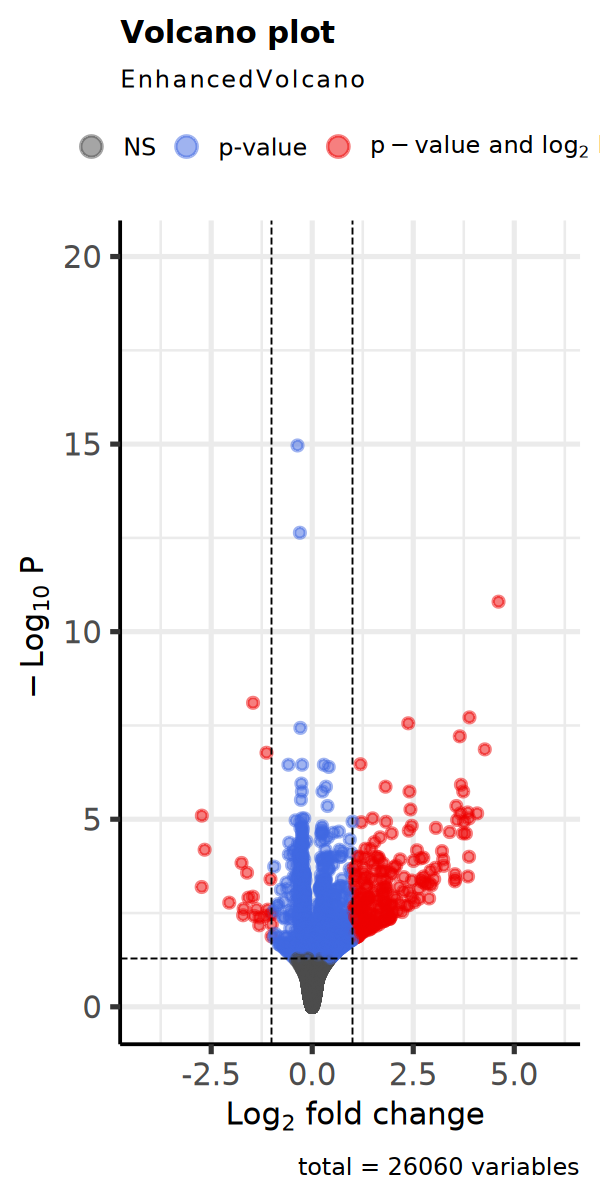

In [289]:
p2_temp.res <- lfcShrink(dds_p2temp, contrast = c('Phase2_temp', 'warm', 'ambient'), 
                     type = 'ashr')

summary(p2_temp.res)

EnhancedVolcano(p2_temp.res,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

p2_temp.res <- merge(p2_temp.res, counts(dds_p2temp, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(p2_temp.res)[1] <- 'Gene'

head(p2_temp.res)

In [290]:
as.data.frame(p2_temp.res) %>%
filter(abs(log2FoldChange) > 1 & padj < 0.05) %>%
dim()

# 80 DEGs!

[1] 264  98

In [291]:
write.csv(p2_temp.res, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/isolated_treatments/p2_temp.csv', row.names = FALSE)

#### phase 2 DO
normoxic vs. hypoxic

regardless of phase 1 treatments or phase 2 temperatures

In [97]:
design(dds_rm) <- ~ Phase2_DO
dds_p2DO <- DESeq(dds_rm)

using pre-existing size factors

estimating dispersions

found already estimated dispersions, replacing these

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 1613 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



In [98]:
vst_DO.p2 <- vst(dds_p2DO, blind = FALSE)
head(vst_DO.p2)

class: DESeqTransform 
dim: 6 92 
metadata(1): version
assays(1): ''
rownames(6): LOC144621260 LOC144621269 ... LOC144621276 LOC111115920
rowData names(23): baseMean baseVar ... replace dispFit
colnames(92): B1_B1_O01 B1_W5_O50 ... W6_W3_G36 W6_W4_G48
colData names(12): Phase1_treatment Phase1_temp ... group replaceable

In [99]:
write.csv(assay(vst_DO.p2), '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/isolated_treatments/vst_p2DO.p2.csv')

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 778, 3%
LFC < 0 (down)     : 415, 1.6%
outliers [1]       : 0, 0%
low counts [2]     : 1516, 5.8%
(mean count < 5)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1949.4353,-0.0397171270,0.05681389,0.2928102,0.7021038,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2097.0613,-0.0130879242,0.10614700,0.4903847,0.8330398,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,132.0849,0.0478268467,0.17341484,0.0570909,0.3544780,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,866.8099,-0.0078650398,0.05426693,0.8295000,0.9602513,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12195.3765,0.0295105611,0.04840828,0.4076732,0.7819132,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.8729,0.0002340967,0.07328987,0.9945521,0.9982421,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


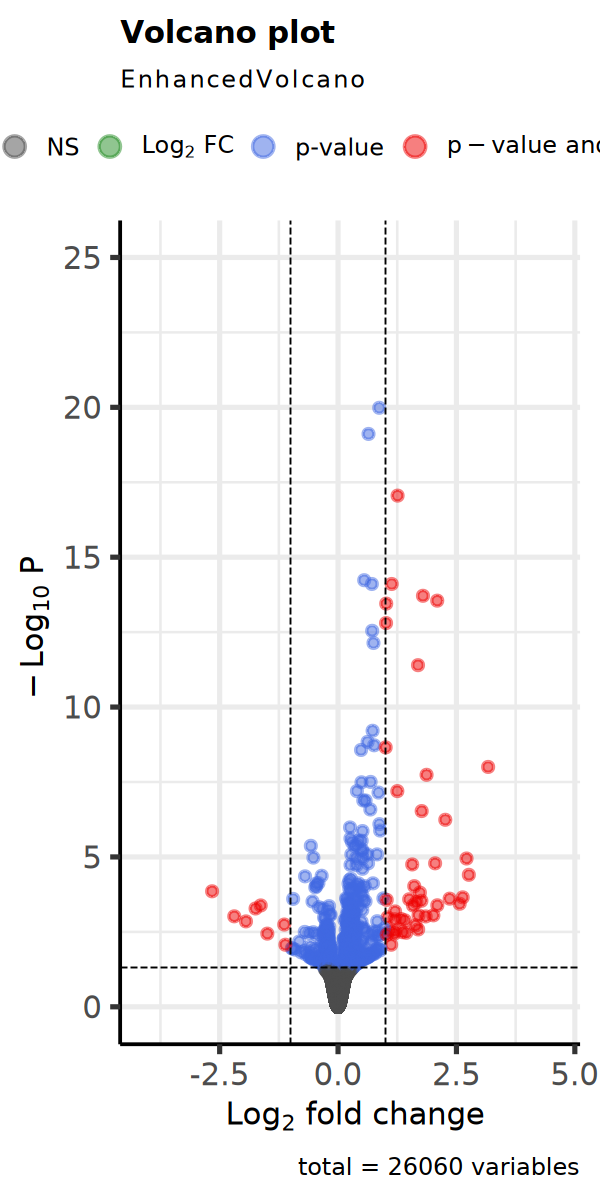

In [293]:
p2_DO.res <- lfcShrink(dds_p2DO, contrast = c('Phase2_DO', 'hypoxic', 'normoxic'), 
                     type = 'ashr')

summary(p2_DO.res)

EnhancedVolcano(p2_DO.res,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

p2_DO.res <- merge(p2_DO.res, counts(dds_p2DO, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(p2_DO.res)[1] <- 'Gene'

head(p2_DO.res)

In [294]:
as.data.frame(p2_DO.res) %>%
filter(abs(log2FoldChange) > 1 & padj < 0.05) %>%
dim()

# 29 DEGs!

[1] 53 98

In [295]:
write.csv(p2_DO.res, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/isolated_treatments/p2_DO.csv', row.names = FALSE)

## nMDS of only significant DEGs
 

### DEGs from pairwise comparisons

In [62]:
# get list of files
files <- list.files(
    path = '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/DEGs',
    full.names = TRUE
    )

names(files) <- gsub('DEG_', '', tools::file_path_sans_ext(basename(files)))
geneList <- lapply(files, read.csv)
names(geneList)

[1] "bb_cc" "bc_bb" "bc_cc" "bc_hc" "bc_wc" "bh_ch" "bh_hh" "bw_cw" "bw_ww"
[10] "cb_bb" "cb_bc" "cb_cc" "cb_ch" "cb_cw" "ch_cc" "ch_hc" "cw_cc" "cw_ch"
[19] "cw_wc" "hb_bb" "hb_bh" "hb_cb" "hc_cc" "hc_hh" "hh_cc" "hh_ch" "wb_bb"
[28] "wb_bw" "wb_cb" "wc_cc" "wc_hc" "wc_ww" "wh_hw" "ww_cc" "ww_cw"

In [67]:
# create list of all DEGs from the four dfs
all_degs <- geneList %>%
  lapply(function(df) {
    df %>%
      dplyr::pull(Gene)
  }) %>%
  unlist() %>%
  unique()

length(all_degs) # 1799 total DEGs
head(all_degs)

[1] 1799

[1] "LOC111102506" "LOC144622036" "LOC144619234" "LOC144622046" "LOC111105159"
[6] "LOC144622060"

In [69]:
# create vst matrix
vsd <- vst(dds_rm, blind = FALSE)

# filter vsd for only degs
degs_vsd <- assay(vsd)[rownames(assay(vsd)) %in% all_degs,]

dim(degs_vsd) # 1799 total DEGs kept
head(degs_vsd) 

[1] 1799   92

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
LOC111104592,8.557672,9.751586,10.136381,9.635419,9.713562,9.968412,11.213844,9.226337,8.643686,8.591284,⋯,11.759696,8.483578,8.483578,9.068104,8.737808,8.640659,11.534097,8.803617,8.930972,11.962772
LOC144621377,9.893899,8.840802,9.290601,8.975301,8.945424,8.939437,8.970980,9.375916,9.094230,9.198908,⋯,9.254855,9.056440,8.922894,8.873083,9.778616,8.851152,9.704576,9.864455,8.769413,8.934316
LOC111104490,9.770230,9.799130,9.293845,10.339603,9.600443,9.989324,10.116991,9.252881,9.500541,9.300131,⋯,10.309983,10.201190,9.654465,9.927858,11.208706,9.267509,9.590686,10.812751,9.743127,9.877169
LOC111105184,9.365179,9.015054,9.280784,8.853147,8.858262,8.841033,9.028725,9.237838,8.905891,9.782644,⋯,8.828189,8.953989,9.606310,8.560190,9.973584,8.978132,9.194792,9.084524,9.078849,8.941039
LOC111105192,8.588352,9.117304,9.021557,9.116382,8.875594,9.523386,8.765870,8.811501,9.005938,9.339522,⋯,8.936951,8.958922,8.737869,9.158425,8.727011,9.024811,8.810373,8.928206,9.212192,8.860337
LOC144618596,9.284985,8.993131,9.451376,9.416087,8.830606,9.901165,9.797846,9.327072,9.476967,9.664405,⋯,8.988428,10.021622,9.348503,9.280647,9.306984,9.584495,8.930232,9.202134,9.123419,9.222864


In [73]:
# calculate sample distances
sample_dists.deg <- degs_vsd %>%
t() %>%
dist() %>%
as.matrix()

head(sample_dists.deg)

# calculate MDS value from distance matrix
mdsData.deg <- data.frame(cmdscale(sample_dists.deg))
mds.deg <- cbind(mdsData.deg, as.data.frame(colData(vsd))) # combine with sample data
head(mds.deg)

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
B1_B1_O01,0.00000,37.53021,39.30531,34.04724,41.50125,34.79517,46.21144,33.14525,35.12602,31.63789,⋯,58.59309,31.37983,29.71852,28.00833,27.81260,31.30795,57.09113,31.37002,32.04329,59.28479
B1_W5_O50,37.53021,0.00000,37.11018,26.33465,29.91770,31.84554,31.02155,31.11594,32.87268,34.96545,⋯,45.99283,35.95095,35.44872,35.12246,37.22710,35.00575,44.20031,35.58579,33.13384,43.68444
B2_B5_O51,39.30531,37.11018,0.00000,39.30707,38.29141,40.61081,39.47562,40.83617,45.75088,44.00994,⋯,44.71343,45.26525,43.65468,35.65309,41.85488,43.27160,46.80869,43.17089,42.09378,45.50193
B2_C4_O40,34.04724,26.33465,39.30707,0.00000,33.55047,25.77332,36.04967,27.52070,28.42960,28.51621,⋯,51.71949,29.72102,29.64402,31.33598,33.41952,29.66048,51.49884,28.71018,25.66138,50.42559
B3_B4_O41,41.50125,29.91770,38.29141,33.55047,0.00000,36.96325,36.35630,37.32186,36.22506,40.11985,⋯,39.52521,41.61817,40.20235,38.41017,42.57700,39.93077,37.49850,38.80595,38.54480,38.36385
B3_C3_O30,34.79517,31.84554,40.61081,25.77332,36.96325,0.00000,40.05995,30.81715,32.94228,29.18428,⋯,55.16840,30.44565,27.31448,33.10956,34.55615,28.61907,54.16470,29.94139,28.67395,53.56211


,X1,X2,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt,sizeFactor,group
,<dbl>,<dbl>,<chr>,<fct>,<fct>,<int>,<chr>,<fct>,<fct>,<int>,<fct>,<dbl>,<fct>
B1_B1_O01,10.4371368,-8.457799,both,warm,hypoxic,1,both,warm,hypoxic,1,both both,1.0589461,both both
B1_W5_O50,-8.7559045,6.111262,both,warm,hypoxic,1,warm,warm,normoxic,5,both warm,0.9973812,both warm
B2_B5_O51,-12.6656402,-15.297929,both,warm,hypoxic,2,both,warm,hypoxic,5,both both,1.0525815,both both
B2_C4_O40,0.7747177,5.931897,both,warm,hypoxic,2,control,ambient,normoxic,4,both control,1.1432401,both control
B3_B4_O41,-15.8939152,5.574287,both,warm,hypoxic,3,both,warm,hypoxic,4,both both,0.8649451,both both
B3_C3_O30,4.3606669,5.458321,both,warm,hypoxic,3,control,ambient,normoxic,3,both control,0.8602578,both control


#### p2 temp and DO

Warning message in MASS::cov.trob(data[, vars], wt = weight * nrow(data)):
“Probable convergence failure”


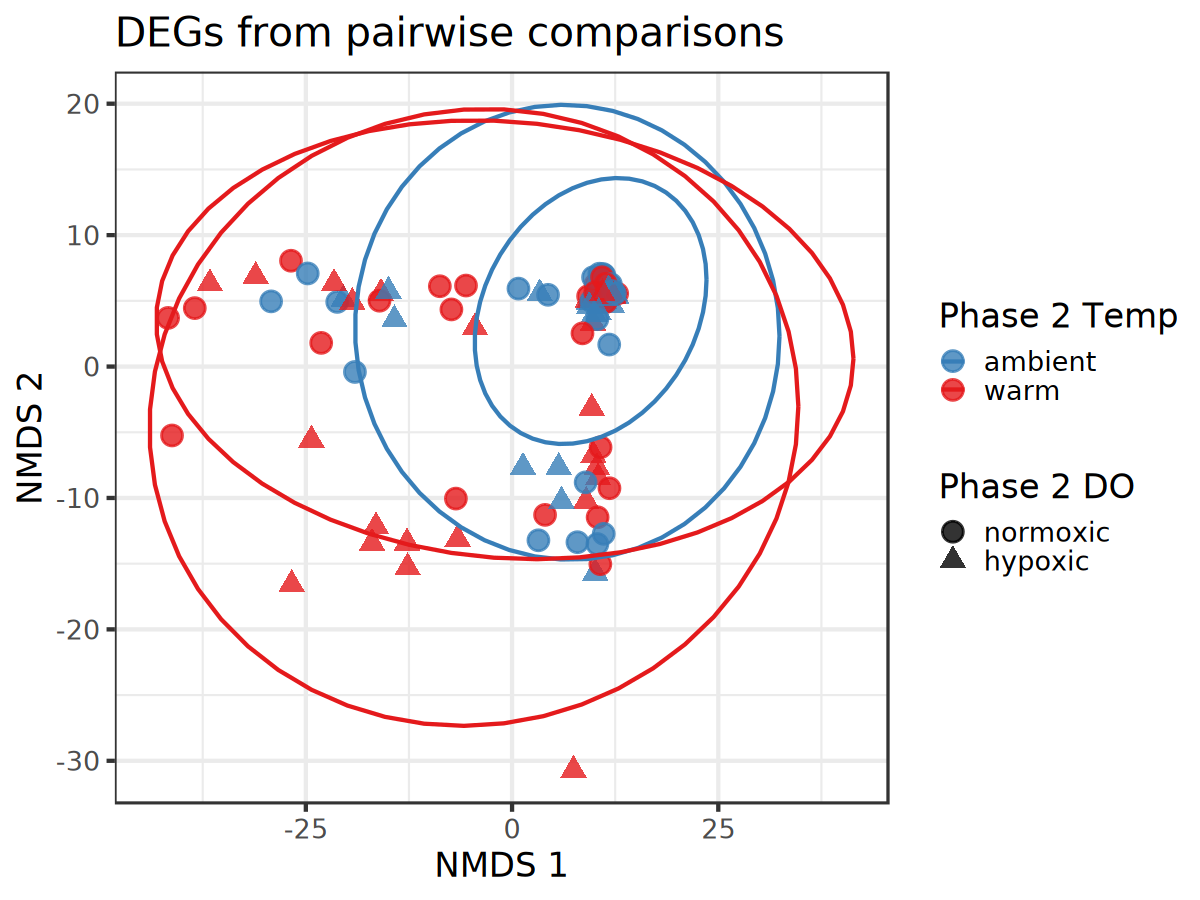

In [75]:
options(repr.plot.width = 10, repr.plot.height = 7.5)

nmds.plot2 <- ggplot(mds.deg, aes(X1, X2, col = Phase2_temp, shape = Phase2_DO)) +
geom_point(
    size = 5,
    alpha = 0.8
  ) +
scale_shape_manual(values = c(19, 17)) +
scale_color_brewer(palette = 'Set1', direction = -1) +
 stat_ellipse() + 
theme_bw(base_size = 20) +
labs(x = 'NMDS 1', 
     y = 'NMDS 2',
    col = 'Phase 2 Temp',
    shape = 'Phase 2 DO',
    title = 'DEGs from pairwise comparisons')

nmds.plot2

#### p2 temp

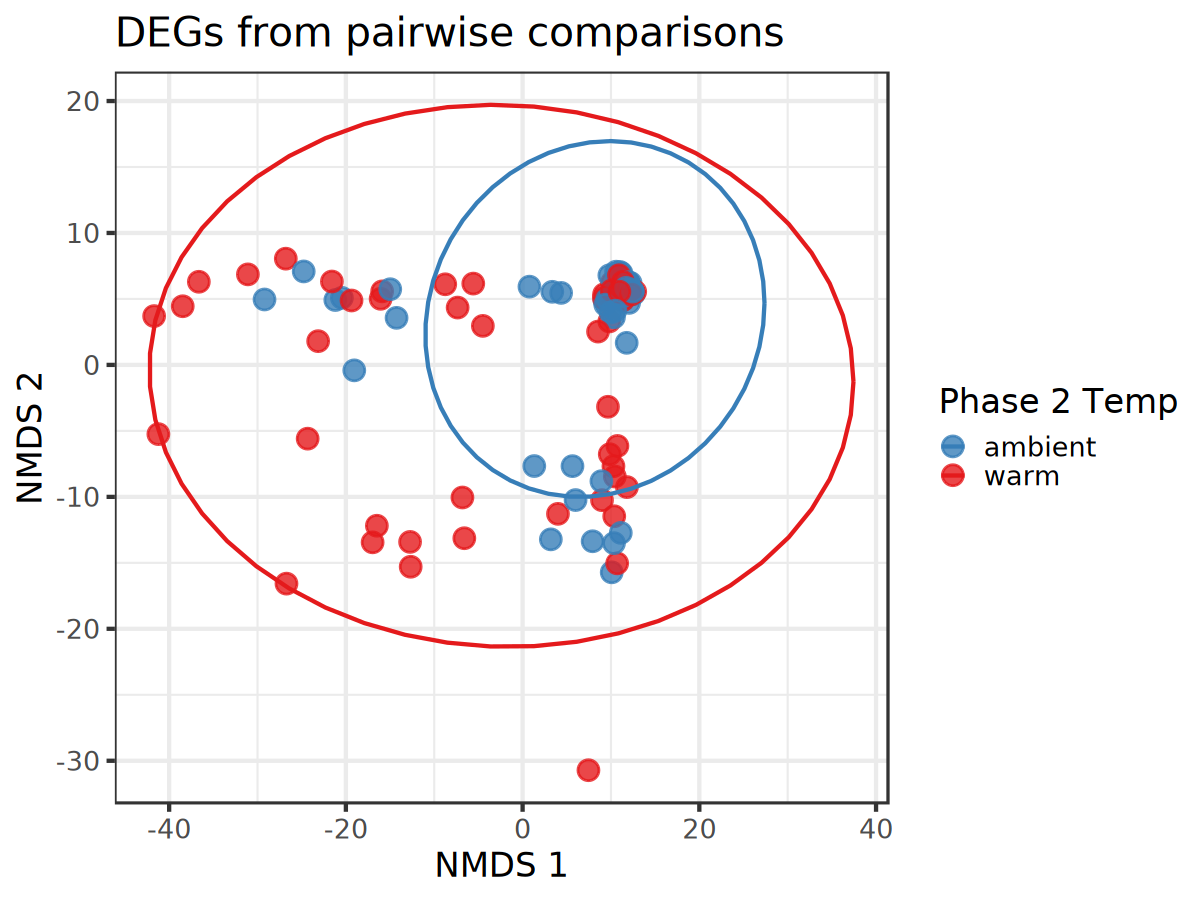

In [76]:
options(repr.plot.width = 10, repr.plot.height = 7.5)

nmds.plot2 <- ggplot(mds.deg, aes(X1, X2, col = Phase2_temp)) +
geom_point(
    size = 5,
    alpha = 0.8
  ) +
scale_shape_manual(values = c(19, 17)) +
scale_color_brewer(palette = 'Set1', direction = -1) +
 stat_ellipse() + 
theme_bw(base_size = 20) +
labs(x = 'NMDS 1', 
     y = 'NMDS 2',
    col = 'Phase 2 Temp',
    title = 'DEGs from pairwise comparisons')

nmds.plot2

#### p2 DO

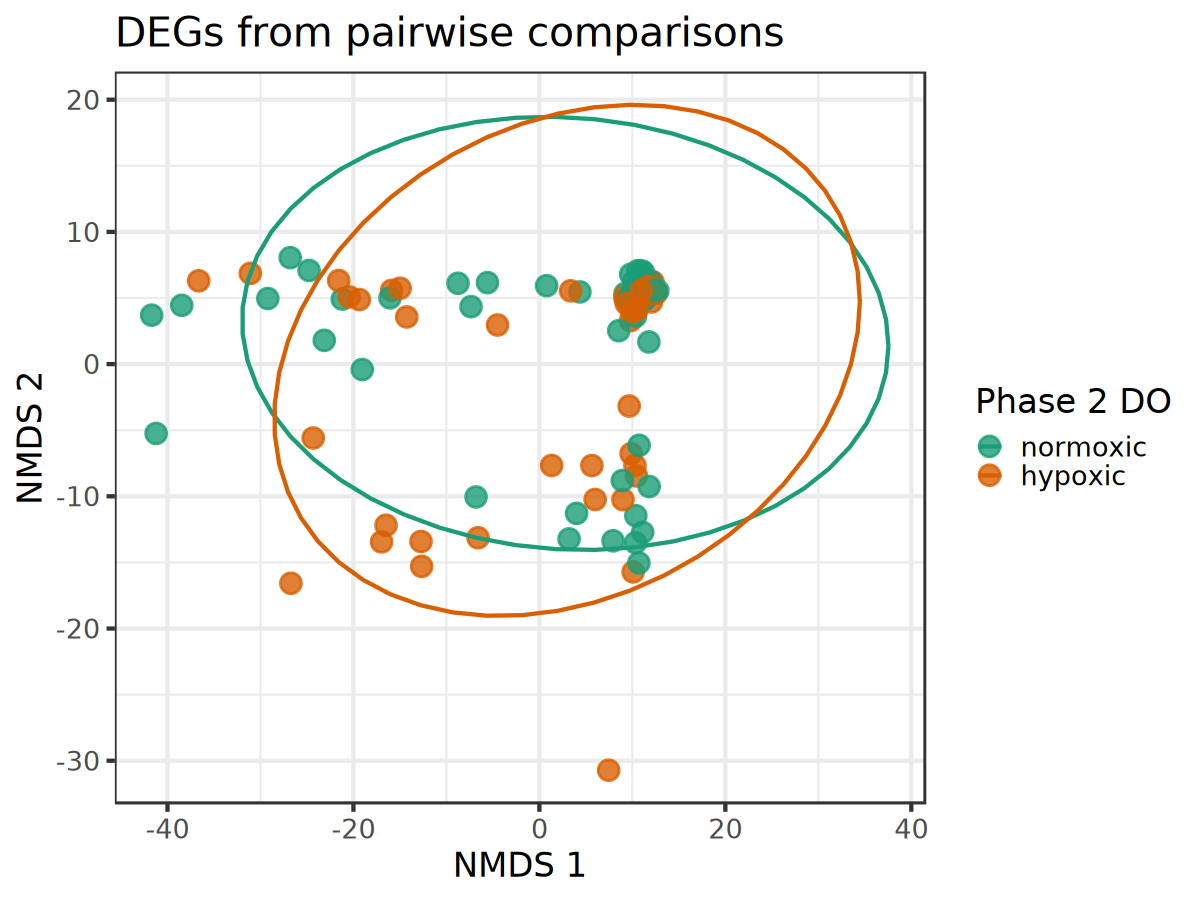

In [77]:
options(repr.plot.width = 10, repr.plot.height = 7.5)

nmds.plot2 <- ggplot(mds.deg, aes(X1, X2, col = Phase2_DO)) +
geom_point(
    size = 5,
    alpha = 0.8
  ) +
scale_shape_manual(values = c(19, 17)) +
scale_color_brewer(palette = 'Dark2') +
 stat_ellipse() + 
theme_bw(base_size = 20) +
labs(x = 'NMDS 1', 
     y = 'NMDS 2',
    col = 'Phase 2 DO',
    title = 'DEGs from pairwise comparisons')

nmds.plot2

#### p1 temp and DO

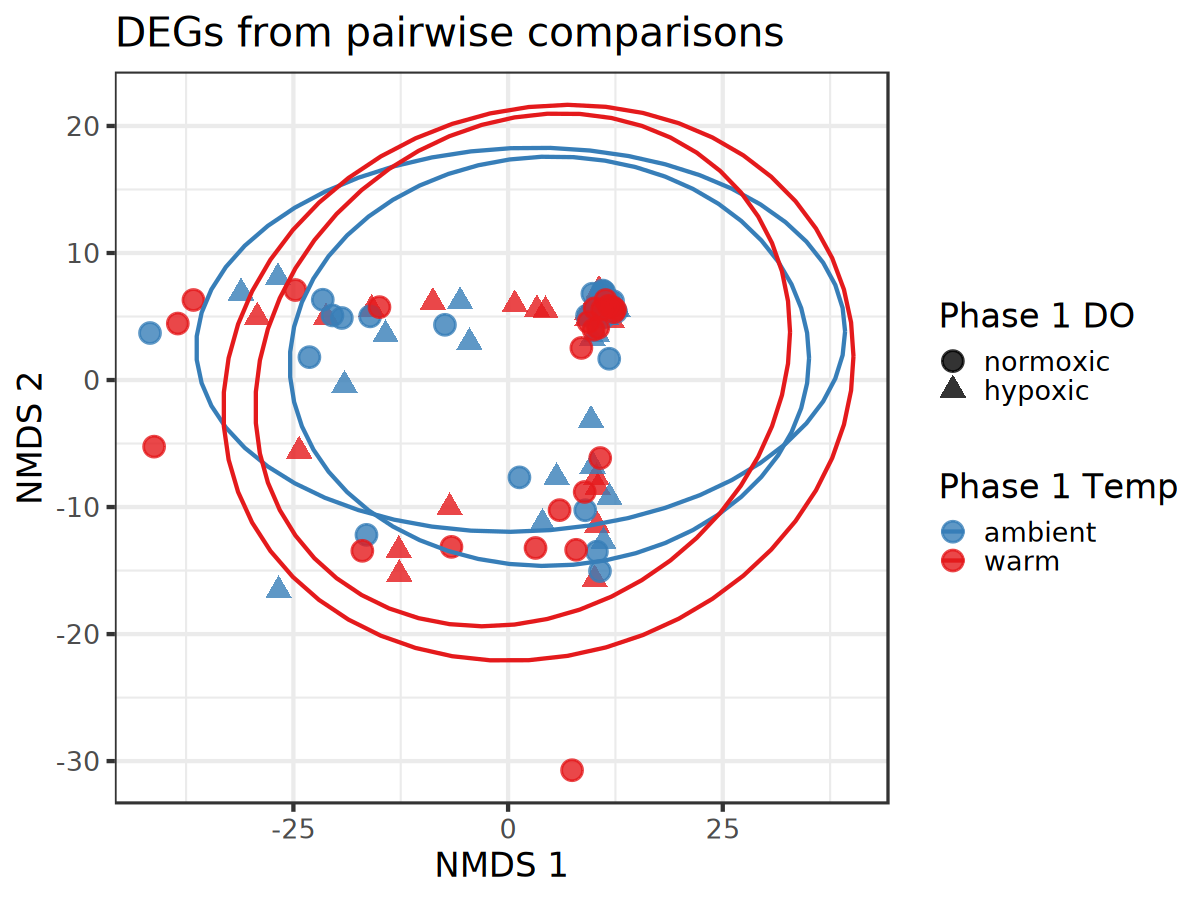

In [78]:
options(repr.plot.width = 10, repr.plot.height = 7.5)

nmds.plot2 <- ggplot(mds.deg, aes(X1, X2, col = Phase1_temp, shape = Phase1_DO)) +
geom_point(
    size = 5,
    alpha = 0.8
  ) +
scale_shape_manual(values = c(19, 17)) +
scale_color_brewer(palette = 'Set1', direction = -1) +
 stat_ellipse() + 
theme_bw(base_size = 20) +
labs(x = 'NMDS 1', 
     y = 'NMDS 2',
    col = 'Phase 1 Temp',
    shape = 'Phase 1 DO',
    title = 'DEGs from pairwise comparisons')

nmds.plot2

#### p1 temp

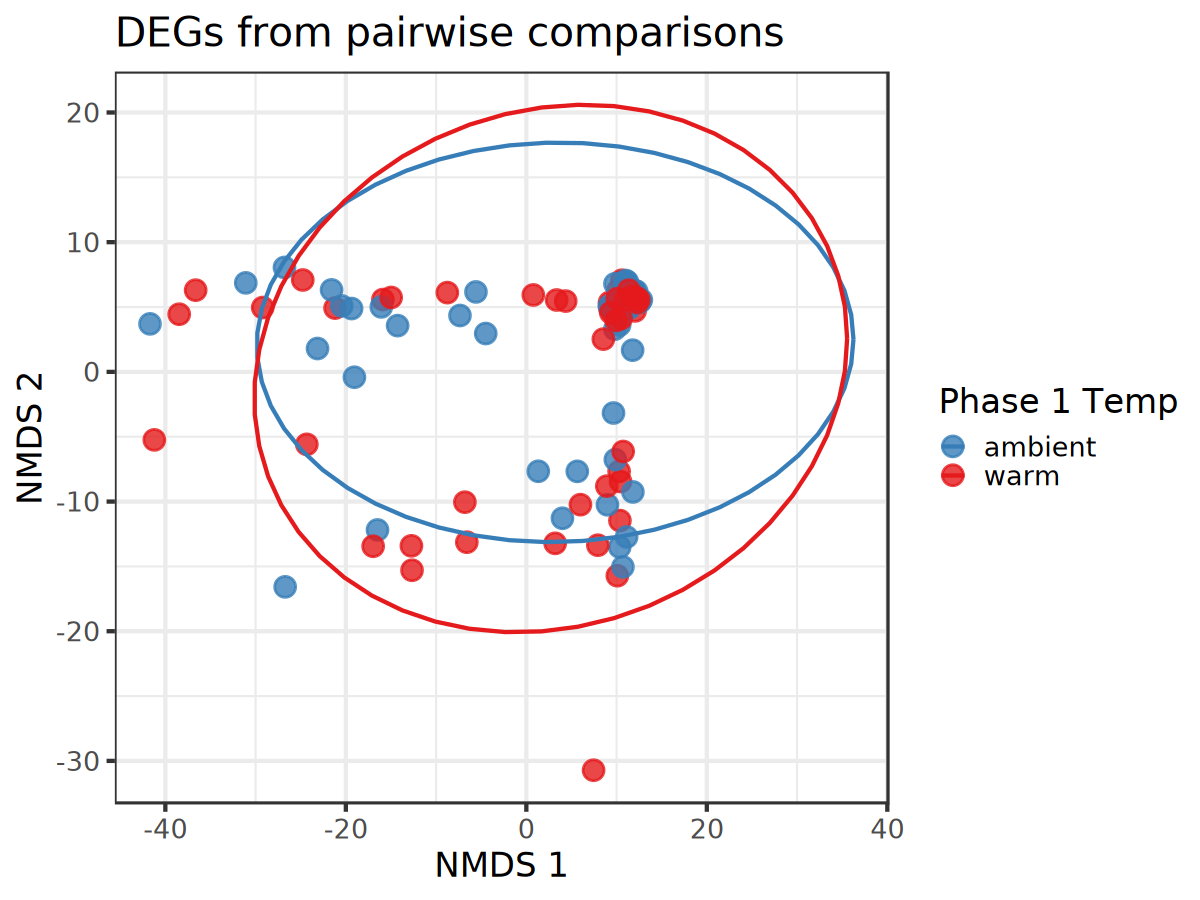

In [79]:
options(repr.plot.width = 10, repr.plot.height = 7.5)

nmds.plot2 <- ggplot(mds.deg, aes(X1, X2, col = Phase1_temp)) +
geom_point(
    size = 5,
    alpha = 0.8
  ) +
scale_shape_manual(values = c(19, 17)) +
scale_color_brewer(palette = 'Set1', direction = -1) +
 stat_ellipse() + 
theme_bw(base_size = 20) +
labs(x = 'NMDS 1', 
     y = 'NMDS 2',
    col = 'Phase 1 Temp',
    title = 'DEGs from pairwise comparisons')

nmds.plot2

#### p1 DO

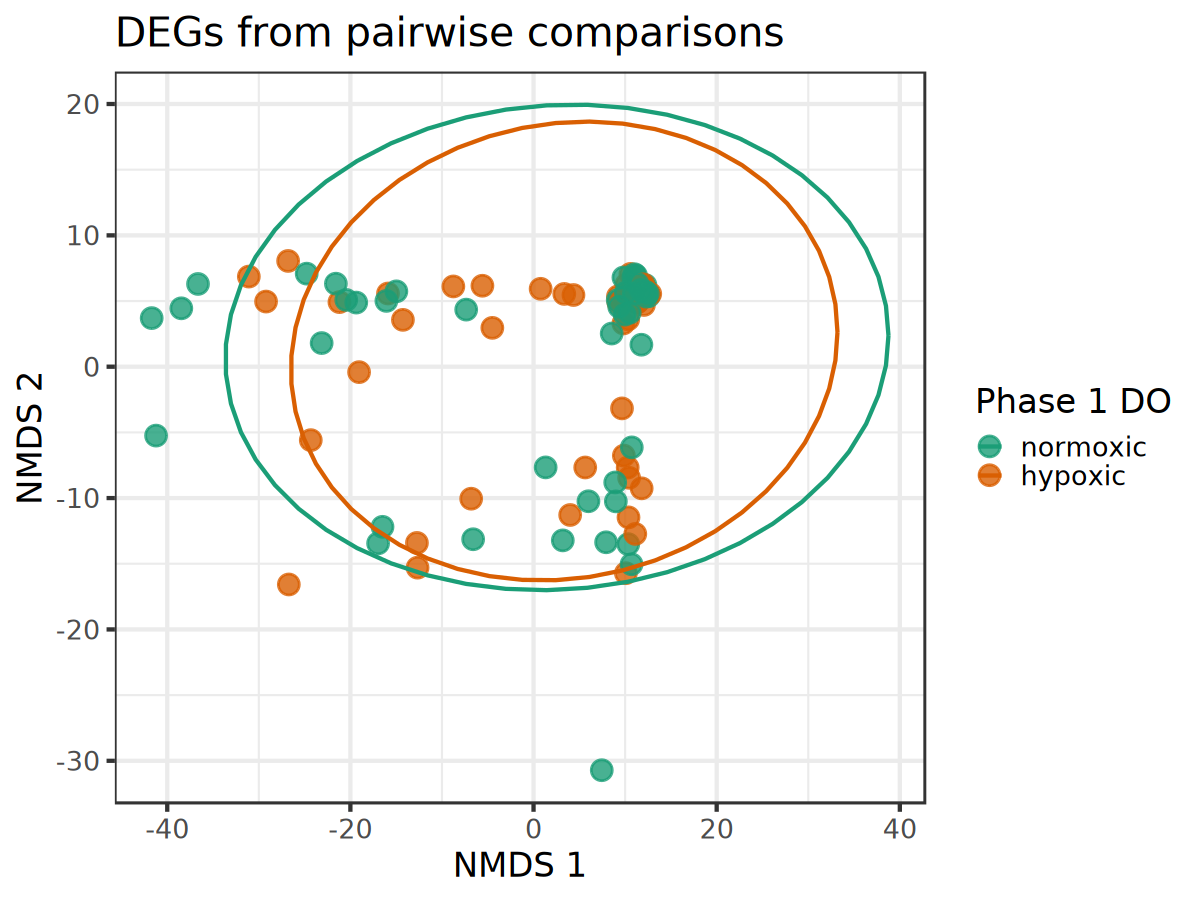

In [80]:
options(repr.plot.width = 10, repr.plot.height = 7.5)

nmds.plot2 <- ggplot(mds.deg, aes(X1, X2, col = Phase1_DO)) +
geom_point(
    size = 5,
    alpha = 0.8
  ) +
scale_shape_manual(values = c(19, 17)) +
scale_color_brewer(palette = 'Dark2') +
 stat_ellipse() + 
theme_bw(base_size = 20) +
labs(x = 'NMDS 1', 
     y = 'NMDS 2',
    col = 'Phase 1 DO',
    title = 'DEGs from pairwise comparisons')

nmds.plot2

#### permanova for DEGs

In [81]:
adonis2(sample_dists.deg ~ Phase1_temp * Phase1_DO * Phase2_temp * Phase2_DO, data = meta_noOutliers, permutations = 999)

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Phase1_temp,1,613.9100,0.008929214,0.8311629,0.549
Phase1_DO,1,504.1631,0.007332964,0.6825783,0.770
Phase2_temp,1,2687.4659,0.039088727,3.6385171,0.002
Phase2_DO,1,847.8917,0.012332439,1.1479471,0.247
Phase1_temp:Phase1_DO,1,592.5091,0.008617942,0.8021886,0.583
Phase1_temp:Phase2_temp,1,613.5458,0.008923918,0.8306699,0.530
Phase1_DO:Phase2_temp,1,783.4581,0.011395262,1.0607114,0.279
Phase1_temp:Phase2_DO,1,578.5954,0.008415570,0.7833511,0.627
Phase1_DO:Phase2_DO,1,685.5852,0.009971718,0.9282028,0.407


when only considering DEGs identified in all pairwise comparisons, only phase 2 temperature is significantly affecting gene expression profiles. this is interesting bc when I first did this with all genes, we saw a significant effect of phase 2 temp *and* DO (and the interaction of those two). so only seeing phase 2 temp and not DO suggests to me that most of the DEGs are identified due to temperature stress, and not so much bc of DO stress.

there's an *almost* significant term, Phase1_DO:Phase2_temp:Phase2:DO which is interesting! I've never seen a 3 way interaction come out before - so this means the effect of those individually rely on the value of each other?